In [1]:
# !pip install networkx pandas torch torch-geometric
# !pip install torch-scatter
# !pip install optuna

In [2]:
import random
import time
from datetime import datetime
import collections
import csv

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Network analysis
import networkx as nx

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score,  roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch Geometric
from torch_geometric.data import Data, HeteroData
from torch_geometric.utils import from_networkx
from torch_geometric.nn import (
    HeteroConv,
    GATv2Conv,
    TransformerConv,
    GCNConv,
    MessagePassing
)
from torch_geometric.loader import DataLoader
from collections import Counter, defaultdict

#optuna
import optuna

/home/rshrestha1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# def set_seed(seed):
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     np.random.seed(seed)
#     random.seed(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

In [6]:
class HeteroGCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = HeteroConv({
            ('company', 'supply', 'company'): GCNConv(in_channels, hidden_channels),
            ('company', 'boardex', 'company'): GCNConv(in_channels, hidden_channels),
            ('company', 'competition', 'company'): GCNConv(in_channels, hidden_channels),
        }, aggr='cat')

        self.conv2 = HeteroConv({
            ('company', 'supply', 'company'): GCNConv(hidden_channels * 3, out_channels),
            ('company', 'boardex', 'company'): GCNConv(hidden_channels * 3, out_channels),
            ('company', 'competition', 'company'): GCNConv(hidden_channels * 3, out_channels),
        }, aggr='cat')

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        return x_dict
        

class NodeClassifier(nn.Module):
    def __init__(self, out_channels, num_classes):
        super().__init__()
        self.fc = nn.Linear(out_channels * 3, out_channels)
        self.fc1 = nn.Linear(out_channels, num_classes)

    def forward(self, x):
        x = self.fc(x)
        return self.fc1(x)

In [7]:
def train_model(encoder, classifier, data, optimizer, criterion, device):
    encoder.train()
    classifier.train()
    optimizer.zero_grad()
    data = data.to(device)

    x_dict, edge_index_dict = data.x_dict, data.edge_index_dict
    y = data['company'].y
    train_mask = data['company'].train_mask

    x_dict = {k: v.to(device) for k, v in x_dict.items()}
    edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
    y = y.to(device)

    node_repr = encoder(x_dict, edge_index_dict)
    # x_gcn = node_repr['company']                 # (num_nodes, gcn_out_dim)
    # x_raw = data['company'].raw_feat.to(x_gcn.device)  # (num_nodes, raw_feat_dim)
    
    # x_combined = torch.cat([x_gcn, x_raw], dim=1)  # Concatenate along feature dim
    # logits = classifier(x_combined)

    logits = node_repr['company']
    
    loss = criterion(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.softmax(logits[train_mask], dim=1)
        preds = logits[train_mask].argmax(dim=1)

        y_true = y[train_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[train_mask])) > 1 else 0.0

        # if probs.size(1) == 2:
        #     auc = roc_auc_score(y_true, y_probs[:, 1])
        #     fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        # else:
        #     auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        #     fpr, tpr = None, None

    return loss.item(), acc, f1


def validate_model(encoder, classifier, data, criterion, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict = data.x_dict, data.edge_index_dict
        y = data['company'].y
        val_mask = data['company'].val_mask

        x_dict = {k: v.to(device) for k, v in x_dict.items()}
        edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict)
        # x_gcn = node_repr['company']                 # (num_nodes, gcn_out_dim)
        # x_raw = data['company'].raw_feat.to(x_gcn.device)  # (num_nodes, raw_feat_dim)
        
        # x_combined = torch.cat([x_gcn, x_raw], dim=1)  # Concatenate along feature dim
        # logits = classifier(x_combined)

        logits = node_repr['company']

        loss = criterion(logits[val_mask], y[val_mask])
        probs = torch.softmax(logits[val_mask], dim=1)
        preds = logits[val_mask].argmax(dim=1)

        y_true = y[val_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[val_mask])) > 1 else 0.0

        # if probs.size(1) == 2:
        #     auc = roc_auc_score(y_true, y_probs[:, 1])
        #     fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        # else:
        #     auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        #     fpr, tpr = None, None

    return loss.item(), acc, f1


def test_model(encoder, classifier, data, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict = data.x_dict, data.edge_index_dict
        y = data['company'].y
        test_mask = data['company'].test_mask  # use test_mask if available

        x_dict = {k: v.to(device) for k, v in x_dict.items()}
        edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict)
        # x_gcn = node_repr['company']                 # (num_nodes, gcn_out_dim)
        # x_raw = data['company'].raw_feat.to(x_gcn.device)  # (num_nodes, raw_feat_dim)
        
        # x_combined = torch.cat([x_gcn, x_raw], dim=1)  # Concatenate along feature dim
        # logits = classifier(x_combined)

        logits = node_repr['company']

        probs = torch.softmax(logits[test_mask], dim=1)
        preds = logits[test_mask].argmax(dim=1)

        y_true = y[test_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[test_mask])) > 1 else 0.0

        # if probs.size(1) == 2:
        #     auc = roc_auc_score(y_true, y_probs[:, 1])
        #     fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        # else:
        #     auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        #     fpr, tpr = None, None

    return acc, f1

In [8]:
def train_test(encoder, classifier, data, optimizer, criterion, device, epochs=1000, patience=100):
    best_val_loss = float('inf')
    counter = 0
    best_encoder = None
    best_classifier = None
    best_train_acc = None
    best_f1 = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_model(encoder, classifier, data, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = validate_model(encoder, classifier, data, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch: {epoch+1:03d}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_f1 = val_f1
            counter = 0
            best_encoder = encoder.state_dict()
            best_classifier = classifier.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    if best_encoder is not None and best_classifier is not None:
        encoder.load_state_dict(best_encoder)
        classifier.load_state_dict(best_classifier)

    return encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, best_val_loss, best_train_acc, best_f1

In [9]:
def run_experiment(year, metric, hidden_channels=64, out_channels=32, num_heads=4,
                   lr=0.01, weight_decay=5e-4, epochs=1000, patience=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    data = torch.load(f'Dataset/heterographdata{year}.pt', weights_only=False)
    in_channels = data['company'].x.size(1)
    num_classes = int(data['company'].y.max().item()) + 1

    if torch.min(data['company'].y) < 0:
        valid_labels = data['company'].y >= 0
        num_classes = int(data['company'].y[valid_labels].max().item()) + 1

    print(f"Input channels: {in_channels}, Number of classes: {num_classes}")

    encoder = HeteroGCNEncoder(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels
    ).to(device)

    classifier = NodeClassifier(
        out_channels=out_channels,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(classifier.parameters()), 
        lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, _, best_train_acc, best_f1 = train_test(
        encoder, classifier, data, optimizer, criterion, device, epochs=epochs, patience=patience
    )

    test_acc, test_f1 = test_model(encoder, classifier, data, device)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}')

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'Graph_EncoderClassifier_training_{year}_{metric}.png')
    plt.show()

    return {
        'encoder': encoder,
        'classifier': classifier,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time': training_time,
        'epochs_run': len(train_losses),
        'best_train_acc': best_train_acc
    }

In [10]:
def objective(trial, year, metric):
    hidden_channels = trial.suggest_categorical("hidden_channels", [64, 128])
    out_channels = trial.suggest_categorical("out_channels", [32, 64])
    # num_heads = trial.suggest_int("num_heads", 1)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    data = prepare_data(year, metric)
    in_channels = data['company'].x.size(1)
    num_classes = int(data['company'].y.max().item()) + 1

    if torch.min(data['company'].y) < 0:
        valid_labels = data['company'].y >= 0
        num_classes = int(data['company'].y[valid_labels].max().item()) + 1

    print(f"Input channels: {in_channels}, Number of classes: {num_classes}")

    model = HeteroGCNGNN(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    model, training_time, train_losses, val_losses, train_accs, val_accs, best_val_loss, _, best_f1 = train_test(
        model, data, optimizer, criterion, device
    )

    print(best_f1)
    return best_f1


========== Run 1 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1763, Val Loss: 4.0668, Train Acc: 0.1531, Val Acc: 0.2406
Epoch: 020, Train Loss: 3.6242, Val Loss: 3.4874, Train Acc: 0.5318, Val Acc: 0.5677
Epoch: 030, Train Loss: 3.0994, Val Loss: 2.9610, Train Acc: 0.5657, Val Acc: 0.5827
Epoch: 040, Train Loss: 2.6092, Val Loss: 2.4869, Train Acc: 0.5761, Val Acc: 0.5940
Epoch: 050, Train Loss: 2.1644, Val Loss: 2.0663, Train Acc: 0.5802, Val Acc: 0.6015
Epoch: 060, Train Loss: 1.7822, Val Loss: 1.7095, Train Acc: 0.5818, Val Acc: 0.5977
Epoch: 070, Train Loss: 1.4745, Val Loss: 1.4250, Train Acc: 0.5858, Val Acc: 0.6015
Epoch: 080, Train Loss: 1.2417, Val Loss: 1.2121, Train Acc: 0.5874, Val Acc: 0.6053
Epoch: 090, Train Loss: 1.0745, Val Loss: 1.0615, Train Acc: 0.5858, Val Acc: 0.5977
Epoch: 100, Train Loss: 0.9592, Val Loss: 0.9593, Train Acc: 0.5907, Val Acc: 0.5865
Epoch: 110, Train Loss

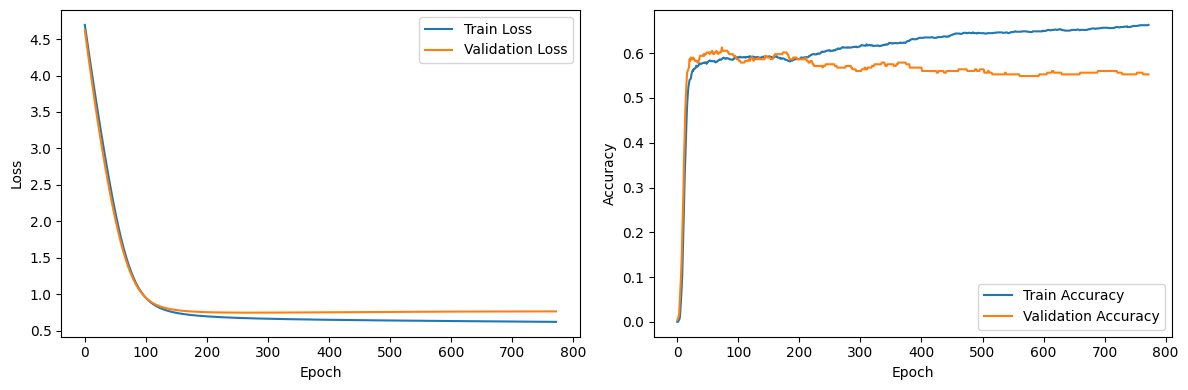


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2487, Val Loss: 4.2087, Train Acc: 0.1015, Val Acc: 0.1373
Epoch: 020, Train Loss: 3.6716, Val Loss: 3.6534, Train Acc: 0.5008, Val Acc: 0.4784
Epoch: 030, Train Loss: 3.1150, Val Loss: 3.1069, Train Acc: 0.5436, Val Acc: 0.5176
Epoch: 040, Train Loss: 2.5980, Val Loss: 2.5889, Train Acc: 0.5805, Val Acc: 0.5373
Epoch: 050, Train Loss: 2.1391, Val Loss: 2.1244, Train Acc: 0.5889, Val Acc: 0.5647
Epoch: 060, Train Loss: 1.7553, Val Loss: 1.7340, Train Acc: 0.5931, Val Acc: 0.5294
Epoch: 070, Train Loss: 1.4539, Val Loss: 1.4288, Train Acc: 0.5956, Val Acc: 0.5255
Epoch: 080, Train Loss: 1.2296, Val Loss: 1.2055, Train Acc: 0.6032, Val Acc: 0.5255
Epoch: 090, Train Loss: 1.0692, Val Loss: 1.0505, Train Acc: 0.6091, Val Acc: 0.5216
Epoch: 100, Train Loss: 0.9576, Val Loss: 0.9459, Train Acc: 0.6116, Val Acc: 0.5255
Epoch: 110, Train Loss: 0.8807, Val Loss: 0.8759, Tr

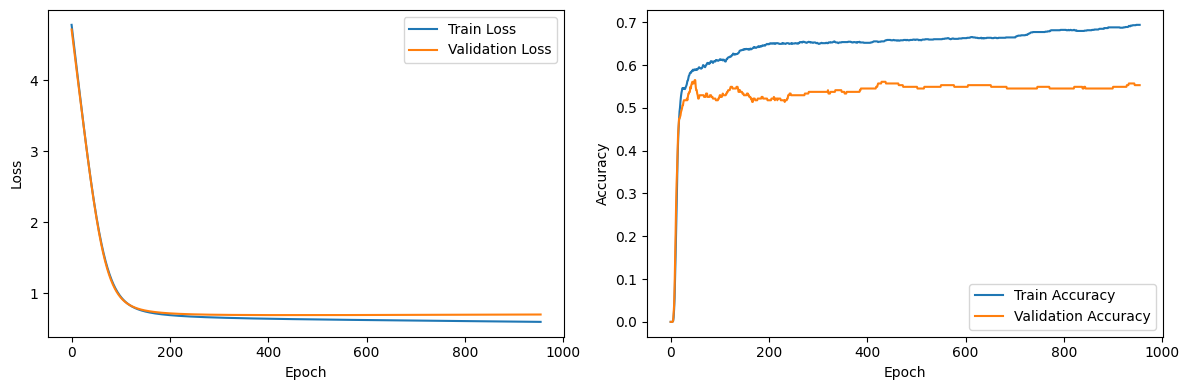


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0021, Val Loss: 3.9755, Train Acc: 0.3475, Val Acc: 0.3771
Epoch: 020, Train Loss: 3.4709, Val Loss: 3.4493, Train Acc: 0.5481, Val Acc: 0.5042
Epoch: 030, Train Loss: 2.9609, Val Loss: 2.9839, Train Acc: 0.5599, Val Acc: 0.5297
Epoch: 040, Train Loss: 2.4821, Val Loss: 2.5502, Train Acc: 0.5608, Val Acc: 0.5042
Epoch: 050, Train Loss: 2.0547, Val Loss: 2.1543, Train Acc: 0.5644, Val Acc: 0.5042
Epoch: 060, Train Loss: 1.6964, Val Loss: 1.8100, Train Acc: 0.5653, Val Acc: 0.5127
Epoch: 070, Train Loss: 1.4137, Val Loss: 1.5297, Train Acc: 0.5662, Val Acc: 0.5000
Epoch: 080, Train Loss: 1.2021, Val Loss: 1.3155, Train Acc: 0.5644, Val Acc: 0.4915
Epoch: 090, Train Loss: 1.0506, Val Loss: 1.1596, Train Acc: 0.5699, Val Acc: 0.4958
Epoch: 100, Train Loss: 0.9454, Val Loss: 1.0493, Train Acc: 0.5662, Val Acc: 0.5042
Epoch: 110, Train Loss: 0.8737, Val Loss: 0.9725, Tr

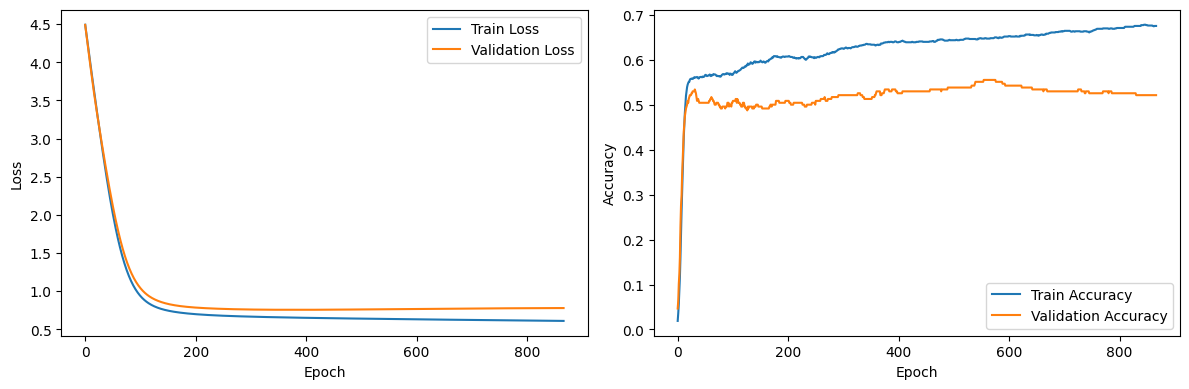


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1013, Val Loss: 4.0424, Train Acc: 0.2126, Val Acc: 0.3028
Epoch: 020, Train Loss: 3.5166, Val Loss: 3.4691, Train Acc: 0.4961, Val Acc: 0.4908
Epoch: 030, Train Loss: 2.9735, Val Loss: 2.9373, Train Acc: 0.5305, Val Acc: 0.4862
Epoch: 040, Train Loss: 2.4814, Val Loss: 2.4581, Train Acc: 0.5492, Val Acc: 0.5000
Epoch: 050, Train Loss: 2.0468, Val Loss: 2.0356, Train Acc: 0.5472, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.6833, Val Loss: 1.6804, Train Acc: 0.5443, Val Acc: 0.5183
Epoch: 070, Train Loss: 1.3993, Val Loss: 1.4012, Train Acc: 0.5413, Val Acc: 0.5183
Epoch: 080, Train Loss: 1.1907, Val Loss: 1.1956, Train Acc: 0.5512, Val Acc: 0.5183
Epoch: 090, Train Loss: 1.0438, Val Loss: 1.0512, Train Acc: 0.5571, Val Acc: 0.5229
Epoch: 100, Train Loss: 0.9428, Val Loss: 0.9520, Train Acc: 0.5640, Val Acc: 0.5275
Epoch: 110, Train Loss: 0.8737, Val Loss: 0.8839, Tr

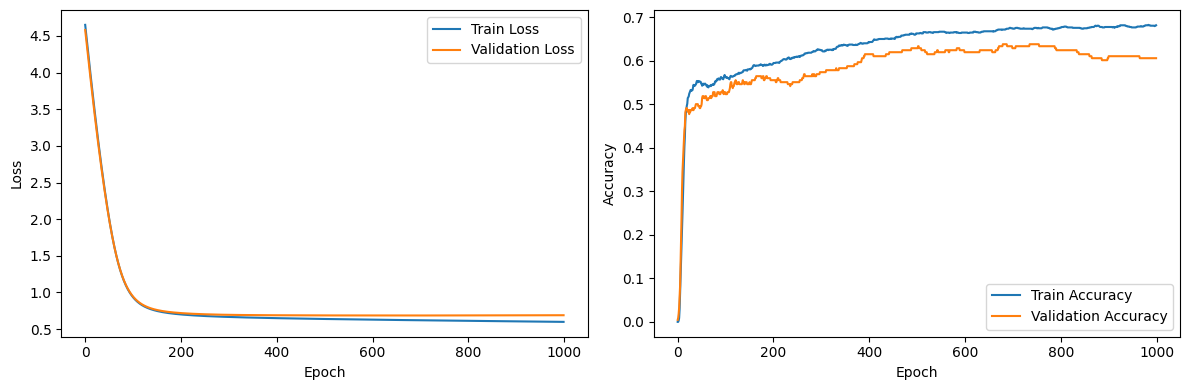


========== Run 2 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0702, Val Loss: 3.9828, Train Acc: 0.2490, Val Acc: 0.3195
Epoch: 020, Train Loss: 3.5064, Val Loss: 3.3880, Train Acc: 0.5117, Val Acc: 0.5150
Epoch: 030, Train Loss: 2.9668, Val Loss: 2.8521, Train Acc: 0.5496, Val Acc: 0.5263
Epoch: 040, Train Loss: 2.4667, Val Loss: 2.3730, Train Acc: 0.5447, Val Acc: 0.5226
Epoch: 050, Train Loss: 2.0265, Val Loss: 1.9571, Train Acc: 0.5552, Val Acc: 0.5263
Epoch: 060, Train Loss: 1.6637, Val Loss: 1.6170, Train Acc: 0.5600, Val Acc: 0.5376
Epoch: 070, Train Loss: 1.3828, Val Loss: 1.3560, Train Acc: 0.5761, Val Acc: 0.5489
Epoch: 080, Train Loss: 1.1766, Val Loss: 1.1655, Train Acc: 0.5786, Val Acc: 0.5602
Epoch: 090, Train Loss: 1.0311, Val Loss: 1.0315, Train Acc: 0.5931, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.9310, Val Loss: 0.9398, Train Acc: 0.5987, Val Acc: 0.5714
Epoch: 110, Train Loss

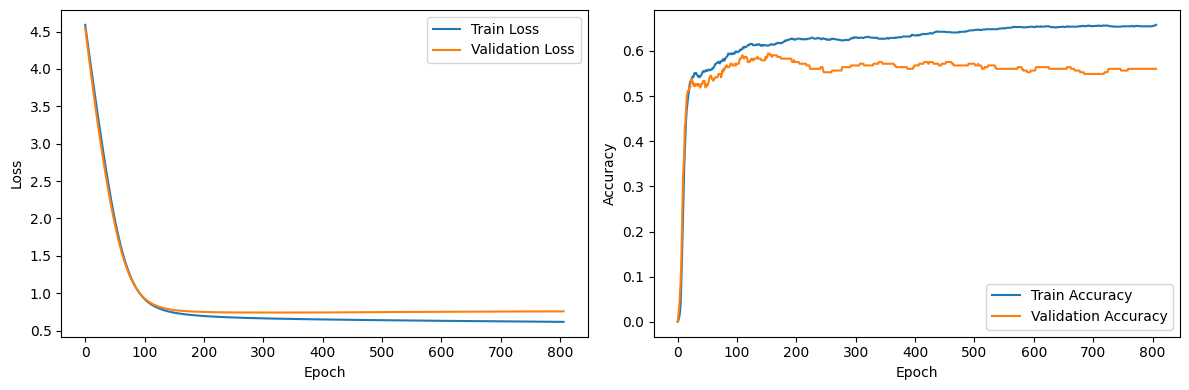


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9540, Val Loss: 3.9433, Train Acc: 0.3960, Val Acc: 0.3843
Epoch: 020, Train Loss: 3.3935, Val Loss: 3.4017, Train Acc: 0.5721, Val Acc: 0.5294
Epoch: 030, Train Loss: 2.8672, Val Loss: 2.8772, Train Acc: 0.5872, Val Acc: 0.5451
Epoch: 040, Train Loss: 2.3885, Val Loss: 2.3903, Train Acc: 0.5948, Val Acc: 0.5451
Epoch: 050, Train Loss: 1.9730, Val Loss: 1.9639, Train Acc: 0.5956, Val Acc: 0.5451
Epoch: 060, Train Loss: 1.6333, Val Loss: 1.6149, Train Acc: 0.5965, Val Acc: 0.5529
Epoch: 070, Train Loss: 1.3708, Val Loss: 1.3476, Train Acc: 0.5998, Val Acc: 0.5647
Epoch: 080, Train Loss: 1.1766, Val Loss: 1.1539, Train Acc: 0.6057, Val Acc: 0.5725
Epoch: 090, Train Loss: 1.0373, Val Loss: 1.0187, Train Acc: 0.6065, Val Acc: 0.5686
Epoch: 100, Train Loss: 0.9391, Val Loss: 0.9258, Train Acc: 0.6057, Val Acc: 0.5765
Epoch: 110, Train Loss: 0.8702, Val Loss: 0.8621, Tr

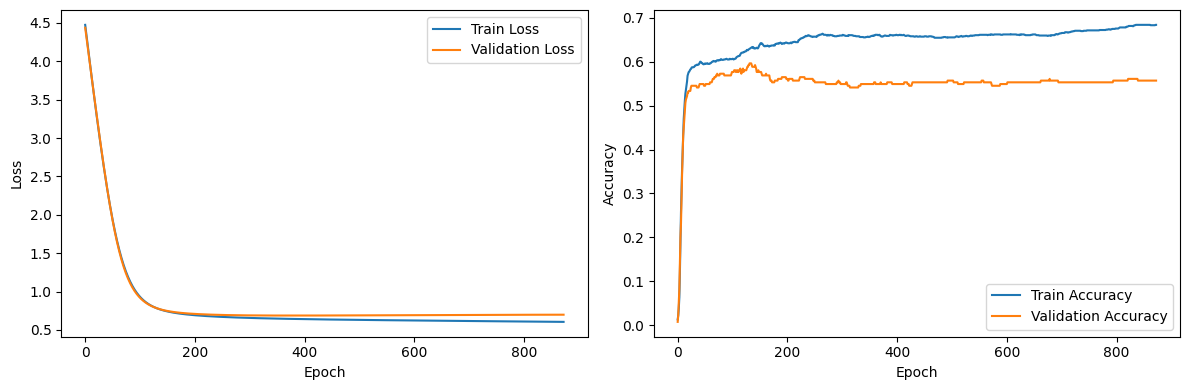


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0530, Val Loss: 3.9769, Train Acc: 0.2985, Val Acc: 0.3898
Epoch: 020, Train Loss: 3.5323, Val Loss: 3.4825, Train Acc: 0.5200, Val Acc: 0.5212
Epoch: 030, Train Loss: 3.0187, Val Loss: 3.0139, Train Acc: 0.5318, Val Acc: 0.5381
Epoch: 040, Train Loss: 2.5241, Val Loss: 2.5653, Train Acc: 0.5417, Val Acc: 0.5424
Epoch: 050, Train Loss: 2.0714, Val Loss: 2.1469, Train Acc: 0.5581, Val Acc: 0.5381
Epoch: 060, Train Loss: 1.6864, Val Loss: 1.7785, Train Acc: 0.5681, Val Acc: 0.5169
Epoch: 070, Train Loss: 1.3854, Val Loss: 1.4812, Train Acc: 0.5835, Val Acc: 0.5169
Epoch: 080, Train Loss: 1.1674, Val Loss: 1.2608, Train Acc: 0.5889, Val Acc: 0.5042
Epoch: 090, Train Loss: 1.0182, Val Loss: 1.1074, Train Acc: 0.5926, Val Acc: 0.5000
Epoch: 100, Train Loss: 0.9190, Val Loss: 1.0034, Train Acc: 0.5980, Val Acc: 0.4831
Epoch: 110, Train Loss: 0.8532, Val Loss: 0.9331, Tr

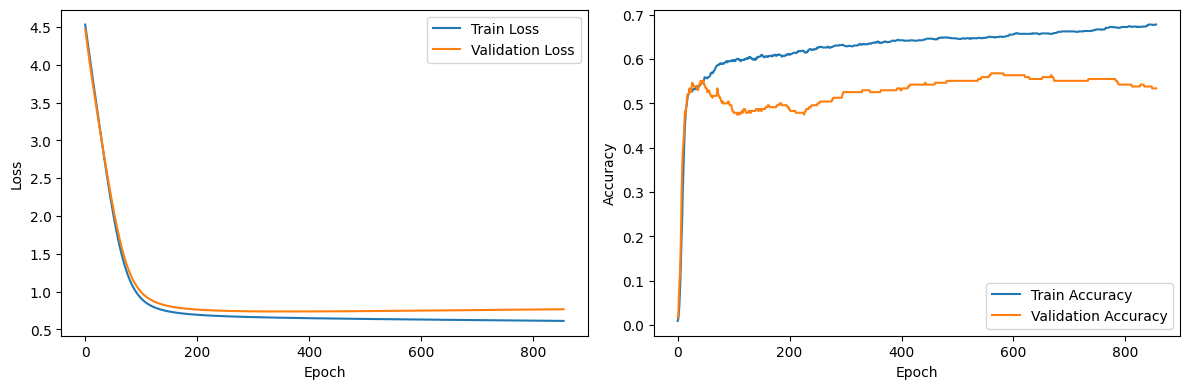


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0257, Val Loss: 3.9252, Train Acc: 0.2648, Val Acc: 0.2844
Epoch: 020, Train Loss: 3.4482, Val Loss: 3.3613, Train Acc: 0.5551, Val Acc: 0.5826
Epoch: 030, Train Loss: 2.9028, Val Loss: 2.8326, Train Acc: 0.5728, Val Acc: 0.5734
Epoch: 040, Train Loss: 2.4056, Val Loss: 2.3531, Train Acc: 0.5699, Val Acc: 0.5734
Epoch: 050, Train Loss: 1.9692, Val Loss: 1.9318, Train Acc: 0.5699, Val Acc: 0.5642
Epoch: 060, Train Loss: 1.6099, Val Loss: 1.5830, Train Acc: 0.5738, Val Acc: 0.5596
Epoch: 070, Train Loss: 1.3350, Val Loss: 1.3153, Train Acc: 0.5709, Val Acc: 0.5734
Epoch: 080, Train Loss: 1.1372, Val Loss: 1.1239, Train Acc: 0.5709, Val Acc: 0.5642
Epoch: 090, Train Loss: 1.0007, Val Loss: 0.9935, Train Acc: 0.5817, Val Acc: 0.5550
Epoch: 100, Train Loss: 0.9085, Val Loss: 0.9063, Train Acc: 0.5827, Val Acc: 0.5596
Epoch: 110, Train Loss: 0.8465, Val Loss: 0.8480, Tr

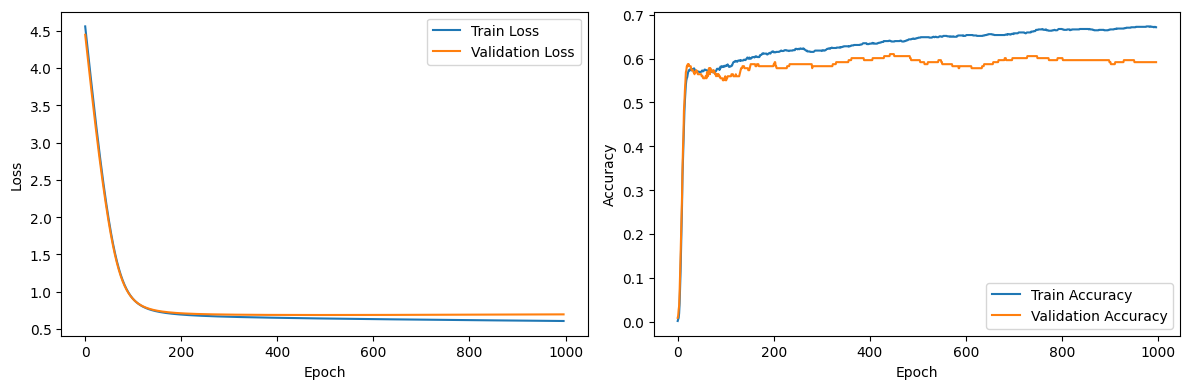


========== Run 3 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1224, Val Loss: 4.0967, Train Acc: 0.3747, Val Acc: 0.4098
Epoch: 020, Train Loss: 3.5886, Val Loss: 3.5530, Train Acc: 0.4883, Val Acc: 0.4887
Epoch: 030, Train Loss: 3.0781, Val Loss: 3.0533, Train Acc: 0.5004, Val Acc: 0.5075
Epoch: 040, Train Loss: 2.5973, Val Loss: 2.5849, Train Acc: 0.5052, Val Acc: 0.5075
Epoch: 050, Train Loss: 2.1602, Val Loss: 2.1542, Train Acc: 0.5125, Val Acc: 0.5226
Epoch: 060, Train Loss: 1.7822, Val Loss: 1.7765, Train Acc: 0.5246, Val Acc: 0.5338
Epoch: 070, Train Loss: 1.4736, Val Loss: 1.4653, Train Acc: 0.5536, Val Acc: 0.5639
Epoch: 080, Train Loss: 1.2385, Val Loss: 1.2298, Train Acc: 0.5770, Val Acc: 0.5677
Epoch: 090, Train Loss: 1.0705, Val Loss: 1.0663, Train Acc: 0.5850, Val Acc: 0.5639
Epoch: 100, Train Loss: 0.9549, Val Loss: 0.9588, Train Acc: 0.6011, Val Acc: 0.5752
Epoch: 110, Train Loss

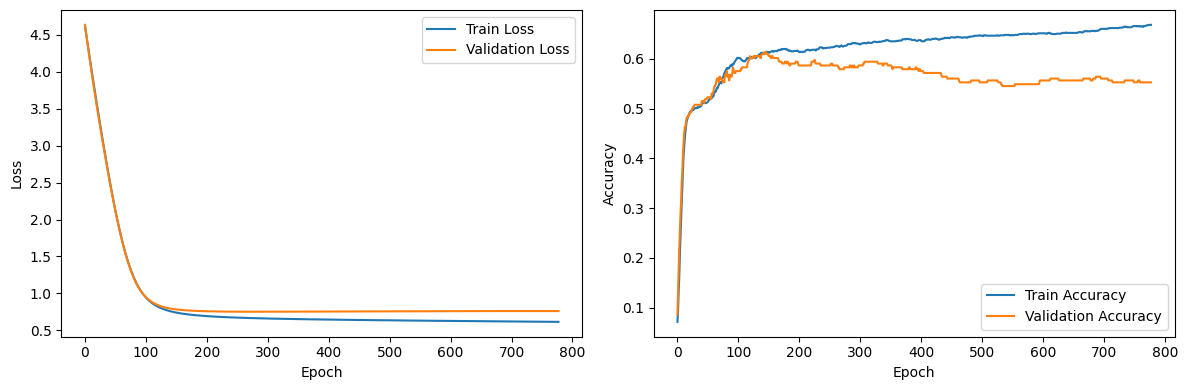


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0217, Val Loss: 3.9868, Train Acc: 0.3691, Val Acc: 0.4000
Epoch: 020, Train Loss: 3.4784, Val Loss: 3.4650, Train Acc: 0.4799, Val Acc: 0.4941
Epoch: 030, Train Loss: 2.9528, Val Loss: 2.9497, Train Acc: 0.5076, Val Acc: 0.5255
Epoch: 040, Train Loss: 2.4584, Val Loss: 2.4570, Train Acc: 0.5151, Val Acc: 0.5412
Epoch: 050, Train Loss: 2.0159, Val Loss: 2.0115, Train Acc: 0.5453, Val Acc: 0.5451
Epoch: 060, Train Loss: 1.6463, Val Loss: 1.6386, Train Acc: 0.5646, Val Acc: 0.5569
Epoch: 070, Train Loss: 1.3603, Val Loss: 1.3520, Train Acc: 0.5780, Val Acc: 0.5647
Epoch: 080, Train Loss: 1.1535, Val Loss: 1.1470, Train Acc: 0.5831, Val Acc: 0.5608
Epoch: 090, Train Loss: 1.0108, Val Loss: 1.0074, Train Acc: 0.5898, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.9147, Val Loss: 0.9148, Train Acc: 0.5965, Val Acc: 0.5608
Epoch: 110, Train Loss: 0.8499, Val Loss: 0.8536, Tr

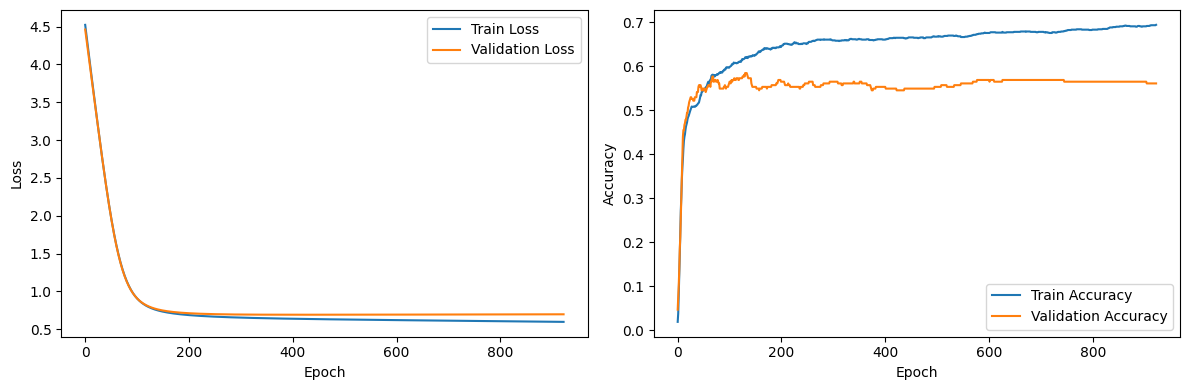


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2685, Val Loss: 4.2406, Train Acc: 0.1978, Val Acc: 0.2881
Epoch: 020, Train Loss: 3.7554, Val Loss: 3.7403, Train Acc: 0.4501, Val Acc: 0.4703
Epoch: 030, Train Loss: 3.2475, Val Loss: 3.2617, Train Acc: 0.4918, Val Acc: 0.4831
Epoch: 040, Train Loss: 2.7492, Val Loss: 2.7948, Train Acc: 0.5036, Val Acc: 0.4873
Epoch: 050, Train Loss: 2.2795, Val Loss: 2.3494, Train Acc: 0.5209, Val Acc: 0.4831
Epoch: 060, Train Loss: 1.8641, Val Loss: 1.9442, Train Acc: 0.5299, Val Acc: 0.4703
Epoch: 070, Train Loss: 1.5238, Val Loss: 1.6022, Train Acc: 0.5363, Val Acc: 0.4534
Epoch: 080, Train Loss: 1.2671, Val Loss: 1.3399, Train Acc: 0.5336, Val Acc: 0.4407
Epoch: 090, Train Loss: 1.0868, Val Loss: 1.1558, Train Acc: 0.5445, Val Acc: 0.4873
Epoch: 100, Train Loss: 0.9660, Val Loss: 1.0341, Train Acc: 0.5572, Val Acc: 0.4915
Epoch: 110, Train Loss: 0.8866, Val Loss: 0.9552, Tr

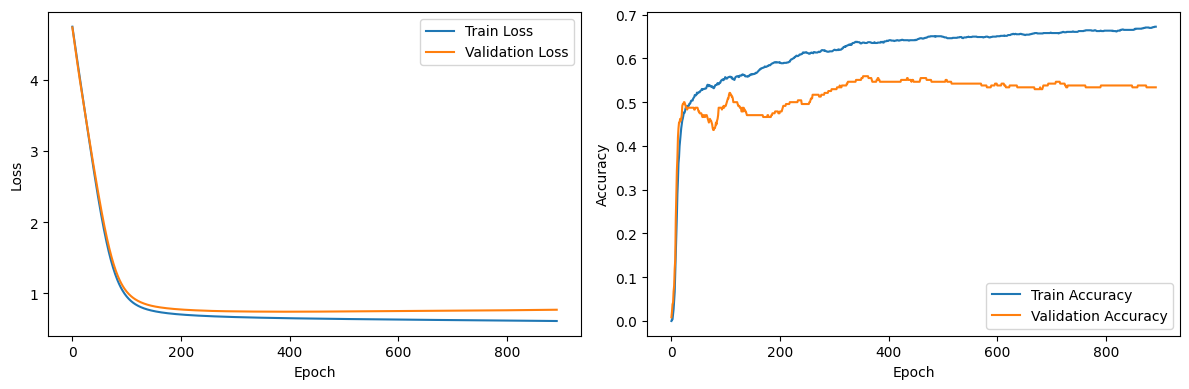


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2160, Val Loss: 4.1404, Train Acc: 0.0689, Val Acc: 0.1468
Epoch: 020, Train Loss: 3.6074, Val Loss: 3.5418, Train Acc: 0.5020, Val Acc: 0.5505
Epoch: 030, Train Loss: 3.0466, Val Loss: 2.9913, Train Acc: 0.5433, Val Acc: 0.5688
Epoch: 040, Train Loss: 2.5490, Val Loss: 2.5040, Train Acc: 0.5561, Val Acc: 0.5688
Epoch: 050, Train Loss: 2.1146, Val Loss: 2.0785, Train Acc: 0.5472, Val Acc: 0.5826
Epoch: 060, Train Loss: 1.7495, Val Loss: 1.7192, Train Acc: 0.5374, Val Acc: 0.5917
Epoch: 070, Train Loss: 1.4590, Val Loss: 1.4330, Train Acc: 0.5404, Val Acc: 0.5917
Epoch: 080, Train Loss: 1.2400, Val Loss: 1.2192, Train Acc: 0.5512, Val Acc: 0.5872
Epoch: 090, Train Loss: 1.0819, Val Loss: 1.0671, Train Acc: 0.5679, Val Acc: 0.5826
Epoch: 100, Train Loss: 0.9711, Val Loss: 0.9623, Train Acc: 0.5719, Val Acc: 0.5872
Epoch: 110, Train Loss: 0.8943, Val Loss: 0.8907, Tr

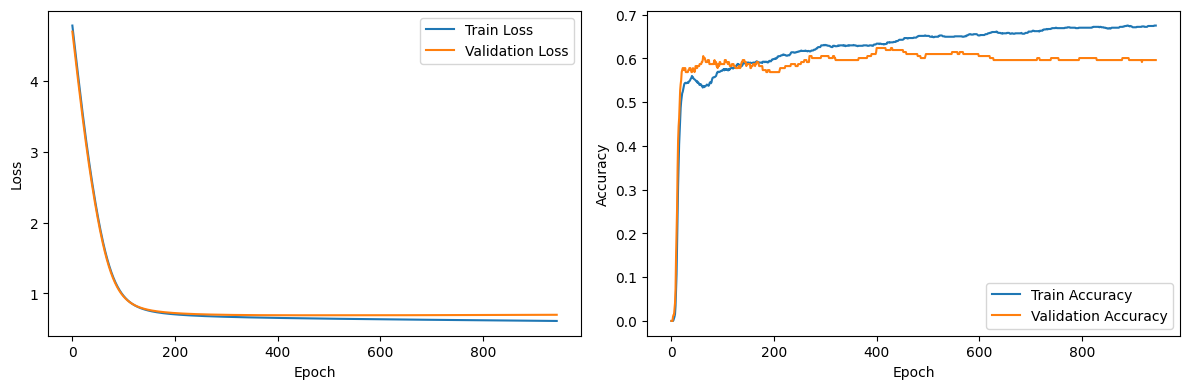


========== Run 4 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2732, Val Loss: 4.2036, Train Acc: 0.1402, Val Acc: 0.2030
Epoch: 020, Train Loss: 3.7387, Val Loss: 3.6414, Train Acc: 0.5262, Val Acc: 0.5451
Epoch: 030, Train Loss: 3.2172, Val Loss: 3.1160, Train Acc: 0.5504, Val Acc: 0.5602
Epoch: 040, Train Loss: 2.7168, Val Loss: 2.6327, Train Acc: 0.5624, Val Acc: 0.5789
Epoch: 050, Train Loss: 2.2525, Val Loss: 2.1885, Train Acc: 0.5665, Val Acc: 0.5789
Epoch: 060, Train Loss: 1.8467, Val Loss: 1.8005, Train Acc: 0.5802, Val Acc: 0.5789
Epoch: 070, Train Loss: 1.5175, Val Loss: 1.4864, Train Acc: 0.5858, Val Acc: 0.5526
Epoch: 080, Train Loss: 1.2684, Val Loss: 1.2500, Train Acc: 0.5842, Val Acc: 0.5414
Epoch: 090, Train Loss: 1.0907, Val Loss: 1.0829, Train Acc: 0.5810, Val Acc: 0.5677
Epoch: 100, Train Loss: 0.9688, Val Loss: 0.9702, Train Acc: 0.5770, Val Acc: 0.5639
Epoch: 110, Train Loss

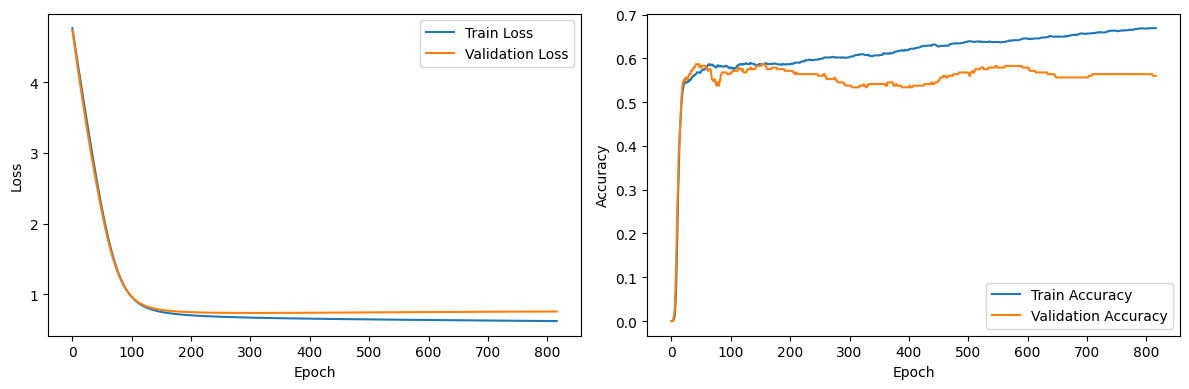


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2160, Val Loss: 4.1683, Train Acc: 0.1518, Val Acc: 0.1804
Epoch: 020, Train Loss: 3.6368, Val Loss: 3.6120, Train Acc: 0.4765, Val Acc: 0.4941
Epoch: 030, Train Loss: 3.0838, Val Loss: 3.0685, Train Acc: 0.5059, Val Acc: 0.5137
Epoch: 040, Train Loss: 2.5747, Val Loss: 2.5574, Train Acc: 0.5109, Val Acc: 0.5373
Epoch: 050, Train Loss: 2.1249, Val Loss: 2.1014, Train Acc: 0.5252, Val Acc: 0.5647
Epoch: 060, Train Loss: 1.7479, Val Loss: 1.7187, Train Acc: 0.5436, Val Acc: 0.5804
Epoch: 070, Train Loss: 1.4502, Val Loss: 1.4189, Train Acc: 0.5772, Val Acc: 0.5647
Epoch: 080, Train Loss: 1.2277, Val Loss: 1.1989, Train Acc: 0.5898, Val Acc: 0.5529
Epoch: 090, Train Loss: 1.0688, Val Loss: 1.0451, Train Acc: 0.5998, Val Acc: 0.5490
Epoch: 100, Train Loss: 0.9582, Val Loss: 0.9412, Train Acc: 0.6099, Val Acc: 0.5647
Epoch: 110, Train Loss: 0.8821, Val Loss: 0.8718, Tr

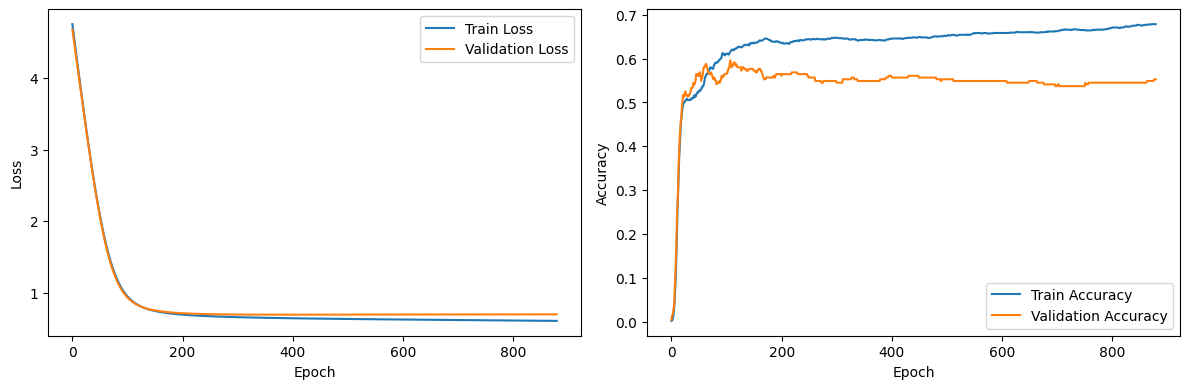


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2318, Val Loss: 4.2200, Train Acc: 0.1225, Val Acc: 0.1653
Epoch: 020, Train Loss: 3.7070, Val Loss: 3.6922, Train Acc: 0.5281, Val Acc: 0.4534
Epoch: 030, Train Loss: 3.1932, Val Loss: 3.2059, Train Acc: 0.5699, Val Acc: 0.4449
Epoch: 040, Train Loss: 2.6941, Val Loss: 2.7456, Train Acc: 0.5744, Val Acc: 0.4449
Epoch: 050, Train Loss: 2.2294, Val Loss: 2.3162, Train Acc: 0.5735, Val Acc: 0.4322
Epoch: 060, Train Loss: 1.8242, Val Loss: 1.9308, Train Acc: 0.5771, Val Acc: 0.4449
Epoch: 070, Train Loss: 1.4967, Val Loss: 1.6082, Train Acc: 0.5744, Val Acc: 0.4449
Epoch: 080, Train Loss: 1.2512, Val Loss: 1.3583, Train Acc: 0.5753, Val Acc: 0.4534
Epoch: 090, Train Loss: 1.0780, Val Loss: 1.1774, Train Acc: 0.5753, Val Acc: 0.4407
Epoch: 100, Train Loss: 0.9607, Val Loss: 1.0527, Train Acc: 0.5735, Val Acc: 0.4280
Epoch: 110, Train Loss: 0.8828, Val Loss: 0.9688, Tr

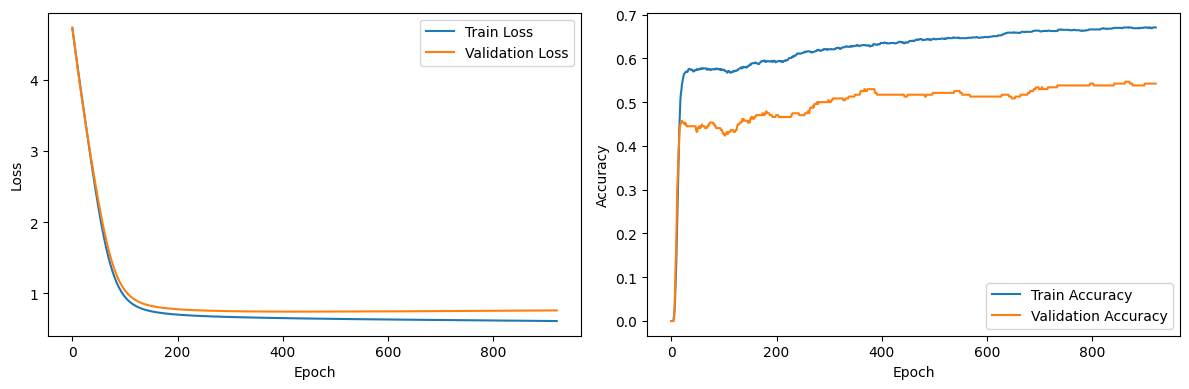


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1805, Val Loss: 4.0751, Train Acc: 0.2362, Val Acc: 0.2844
Epoch: 020, Train Loss: 3.5511, Val Loss: 3.4670, Train Acc: 0.4724, Val Acc: 0.5183
Epoch: 030, Train Loss: 2.9762, Val Loss: 2.9170, Train Acc: 0.5020, Val Acc: 0.5183
Epoch: 040, Train Loss: 2.4762, Val Loss: 2.4366, Train Acc: 0.5138, Val Acc: 0.5092
Epoch: 050, Train Loss: 2.0510, Val Loss: 2.0247, Train Acc: 0.5177, Val Acc: 0.5229
Epoch: 060, Train Loss: 1.7028, Val Loss: 1.6837, Train Acc: 0.5266, Val Acc: 0.5642
Epoch: 070, Train Loss: 1.4309, Val Loss: 1.4146, Train Acc: 0.5354, Val Acc: 0.6193
Epoch: 080, Train Loss: 1.2270, Val Loss: 1.2127, Train Acc: 0.5384, Val Acc: 0.6330
Epoch: 090, Train Loss: 1.0785, Val Loss: 1.0669, Train Acc: 0.5512, Val Acc: 0.6468
Epoch: 100, Train Loss: 0.9725, Val Loss: 0.9643, Train Acc: 0.5581, Val Acc: 0.6422
Epoch: 110, Train Loss: 0.8974, Val Loss: 0.8929, Tr

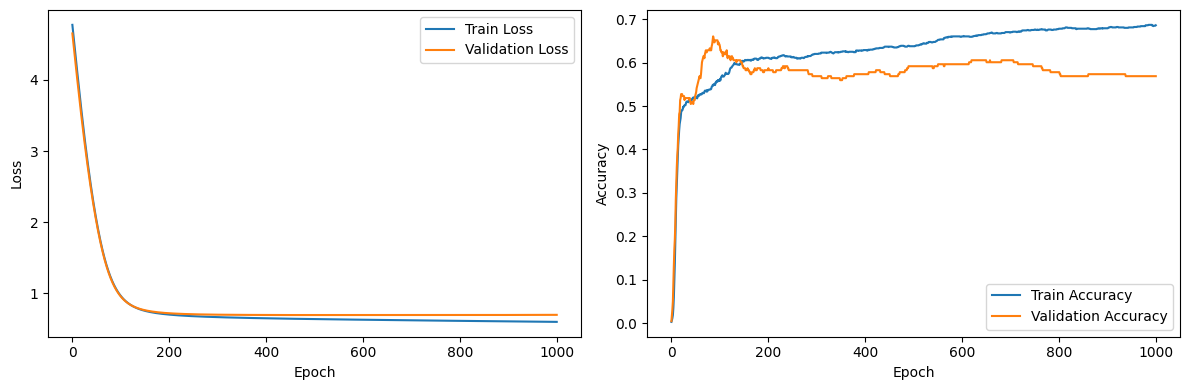


========== Run 5 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0259, Val Loss: 3.9614, Train Acc: 0.3457, Val Acc: 0.3835
Epoch: 020, Train Loss: 3.4761, Val Loss: 3.4011, Train Acc: 0.5149, Val Acc: 0.5451
Epoch: 030, Train Loss: 2.9541, Val Loss: 2.8938, Train Acc: 0.5254, Val Acc: 0.5526
Epoch: 040, Train Loss: 2.4683, Val Loss: 2.4276, Train Acc: 0.5342, Val Acc: 0.5526
Epoch: 050, Train Loss: 2.0343, Val Loss: 2.0091, Train Acc: 0.5439, Val Acc: 0.5526
Epoch: 060, Train Loss: 1.6704, Val Loss: 1.6553, Train Acc: 0.5560, Val Acc: 0.5827
Epoch: 070, Train Loss: 1.3851, Val Loss: 1.3763, Train Acc: 0.5786, Val Acc: 0.5714
Epoch: 080, Train Loss: 1.1750, Val Loss: 1.1716, Train Acc: 0.5810, Val Acc: 0.5752
Epoch: 090, Train Loss: 1.0275, Val Loss: 1.0305, Train Acc: 0.5826, Val Acc: 0.5752
Epoch: 100, Train Loss: 0.9264, Val Loss: 0.9370, Train Acc: 0.5898, Val Acc: 0.5827
Epoch: 110, Train Loss

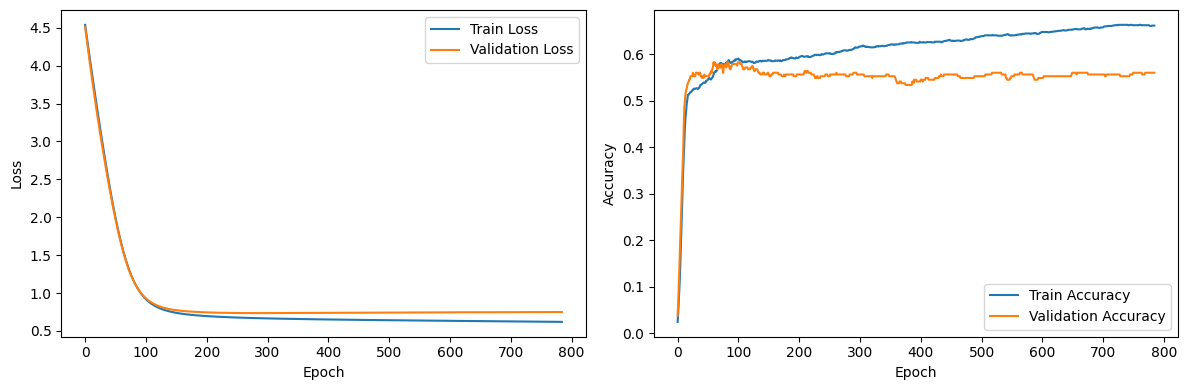


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1036, Val Loss: 4.0651, Train Acc: 0.2508, Val Acc: 0.3020
Epoch: 020, Train Loss: 3.5570, Val Loss: 3.5375, Train Acc: 0.4958, Val Acc: 0.5255
Epoch: 030, Train Loss: 3.0261, Val Loss: 3.0128, Train Acc: 0.5176, Val Acc: 0.5569
Epoch: 040, Train Loss: 2.5262, Val Loss: 2.5092, Train Acc: 0.5344, Val Acc: 0.5725
Epoch: 050, Train Loss: 2.0764, Val Loss: 2.0516, Train Acc: 0.5596, Val Acc: 0.5765
Epoch: 060, Train Loss: 1.6977, Val Loss: 1.6658, Train Acc: 0.5621, Val Acc: 0.5843
Epoch: 070, Train Loss: 1.4011, Val Loss: 1.3664, Train Acc: 0.5671, Val Acc: 0.5765
Epoch: 080, Train Loss: 1.1840, Val Loss: 1.1516, Train Acc: 0.5856, Val Acc: 0.5922
Epoch: 090, Train Loss: 1.0329, Val Loss: 1.0062, Train Acc: 0.5956, Val Acc: 0.5804
Epoch: 100, Train Loss: 0.9307, Val Loss: 0.9110, Train Acc: 0.6015, Val Acc: 0.5804
Epoch: 110, Train Loss: 0.8618, Val Loss: 0.8489, Tr

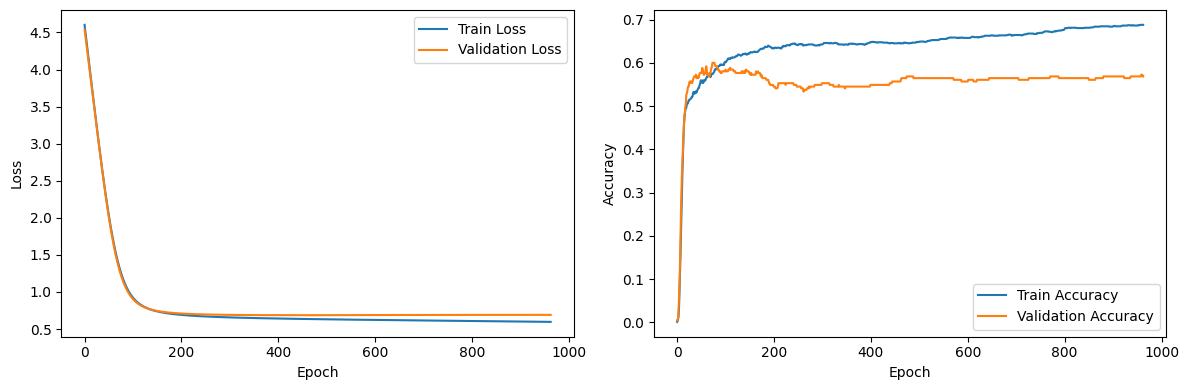


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0732, Val Loss: 4.0995, Train Acc: 0.2877, Val Acc: 0.3475
Epoch: 020, Train Loss: 3.5589, Val Loss: 3.6112, Train Acc: 0.5045, Val Acc: 0.4958
Epoch: 030, Train Loss: 3.0594, Val Loss: 3.1493, Train Acc: 0.5191, Val Acc: 0.5000
Epoch: 040, Train Loss: 2.5851, Val Loss: 2.7121, Train Acc: 0.5336, Val Acc: 0.4958
Epoch: 050, Train Loss: 2.1523, Val Loss: 2.3012, Train Acc: 0.5481, Val Acc: 0.4873
Epoch: 060, Train Loss: 1.7776, Val Loss: 1.9297, Train Acc: 0.5599, Val Acc: 0.4873
Epoch: 070, Train Loss: 1.4722, Val Loss: 1.6154, Train Acc: 0.5644, Val Acc: 0.4788
Epoch: 080, Train Loss: 1.2393, Val Loss: 1.3693, Train Acc: 0.5789, Val Acc: 0.4576
Epoch: 090, Train Loss: 1.0723, Val Loss: 1.1909, Train Acc: 0.5644, Val Acc: 0.4619
Epoch: 100, Train Loss: 0.9569, Val Loss: 1.0675, Train Acc: 0.5635, Val Acc: 0.4788
Epoch: 110, Train Loss: 0.8787, Val Loss: 0.9836, Tr

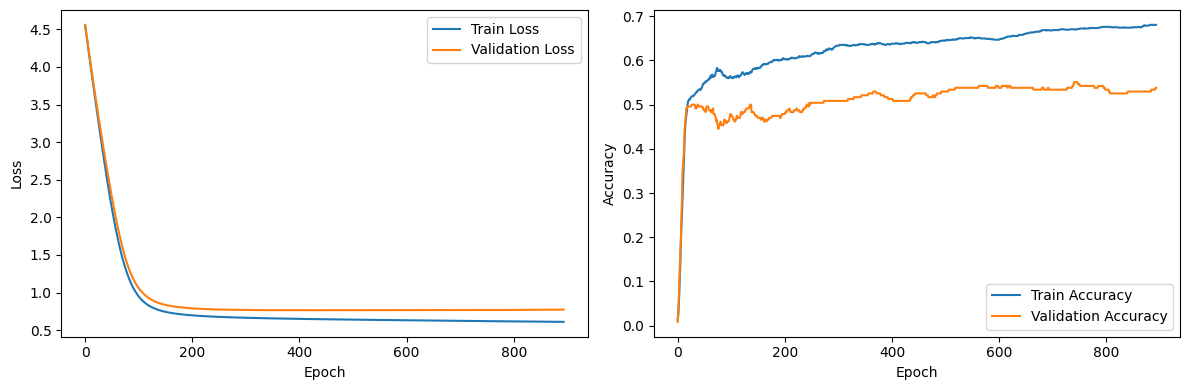


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0285, Val Loss: 3.9938, Train Acc: 0.2441, Val Acc: 0.2706
Epoch: 020, Train Loss: 3.4369, Val Loss: 3.4117, Train Acc: 0.5108, Val Acc: 0.4908
Epoch: 030, Train Loss: 2.9001, Val Loss: 2.8843, Train Acc: 0.5394, Val Acc: 0.5183
Epoch: 040, Train Loss: 2.4281, Val Loss: 2.4202, Train Acc: 0.5463, Val Acc: 0.5138
Epoch: 050, Train Loss: 2.0241, Val Loss: 2.0201, Train Acc: 0.5413, Val Acc: 0.5092
Epoch: 060, Train Loss: 1.6919, Val Loss: 1.6879, Train Acc: 0.5571, Val Acc: 0.5321
Epoch: 070, Train Loss: 1.4304, Val Loss: 1.4251, Train Acc: 0.5591, Val Acc: 0.5596
Epoch: 080, Train Loss: 1.2321, Val Loss: 1.2266, Train Acc: 0.5699, Val Acc: 0.5688
Epoch: 090, Train Loss: 1.0861, Val Loss: 1.0818, Train Acc: 0.5758, Val Acc: 0.5642
Epoch: 100, Train Loss: 0.9804, Val Loss: 0.9784, Train Acc: 0.5768, Val Acc: 0.5596
Epoch: 110, Train Loss: 0.9045, Val Loss: 0.9051, Tr

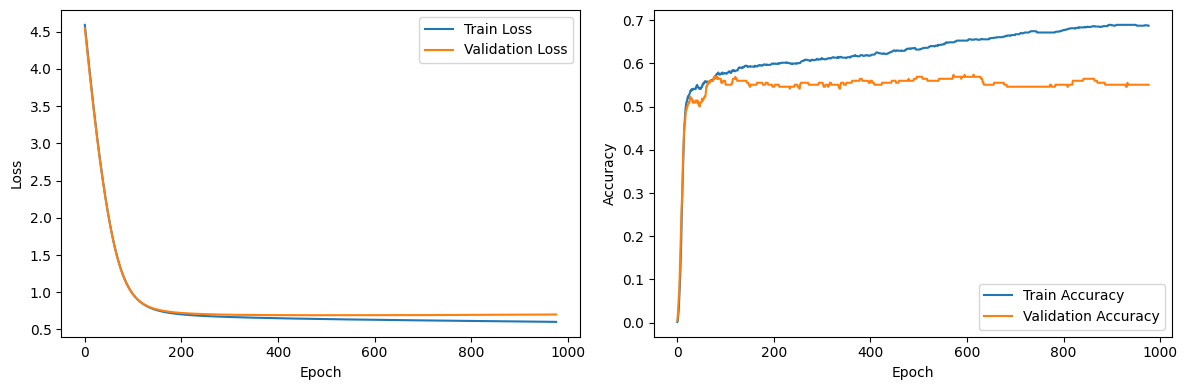


========== Run 6 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1436, Val Loss: 4.0971, Train Acc: 0.2691, Val Acc: 0.3008
Epoch: 020, Train Loss: 3.6023, Val Loss: 3.5418, Train Acc: 0.5246, Val Acc: 0.5075
Epoch: 030, Train Loss: 3.0802, Val Loss: 3.0283, Train Acc: 0.5463, Val Acc: 0.5150
Epoch: 040, Train Loss: 2.5873, Val Loss: 2.5558, Train Acc: 0.5624, Val Acc: 0.5263
Epoch: 050, Train Loss: 2.1400, Val Loss: 2.1291, Train Acc: 0.5721, Val Acc: 0.5338
Epoch: 060, Train Loss: 1.7580, Val Loss: 1.7641, Train Acc: 0.5802, Val Acc: 0.5451
Epoch: 070, Train Loss: 1.4524, Val Loss: 1.4714, Train Acc: 0.5802, Val Acc: 0.5489
Epoch: 080, Train Loss: 1.2224, Val Loss: 1.2504, Train Acc: 0.5794, Val Acc: 0.5639
Epoch: 090, Train Loss: 1.0582, Val Loss: 1.0920, Train Acc: 0.5866, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.9456, Val Loss: 0.9832, Train Acc: 0.5898, Val Acc: 0.5940
Epoch: 110, Train Loss

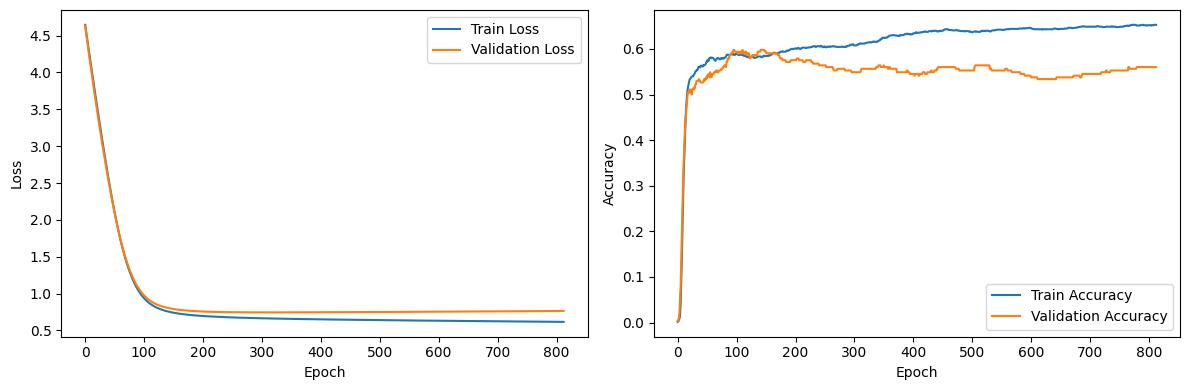


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1694, Val Loss: 4.1380, Train Acc: 0.1611, Val Acc: 0.2039
Epoch: 020, Train Loss: 3.6402, Val Loss: 3.6262, Train Acc: 0.4832, Val Acc: 0.5020
Epoch: 030, Train Loss: 3.1200, Val Loss: 3.1117, Train Acc: 0.5260, Val Acc: 0.5373
Epoch: 040, Train Loss: 2.6209, Val Loss: 2.6075, Train Acc: 0.5336, Val Acc: 0.5608
Epoch: 050, Train Loss: 2.1620, Val Loss: 2.1398, Train Acc: 0.5470, Val Acc: 0.5686
Epoch: 060, Train Loss: 1.7671, Val Loss: 1.7381, Train Acc: 0.5612, Val Acc: 0.5804
Epoch: 070, Train Loss: 1.4522, Val Loss: 1.4218, Train Acc: 0.5831, Val Acc: 0.5608
Epoch: 080, Train Loss: 1.2183, Val Loss: 1.1920, Train Acc: 0.5797, Val Acc: 0.5647
Epoch: 090, Train Loss: 1.0540, Val Loss: 1.0348, Train Acc: 0.5872, Val Acc: 0.5569
Epoch: 100, Train Loss: 0.9427, Val Loss: 0.9314, Train Acc: 0.5906, Val Acc: 0.5686
Epoch: 110, Train Loss: 0.8684, Val Loss: 0.8644, Tr

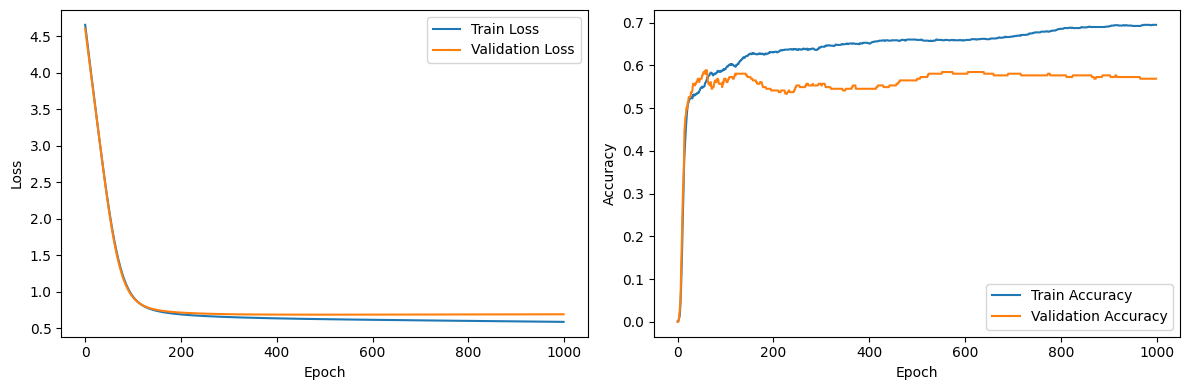


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0411, Val Loss: 3.9873, Train Acc: 0.3040, Val Acc: 0.3517
Epoch: 020, Train Loss: 3.5194, Val Loss: 3.4891, Train Acc: 0.5281, Val Acc: 0.4746
Epoch: 030, Train Loss: 3.0122, Val Loss: 3.0244, Train Acc: 0.5363, Val Acc: 0.4703
Epoch: 040, Train Loss: 2.5301, Val Loss: 2.5831, Train Acc: 0.5417, Val Acc: 0.4703
Epoch: 050, Train Loss: 2.0895, Val Loss: 2.1704, Train Acc: 0.5517, Val Acc: 0.4703
Epoch: 060, Train Loss: 1.7107, Val Loss: 1.8043, Train Acc: 0.5617, Val Acc: 0.4958
Epoch: 070, Train Loss: 1.4084, Val Loss: 1.5036, Train Acc: 0.5617, Val Acc: 0.4703
Epoch: 080, Train Loss: 1.1852, Val Loss: 1.2768, Train Acc: 0.5735, Val Acc: 0.4788
Epoch: 090, Train Loss: 1.0304, Val Loss: 1.1183, Train Acc: 0.5708, Val Acc: 0.4831
Epoch: 100, Train Loss: 0.9270, Val Loss: 1.0126, Train Acc: 0.5753, Val Acc: 0.4661
Epoch: 110, Train Loss: 0.8584, Val Loss: 0.9421, Tr

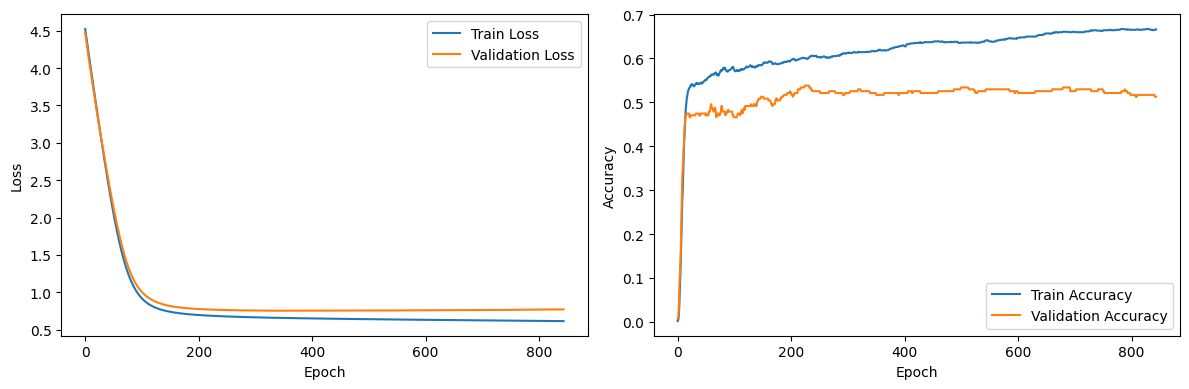


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1075, Val Loss: 4.0537, Train Acc: 0.2746, Val Acc: 0.3211
Epoch: 020, Train Loss: 3.5110, Val Loss: 3.4706, Train Acc: 0.4921, Val Acc: 0.4633
Epoch: 030, Train Loss: 2.9712, Val Loss: 2.9402, Train Acc: 0.5246, Val Acc: 0.4908
Epoch: 040, Train Loss: 2.4900, Val Loss: 2.4690, Train Acc: 0.5276, Val Acc: 0.4862
Epoch: 050, Train Loss: 2.0681, Val Loss: 2.0552, Train Acc: 0.5354, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.7136, Val Loss: 1.7057, Train Acc: 0.5423, Val Acc: 0.5000
Epoch: 070, Train Loss: 1.4317, Val Loss: 1.4274, Train Acc: 0.5502, Val Acc: 0.5229
Epoch: 080, Train Loss: 1.2191, Val Loss: 1.2190, Train Acc: 0.5748, Val Acc: 0.5321
Epoch: 090, Train Loss: 1.0658, Val Loss: 1.0704, Train Acc: 0.5797, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.9584, Val Loss: 0.9673, Train Acc: 0.5896, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.8841, Val Loss: 0.8965, Tr

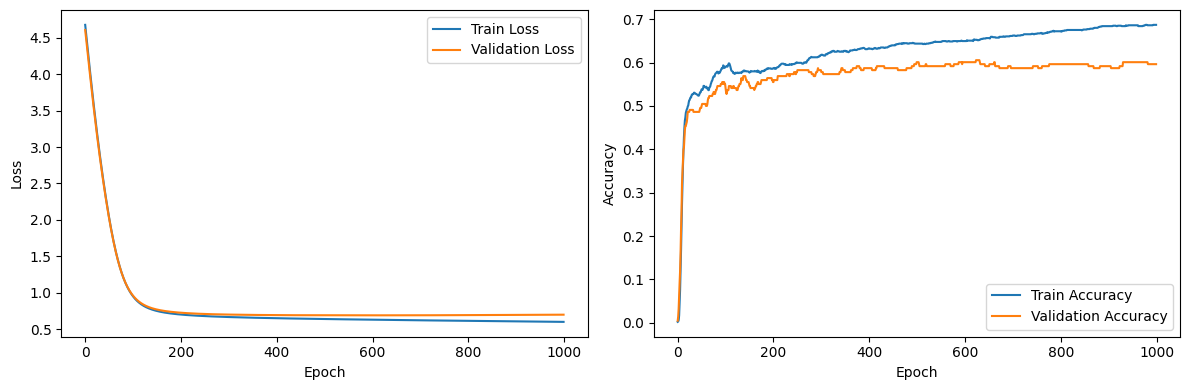


========== Run 7 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1378, Val Loss: 4.0570, Train Acc: 0.1805, Val Acc: 0.2256
Epoch: 020, Train Loss: 3.5664, Val Loss: 3.4585, Train Acc: 0.5262, Val Acc: 0.4887
Epoch: 030, Train Loss: 3.0298, Val Loss: 2.9279, Train Acc: 0.5592, Val Acc: 0.5263
Epoch: 040, Train Loss: 2.5377, Val Loss: 2.4545, Train Acc: 0.5568, Val Acc: 0.5301
Epoch: 050, Train Loss: 2.1017, Val Loss: 2.0375, Train Acc: 0.5649, Val Acc: 0.5376
Epoch: 060, Train Loss: 1.7352, Val Loss: 1.6881, Train Acc: 0.5705, Val Acc: 0.5564
Epoch: 070, Train Loss: 1.4443, Val Loss: 1.4124, Train Acc: 0.5745, Val Acc: 0.5714
Epoch: 080, Train Loss: 1.2254, Val Loss: 1.2071, Train Acc: 0.5786, Val Acc: 0.5752
Epoch: 090, Train Loss: 1.0678, Val Loss: 1.0615, Train Acc: 0.5786, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.9578, Val Loss: 0.9621, Train Acc: 0.5834, Val Acc: 0.5902
Epoch: 110, Train Loss

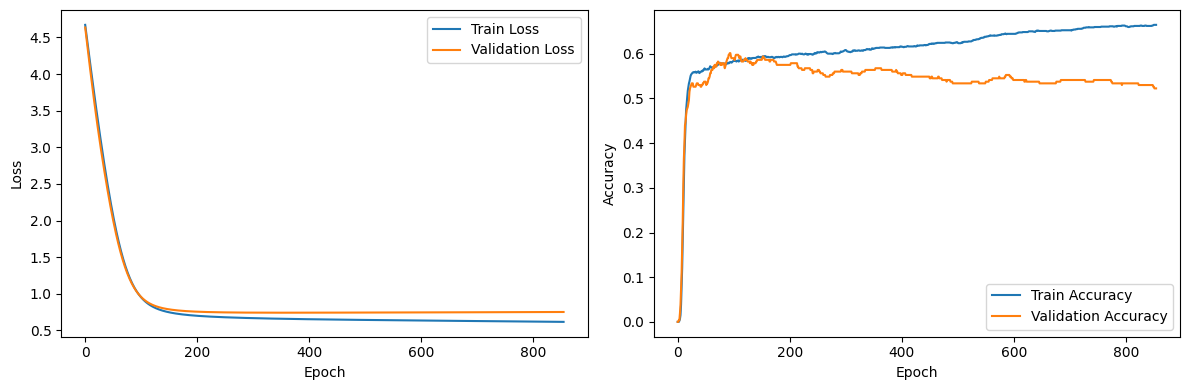


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1948, Val Loss: 4.1305, Train Acc: 0.1720, Val Acc: 0.2471
Epoch: 020, Train Loss: 3.6521, Val Loss: 3.6118, Train Acc: 0.5755, Val Acc: 0.5451
Epoch: 030, Train Loss: 3.1229, Val Loss: 3.0947, Train Acc: 0.5847, Val Acc: 0.5333
Epoch: 040, Train Loss: 2.6208, Val Loss: 2.5938, Train Acc: 0.5982, Val Acc: 0.5451
Epoch: 050, Train Loss: 2.1632, Val Loss: 2.1329, Train Acc: 0.6015, Val Acc: 0.5373
Epoch: 060, Train Loss: 1.7726, Val Loss: 1.7387, Train Acc: 0.6057, Val Acc: 0.5569
Epoch: 070, Train Loss: 1.4633, Val Loss: 1.4283, Train Acc: 0.6065, Val Acc: 0.5569
Epoch: 080, Train Loss: 1.2339, Val Loss: 1.2016, Train Acc: 0.6107, Val Acc: 0.5608
Epoch: 090, Train Loss: 1.0715, Val Loss: 1.0446, Train Acc: 0.6116, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.9594, Val Loss: 0.9387, Train Acc: 0.6124, Val Acc: 0.5529
Epoch: 110, Train Loss: 0.8825, Val Loss: 0.8675, Tr

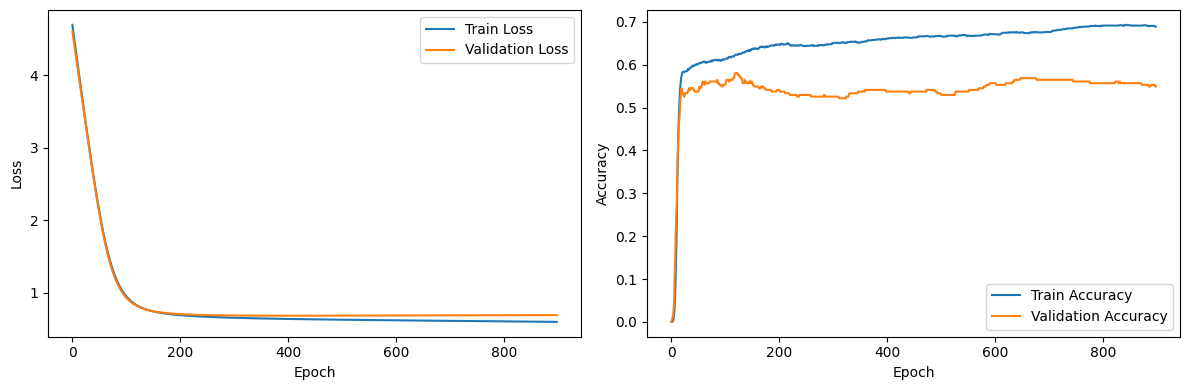


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0580, Val Loss: 3.9234, Train Acc: 0.3403, Val Acc: 0.4237
Epoch: 020, Train Loss: 3.5295, Val Loss: 3.4295, Train Acc: 0.4909, Val Acc: 0.4958
Epoch: 030, Train Loss: 3.0238, Val Loss: 2.9714, Train Acc: 0.4991, Val Acc: 0.5000
Epoch: 040, Train Loss: 2.5505, Val Loss: 2.5448, Train Acc: 0.5000, Val Acc: 0.5000
Epoch: 050, Train Loss: 2.1245, Val Loss: 2.1530, Train Acc: 0.5045, Val Acc: 0.5212
Epoch: 060, Train Loss: 1.7605, Val Loss: 1.8139, Train Acc: 0.5082, Val Acc: 0.5254
Epoch: 070, Train Loss: 1.4659, Val Loss: 1.5367, Train Acc: 0.5082, Val Acc: 0.5169
Epoch: 080, Train Loss: 1.2396, Val Loss: 1.3167, Train Acc: 0.5309, Val Acc: 0.5169
Epoch: 090, Train Loss: 1.0756, Val Loss: 1.1525, Train Acc: 0.5472, Val Acc: 0.5127
Epoch: 100, Train Loss: 0.9613, Val Loss: 1.0345, Train Acc: 0.5608, Val Acc: 0.5042
Epoch: 110, Train Loss: 0.8834, Val Loss: 0.9518, Tr

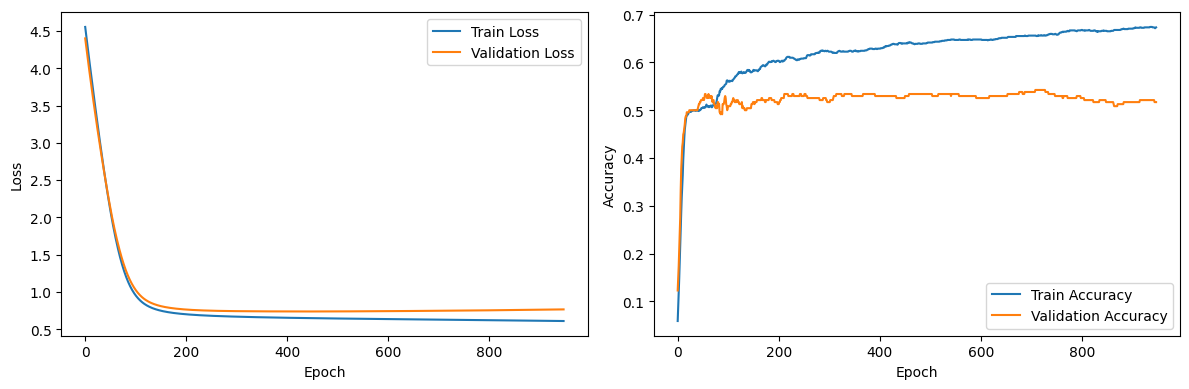


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0898, Val Loss: 4.0238, Train Acc: 0.1496, Val Acc: 0.2752
Epoch: 020, Train Loss: 3.4902, Val Loss: 3.4423, Train Acc: 0.4961, Val Acc: 0.4862
Epoch: 030, Train Loss: 2.9298, Val Loss: 2.9062, Train Acc: 0.5472, Val Acc: 0.5046
Epoch: 040, Train Loss: 2.4324, Val Loss: 2.4315, Train Acc: 0.5512, Val Acc: 0.5046
Epoch: 050, Train Loss: 2.0079, Val Loss: 2.0217, Train Acc: 0.5630, Val Acc: 0.5138
Epoch: 060, Train Loss: 1.6606, Val Loss: 1.6808, Train Acc: 0.5659, Val Acc: 0.5275
Epoch: 070, Train Loss: 1.3909, Val Loss: 1.4116, Train Acc: 0.5787, Val Acc: 0.5367
Epoch: 080, Train Loss: 1.1909, Val Loss: 1.2101, Train Acc: 0.5768, Val Acc: 0.5596
Epoch: 090, Train Loss: 1.0478, Val Loss: 1.0660, Train Acc: 0.5876, Val Acc: 0.5963
Epoch: 100, Train Loss: 0.9476, Val Loss: 0.9657, Train Acc: 0.5955, Val Acc: 0.5963
Epoch: 110, Train Loss: 0.8776, Val Loss: 0.8964, Tr

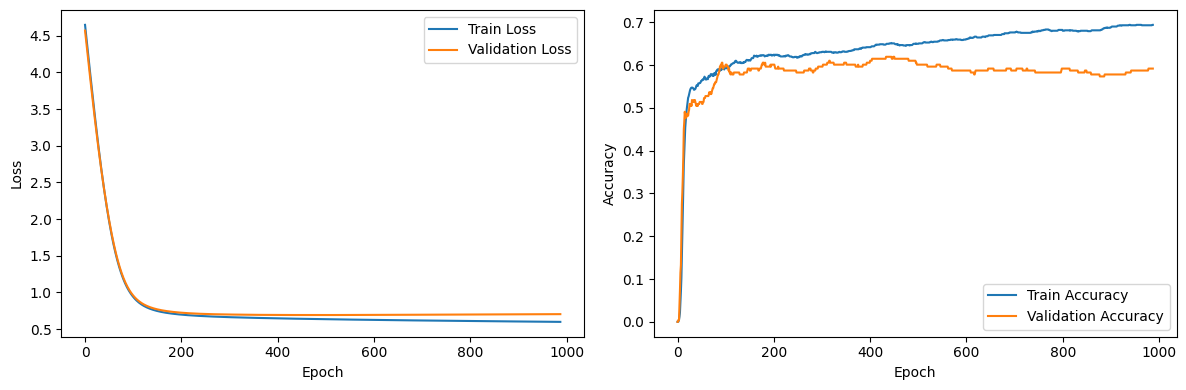


========== Run 8 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9127, Val Loss: 3.8242, Train Acc: 0.3892, Val Acc: 0.4248
Epoch: 020, Train Loss: 3.3790, Val Loss: 3.2746, Train Acc: 0.5036, Val Acc: 0.4925
Epoch: 030, Train Loss: 2.8718, Val Loss: 2.7743, Train Acc: 0.5117, Val Acc: 0.4925
Epoch: 040, Train Loss: 2.4000, Val Loss: 2.3179, Train Acc: 0.5125, Val Acc: 0.4962
Epoch: 050, Train Loss: 1.9810, Val Loss: 1.9156, Train Acc: 0.5165, Val Acc: 0.5188
Epoch: 060, Train Loss: 1.6316, Val Loss: 1.5824, Train Acc: 0.5278, Val Acc: 0.5188
Epoch: 070, Train Loss: 1.3579, Val Loss: 1.3243, Train Acc: 0.5504, Val Acc: 0.5263
Epoch: 080, Train Loss: 1.1554, Val Loss: 1.1362, Train Acc: 0.5770, Val Acc: 0.5414
Epoch: 090, Train Loss: 1.0125, Val Loss: 1.0053, Train Acc: 0.5802, Val Acc: 0.5489
Epoch: 100, Train Loss: 0.9149, Val Loss: 0.9172, Train Acc: 0.5882, Val Acc: 0.5564
Epoch: 110, Train Loss

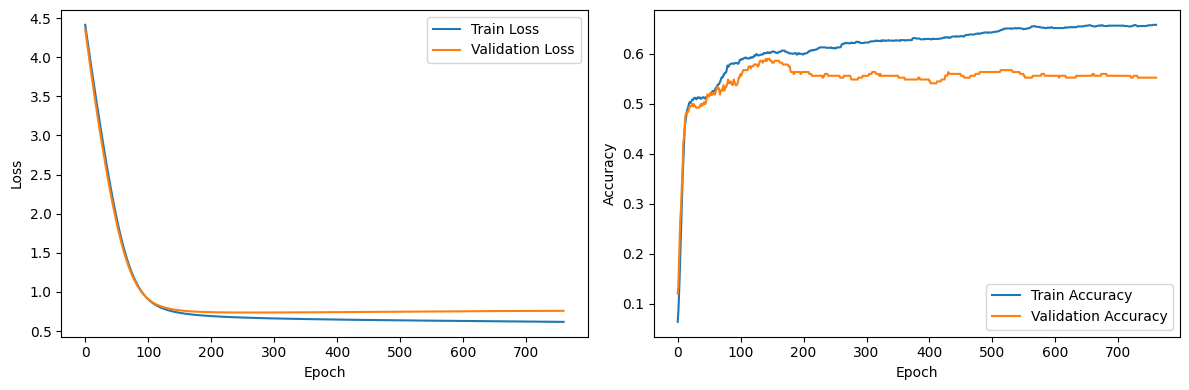


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9664, Val Loss: 3.9340, Train Acc: 0.3096, Val Acc: 0.3137
Epoch: 020, Train Loss: 3.4155, Val Loss: 3.3972, Train Acc: 0.4606, Val Acc: 0.4157
Epoch: 030, Train Loss: 2.8982, Val Loss: 2.8828, Train Acc: 0.4698, Val Acc: 0.4510
Epoch: 040, Train Loss: 2.4284, Val Loss: 2.4117, Train Acc: 0.4849, Val Acc: 0.4510
Epoch: 050, Train Loss: 2.0187, Val Loss: 2.0006, Train Acc: 0.4975, Val Acc: 0.4706
Epoch: 060, Train Loss: 1.6778, Val Loss: 1.6596, Train Acc: 0.5285, Val Acc: 0.5020
Epoch: 070, Train Loss: 1.4072, Val Loss: 1.3909, Train Acc: 0.5663, Val Acc: 0.5294
Epoch: 080, Train Loss: 1.2016, Val Loss: 1.1887, Train Acc: 0.5982, Val Acc: 0.5216
Epoch: 090, Train Loss: 1.0511, Val Loss: 1.0425, Train Acc: 0.6074, Val Acc: 0.5216
Epoch: 100, Train Loss: 0.9442, Val Loss: 0.9404, Train Acc: 0.6082, Val Acc: 0.5255
Epoch: 110, Train Loss: 0.8697, Val Loss: 0.8708, Tr

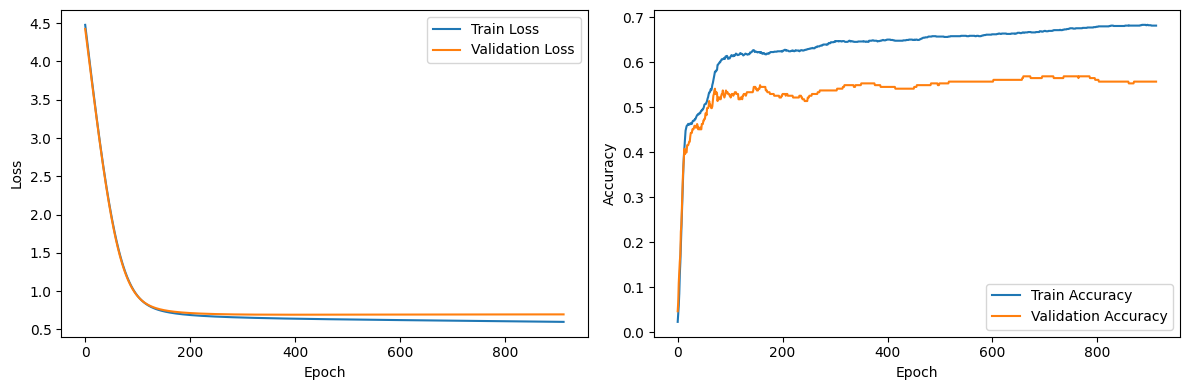


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0758, Val Loss: 4.0728, Train Acc: 0.3485, Val Acc: 0.3602
Epoch: 020, Train Loss: 3.5556, Val Loss: 3.5760, Train Acc: 0.5436, Val Acc: 0.4915
Epoch: 030, Train Loss: 3.0384, Val Loss: 3.0948, Train Acc: 0.5472, Val Acc: 0.4788
Epoch: 040, Train Loss: 2.5396, Val Loss: 2.6333, Train Acc: 0.5526, Val Acc: 0.5085
Epoch: 050, Train Loss: 2.0849, Val Loss: 2.2027, Train Acc: 0.5626, Val Acc: 0.5042
Epoch: 060, Train Loss: 1.7005, Val Loss: 1.8237, Train Acc: 0.5572, Val Acc: 0.4746
Epoch: 070, Train Loss: 1.3992, Val Loss: 1.5152, Train Acc: 0.5517, Val Acc: 0.4449
Epoch: 080, Train Loss: 1.1790, Val Loss: 1.2846, Train Acc: 0.5436, Val Acc: 0.4576
Epoch: 090, Train Loss: 1.0264, Val Loss: 1.1237, Train Acc: 0.5508, Val Acc: 0.4661
Epoch: 100, Train Loss: 0.9242, Val Loss: 1.0161, Train Acc: 0.5617, Val Acc: 0.4534
Epoch: 110, Train Loss: 0.8565, Val Loss: 0.9448, Tr

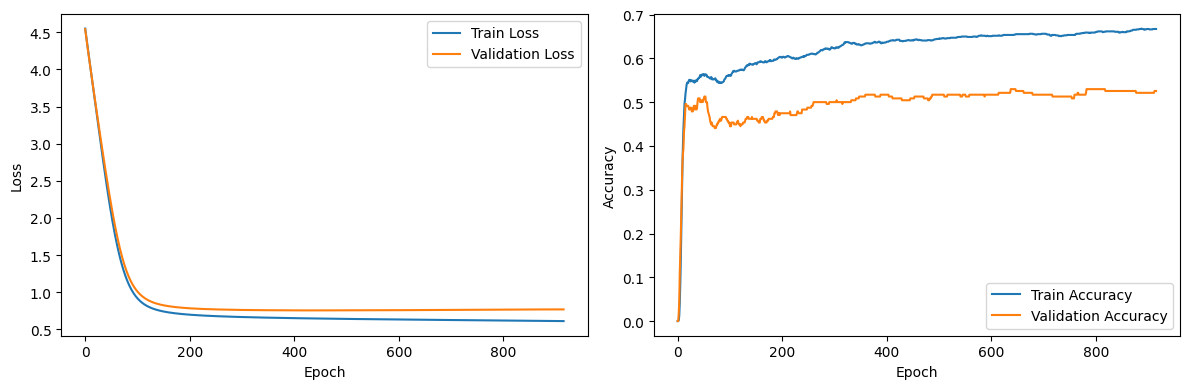


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2298, Val Loss: 4.1799, Train Acc: 0.1073, Val Acc: 0.1468
Epoch: 020, Train Loss: 3.6236, Val Loss: 3.5823, Train Acc: 0.4892, Val Acc: 0.4587
Epoch: 030, Train Loss: 3.0573, Val Loss: 3.0329, Train Acc: 0.5404, Val Acc: 0.4633
Epoch: 040, Train Loss: 2.5537, Val Loss: 2.5483, Train Acc: 0.5423, Val Acc: 0.4587
Epoch: 050, Train Loss: 2.1204, Val Loss: 2.1282, Train Acc: 0.5404, Val Acc: 0.4725
Epoch: 060, Train Loss: 1.7611, Val Loss: 1.7751, Train Acc: 0.5522, Val Acc: 0.4862
Epoch: 070, Train Loss: 1.4760, Val Loss: 1.4918, Train Acc: 0.5600, Val Acc: 0.5000
Epoch: 080, Train Loss: 1.2595, Val Loss: 1.2760, Train Acc: 0.5738, Val Acc: 0.5046
Epoch: 090, Train Loss: 1.1010, Val Loss: 1.1184, Train Acc: 0.5679, Val Acc: 0.5413
Epoch: 100, Train Loss: 0.9878, Val Loss: 1.0068, Train Acc: 0.5748, Val Acc: 0.5321
Epoch: 110, Train Loss: 0.9080, Val Loss: 0.9286, Tr

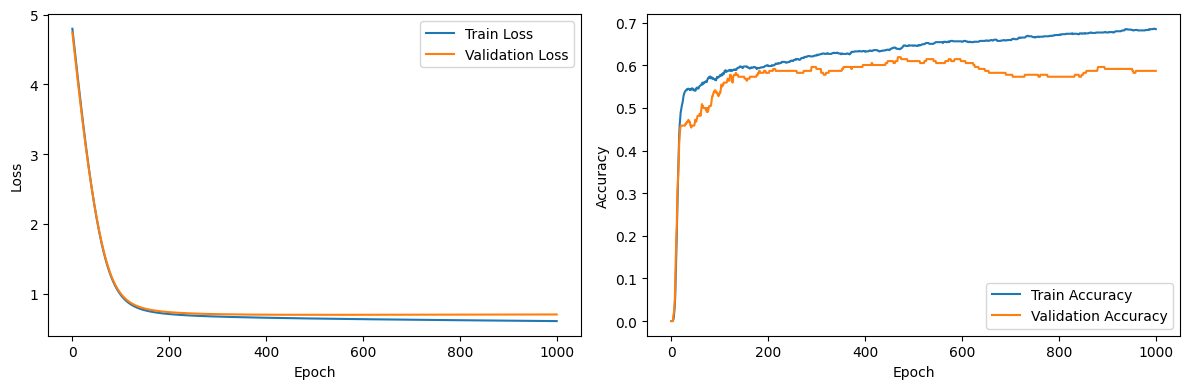


========== Run 9 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1487, Val Loss: 4.0631, Train Acc: 0.2127, Val Acc: 0.3158
Epoch: 020, Train Loss: 3.6184, Val Loss: 3.5036, Train Acc: 0.5479, Val Acc: 0.5414
Epoch: 030, Train Loss: 3.1037, Val Loss: 2.9868, Train Acc: 0.5600, Val Acc: 0.5564
Epoch: 040, Train Loss: 2.6144, Val Loss: 2.5125, Train Acc: 0.5705, Val Acc: 0.5714
Epoch: 050, Train Loss: 2.1670, Val Loss: 2.0864, Train Acc: 0.5786, Val Acc: 0.5752
Epoch: 060, Train Loss: 1.7816, Val Loss: 1.7234, Train Acc: 0.5778, Val Acc: 0.5714
Epoch: 070, Train Loss: 1.4708, Val Loss: 1.4340, Train Acc: 0.5729, Val Acc: 0.5714
Epoch: 080, Train Loss: 1.2359, Val Loss: 1.2174, Train Acc: 0.5713, Val Acc: 0.5789
Epoch: 090, Train Loss: 1.0680, Val Loss: 1.0640, Train Acc: 0.5729, Val Acc: 0.5827
Epoch: 100, Train Loss: 0.9528, Val Loss: 0.9597, Train Acc: 0.5721, Val Acc: 0.5827
Epoch: 110, Train Loss

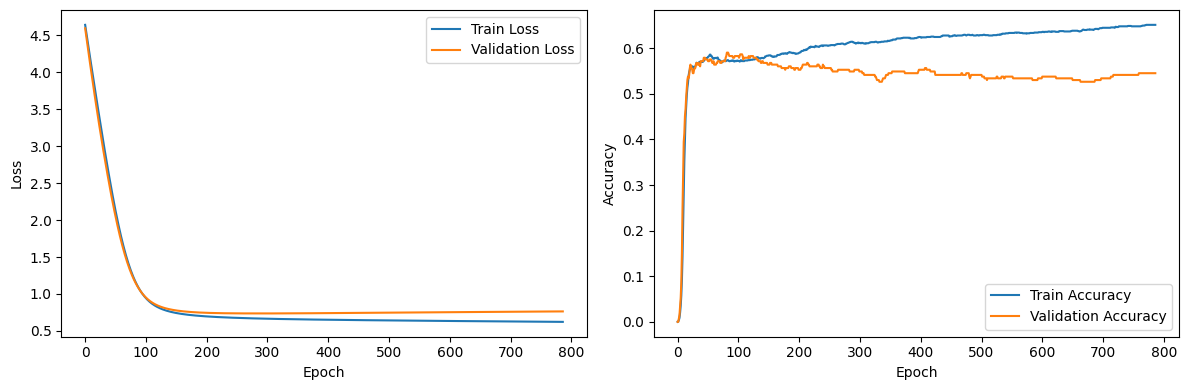


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9668, Val Loss: 3.9304, Train Acc: 0.3616, Val Acc: 0.3765
Epoch: 020, Train Loss: 3.4265, Val Loss: 3.4044, Train Acc: 0.5394, Val Acc: 0.5020
Epoch: 030, Train Loss: 2.9098, Val Loss: 2.8899, Train Acc: 0.5638, Val Acc: 0.5216
Epoch: 040, Train Loss: 2.4306, Val Loss: 2.4061, Train Acc: 0.5738, Val Acc: 0.5412
Epoch: 050, Train Loss: 2.0059, Val Loss: 1.9751, Train Acc: 0.5789, Val Acc: 0.5725
Epoch: 060, Train Loss: 1.6524, Val Loss: 1.6164, Train Acc: 0.5856, Val Acc: 0.5765
Epoch: 070, Train Loss: 1.3767, Val Loss: 1.3392, Train Acc: 0.5898, Val Acc: 0.5686
Epoch: 080, Train Loss: 1.1729, Val Loss: 1.1385, Train Acc: 0.5982, Val Acc: 0.5765
Epoch: 090, Train Loss: 1.0284, Val Loss: 1.0003, Train Acc: 0.5998, Val Acc: 0.5843
Epoch: 100, Train Loss: 0.9285, Val Loss: 0.9077, Train Acc: 0.5973, Val Acc: 0.5765
Epoch: 110, Train Loss: 0.8600, Val Loss: 0.8462, Tr

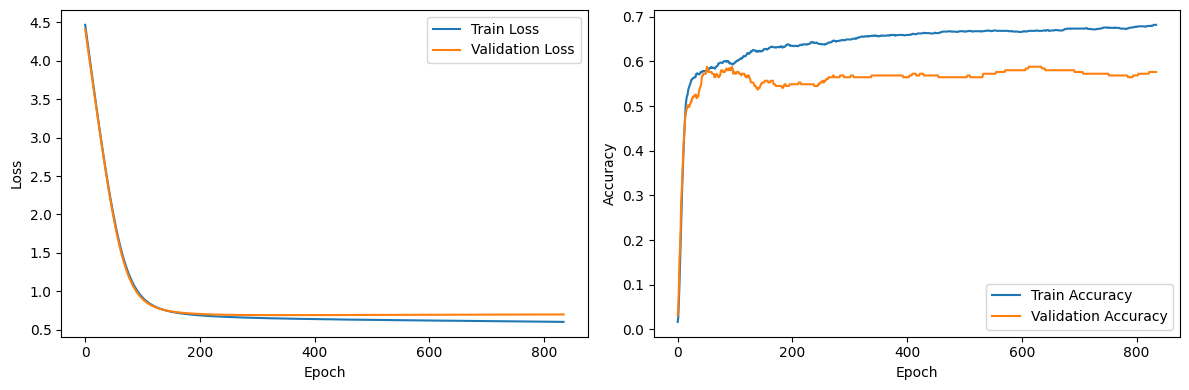


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1422, Val Loss: 4.1206, Train Acc: 0.2559, Val Acc: 0.3178
Epoch: 020, Train Loss: 3.6115, Val Loss: 3.6042, Train Acc: 0.4701, Val Acc: 0.5000
Epoch: 030, Train Loss: 3.0893, Val Loss: 3.1114, Train Acc: 0.4882, Val Acc: 0.4958
Epoch: 040, Train Loss: 2.5873, Val Loss: 2.6458, Train Acc: 0.5018, Val Acc: 0.5000
Epoch: 050, Train Loss: 2.1268, Val Loss: 2.2153, Train Acc: 0.5045, Val Acc: 0.5000
Epoch: 060, Train Loss: 1.7325, Val Loss: 1.8369, Train Acc: 0.5118, Val Acc: 0.4873
Epoch: 070, Train Loss: 1.4212, Val Loss: 1.5292, Train Acc: 0.5245, Val Acc: 0.4958
Epoch: 080, Train Loss: 1.1937, Val Loss: 1.2979, Train Acc: 0.5318, Val Acc: 0.4915
Epoch: 090, Train Loss: 1.0368, Val Loss: 1.1347, Train Acc: 0.5345, Val Acc: 0.5000
Epoch: 100, Train Loss: 0.9319, Val Loss: 1.0243, Train Acc: 0.5490, Val Acc: 0.4915
Epoch: 110, Train Loss: 0.8623, Val Loss: 0.9510, Tr

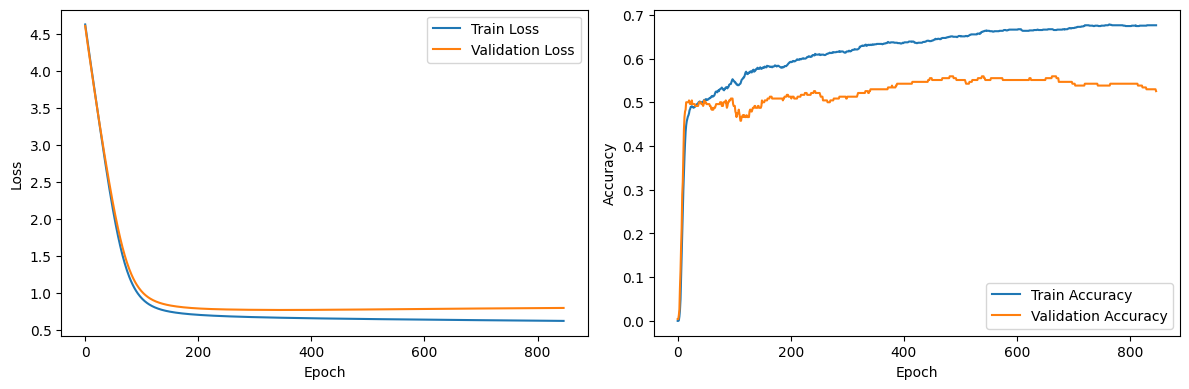


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0442, Val Loss: 4.0092, Train Acc: 0.2825, Val Acc: 0.3532
Epoch: 020, Train Loss: 3.4692, Val Loss: 3.4441, Train Acc: 0.4951, Val Acc: 0.4954
Epoch: 030, Train Loss: 2.9312, Val Loss: 2.9199, Train Acc: 0.5089, Val Acc: 0.5000
Epoch: 040, Train Loss: 2.4431, Val Loss: 2.4454, Train Acc: 0.5187, Val Acc: 0.5046
Epoch: 050, Train Loss: 2.0156, Val Loss: 2.0268, Train Acc: 0.5364, Val Acc: 0.5183
Epoch: 060, Train Loss: 1.6621, Val Loss: 1.6766, Train Acc: 0.5551, Val Acc: 0.5367
Epoch: 070, Train Loss: 1.3885, Val Loss: 1.4038, Train Acc: 0.5650, Val Acc: 0.5367
Epoch: 080, Train Loss: 1.1876, Val Loss: 1.2039, Train Acc: 0.5699, Val Acc: 0.5321
Epoch: 090, Train Loss: 1.0451, Val Loss: 1.0630, Train Acc: 0.5719, Val Acc: 0.5505
Epoch: 100, Train Loss: 0.9457, Val Loss: 0.9656, Train Acc: 0.5817, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.8766, Val Loss: 0.8982, Tr

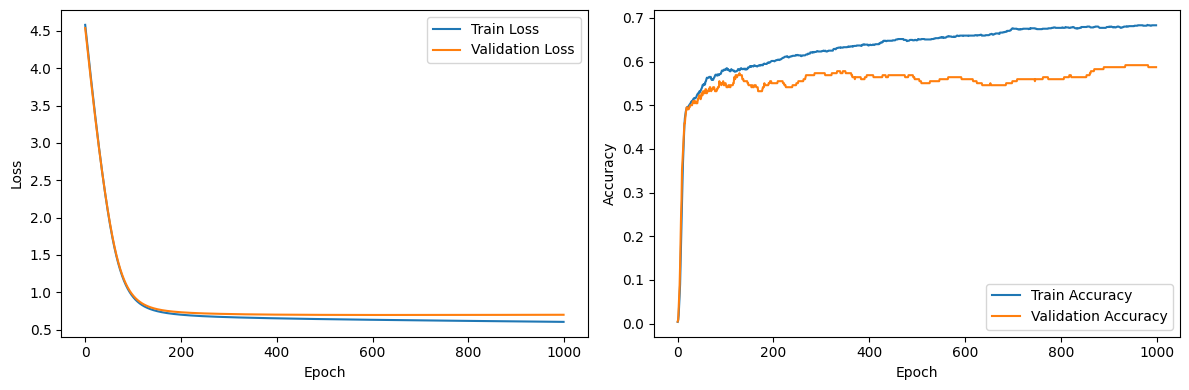


========== Run 10 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0643, Val Loss: 3.9391, Train Acc: 0.2635, Val Acc: 0.3308
Epoch: 020, Train Loss: 3.5140, Val Loss: 3.3745, Train Acc: 0.5068, Val Acc: 0.5789
Epoch: 030, Train Loss: 2.9837, Val Loss: 2.8554, Train Acc: 0.5238, Val Acc: 0.5789
Epoch: 040, Train Loss: 2.4845, Val Loss: 2.3791, Train Acc: 0.5294, Val Acc: 0.5752
Epoch: 050, Train Loss: 2.0361, Val Loss: 1.9557, Train Acc: 0.5351, Val Acc: 0.5902
Epoch: 060, Train Loss: 1.6604, Val Loss: 1.6031, Train Acc: 0.5488, Val Acc: 0.5827
Epoch: 070, Train Loss: 1.3682, Val Loss: 1.3302, Train Acc: 0.5520, Val Acc: 0.5789
Epoch: 080, Train Loss: 1.1564, Val Loss: 1.1332, Train Acc: 0.5729, Val Acc: 0.5865
Epoch: 090, Train Loss: 1.0109, Val Loss: 0.9991, Train Acc: 0.5721, Val Acc: 0.5827
Epoch: 100, Train Loss: 0.9140, Val Loss: 0.9113, Train Acc: 0.5697, Val Acc: 0.5714
Epoch: 110, Train Los

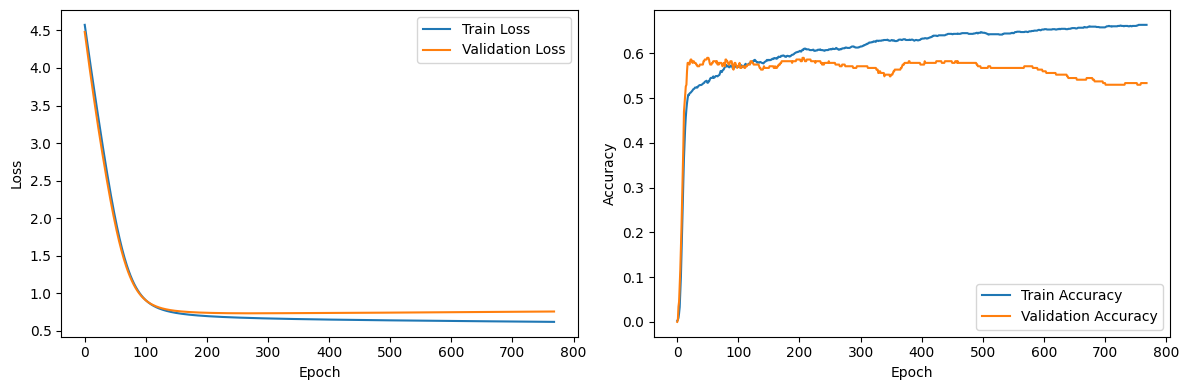


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0550, Val Loss: 4.0312, Train Acc: 0.2592, Val Acc: 0.3412
Epoch: 020, Train Loss: 3.5004, Val Loss: 3.4939, Train Acc: 0.4941, Val Acc: 0.4941
Epoch: 030, Train Loss: 2.9700, Val Loss: 2.9663, Train Acc: 0.5327, Val Acc: 0.5216
Epoch: 040, Train Loss: 2.4786, Val Loss: 2.4676, Train Acc: 0.5562, Val Acc: 0.5333
Epoch: 050, Train Loss: 2.0415, Val Loss: 2.0199, Train Acc: 0.5629, Val Acc: 0.5216
Epoch: 060, Train Loss: 1.6753, Val Loss: 1.6434, Train Acc: 0.5797, Val Acc: 0.5529
Epoch: 070, Train Loss: 1.3879, Val Loss: 1.3501, Train Acc: 0.6023, Val Acc: 0.5765
Epoch: 080, Train Loss: 1.1753, Val Loss: 1.1379, Train Acc: 0.6174, Val Acc: 0.5804
Epoch: 090, Train Loss: 1.0256, Val Loss: 0.9933, Train Acc: 0.6225, Val Acc: 0.5686
Epoch: 100, Train Loss: 0.9231, Val Loss: 0.8981, Train Acc: 0.6216, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.8538, Val Loss: 0.8362, Tr

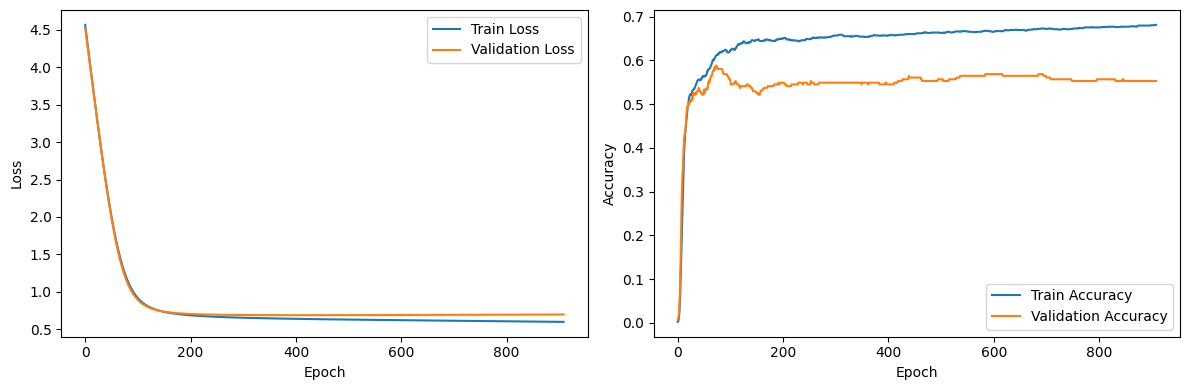


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2273, Val Loss: 4.1847, Train Acc: 0.1089, Val Acc: 0.1653
Epoch: 020, Train Loss: 3.6865, Val Loss: 3.6587, Train Acc: 0.4592, Val Acc: 0.4534
Epoch: 030, Train Loss: 3.1522, Val Loss: 3.1542, Train Acc: 0.5082, Val Acc: 0.4619
Epoch: 040, Train Loss: 2.6375, Val Loss: 2.6741, Train Acc: 0.5209, Val Acc: 0.4703
Epoch: 050, Train Loss: 2.1696, Val Loss: 2.2350, Train Acc: 0.5281, Val Acc: 0.4703
Epoch: 060, Train Loss: 1.7736, Val Loss: 1.8531, Train Acc: 0.5318, Val Acc: 0.4661
Epoch: 070, Train Loss: 1.4618, Val Loss: 1.5434, Train Acc: 0.5318, Val Acc: 0.4576
Epoch: 080, Train Loss: 1.2312, Val Loss: 1.3096, Train Acc: 0.5454, Val Acc: 0.4873
Epoch: 090, Train Loss: 1.0686, Val Loss: 1.1426, Train Acc: 0.5535, Val Acc: 0.4661
Epoch: 100, Train Loss: 0.9571, Val Loss: 1.0277, Train Acc: 0.5608, Val Acc: 0.4661
Epoch: 110, Train Loss: 0.8815, Val Loss: 0.9497, Tr

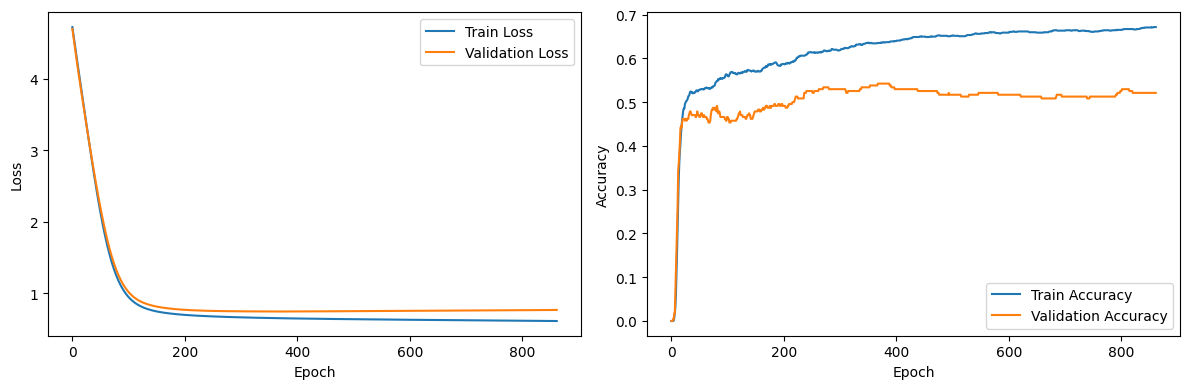


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0127, Val Loss: 3.9429, Train Acc: 0.2825, Val Acc: 0.3440
Epoch: 020, Train Loss: 3.4275, Val Loss: 3.3722, Train Acc: 0.5089, Val Acc: 0.5642
Epoch: 030, Train Loss: 2.8898, Val Loss: 2.8497, Train Acc: 0.5482, Val Acc: 0.5688
Epoch: 040, Train Loss: 2.4140, Val Loss: 2.3852, Train Acc: 0.5522, Val Acc: 0.5550
Epoch: 050, Train Loss: 2.0022, Val Loss: 1.9799, Train Acc: 0.5640, Val Acc: 0.5550
Epoch: 060, Train Loss: 1.6596, Val Loss: 1.6410, Train Acc: 0.5522, Val Acc: 0.5550
Epoch: 070, Train Loss: 1.3891, Val Loss: 1.3739, Train Acc: 0.5679, Val Acc: 0.5550
Epoch: 080, Train Loss: 1.1860, Val Loss: 1.1756, Train Acc: 0.5797, Val Acc: 0.5596
Epoch: 090, Train Loss: 1.0397, Val Loss: 1.0353, Train Acc: 0.5886, Val Acc: 0.5688
Epoch: 100, Train Loss: 0.9374, Val Loss: 0.9392, Train Acc: 0.5837, Val Acc: 0.5596
Epoch: 110, Train Loss: 0.8668, Val Loss: 0.8743, Tr

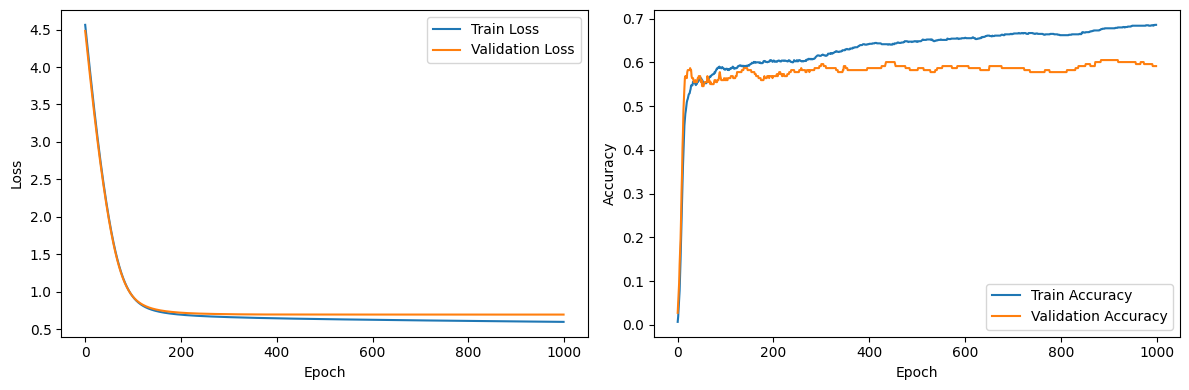


========== Run 11 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0872, Val Loss: 3.9926, Train Acc: 0.2530, Val Acc: 0.3271
Epoch: 020, Train Loss: 3.5537, Val Loss: 3.4375, Train Acc: 0.4617, Val Acc: 0.4812
Epoch: 030, Train Loss: 3.0429, Val Loss: 2.9324, Train Acc: 0.4786, Val Acc: 0.5000
Epoch: 040, Train Loss: 2.5632, Val Loss: 2.4693, Train Acc: 0.4843, Val Acc: 0.5150
Epoch: 050, Train Loss: 2.1272, Val Loss: 2.0530, Train Acc: 0.4956, Val Acc: 0.5150
Epoch: 060, Train Loss: 1.7523, Val Loss: 1.6991, Train Acc: 0.5028, Val Acc: 0.5113
Epoch: 070, Train Loss: 1.4496, Val Loss: 1.4170, Train Acc: 0.5189, Val Acc: 0.5038
Epoch: 080, Train Loss: 1.2201, Val Loss: 1.2054, Train Acc: 0.5479, Val Acc: 0.4962
Epoch: 090, Train Loss: 1.0557, Val Loss: 1.0552, Train Acc: 0.5624, Val Acc: 0.5451
Epoch: 100, Train Loss: 0.9426, Val Loss: 0.9527, Train Acc: 0.5624, Val Acc: 0.5714
Epoch: 110, Train Los

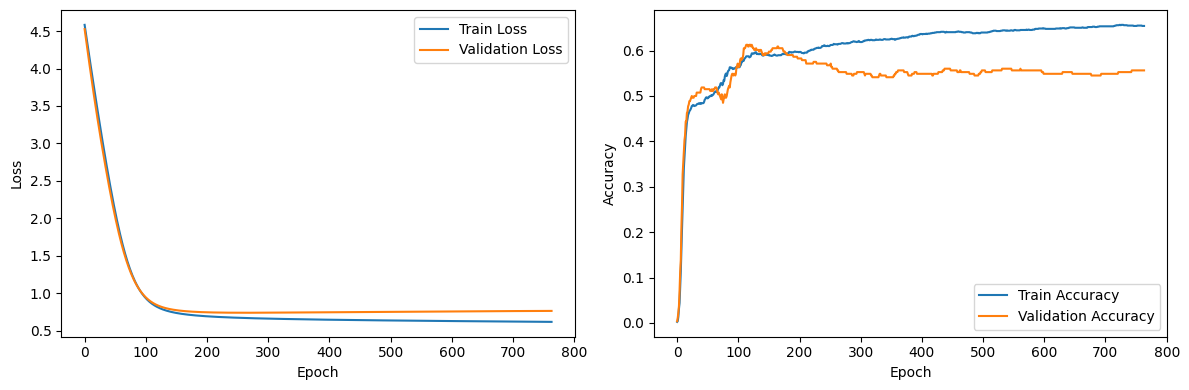


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1524, Val Loss: 4.1157, Train Acc: 0.1720, Val Acc: 0.2039
Epoch: 020, Train Loss: 3.5975, Val Loss: 3.5799, Train Acc: 0.4824, Val Acc: 0.4706
Epoch: 030, Train Loss: 3.0646, Val Loss: 3.0534, Train Acc: 0.5319, Val Acc: 0.5059
Epoch: 040, Train Loss: 2.5687, Val Loss: 2.5534, Train Acc: 0.5570, Val Acc: 0.5373
Epoch: 050, Train Loss: 2.1251, Val Loss: 2.1022, Train Acc: 0.5688, Val Acc: 0.5216
Epoch: 060, Train Loss: 1.7500, Val Loss: 1.7197, Train Acc: 0.5805, Val Acc: 0.5490
Epoch: 070, Train Loss: 1.4512, Val Loss: 1.4171, Train Acc: 0.5923, Val Acc: 0.5647
Epoch: 080, Train Loss: 1.2262, Val Loss: 1.1933, Train Acc: 0.6091, Val Acc: 0.5490
Epoch: 090, Train Loss: 1.0643, Val Loss: 1.0365, Train Acc: 0.6216, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.9520, Val Loss: 0.9307, Train Acc: 0.6208, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.8753, Val Loss: 0.8605, Tr

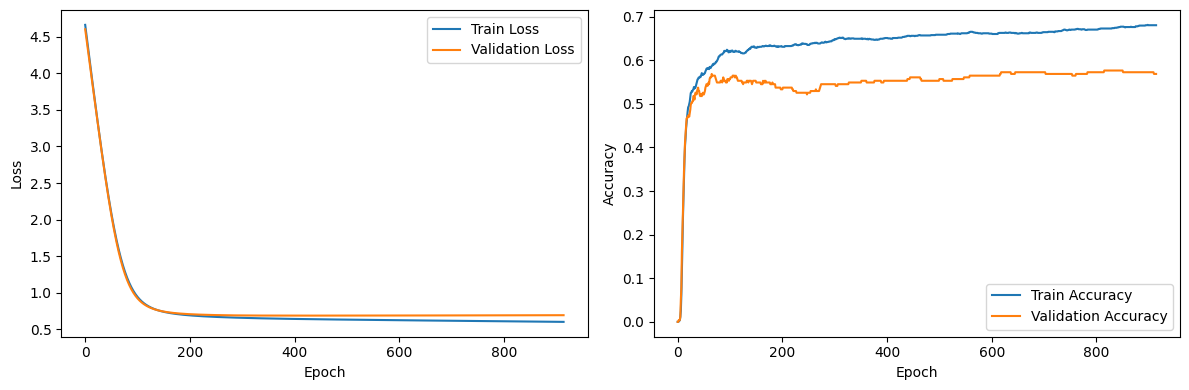


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1920, Val Loss: 4.2039, Train Acc: 0.2060, Val Acc: 0.3051
Epoch: 020, Train Loss: 3.6633, Val Loss: 3.6951, Train Acc: 0.5154, Val Acc: 0.5212
Epoch: 030, Train Loss: 3.1368, Val Loss: 3.2001, Train Acc: 0.5408, Val Acc: 0.5339
Epoch: 040, Train Loss: 2.6266, Val Loss: 2.7270, Train Acc: 0.5463, Val Acc: 0.5297
Epoch: 050, Train Loss: 2.1583, Val Loss: 2.2854, Train Acc: 0.5408, Val Acc: 0.5339
Epoch: 060, Train Loss: 1.7573, Val Loss: 1.8930, Train Acc: 0.5436, Val Acc: 0.5339
Epoch: 070, Train Loss: 1.4398, Val Loss: 1.5693, Train Acc: 0.5635, Val Acc: 0.5212
Epoch: 080, Train Loss: 1.2069, Val Loss: 1.3249, Train Acc: 0.5590, Val Acc: 0.5127
Epoch: 090, Train Loss: 1.0465, Val Loss: 1.1531, Train Acc: 0.5653, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.9399, Val Loss: 1.0380, Train Acc: 0.5626, Val Acc: 0.5297
Epoch: 110, Train Loss: 0.8696, Val Loss: 0.9613, Tr

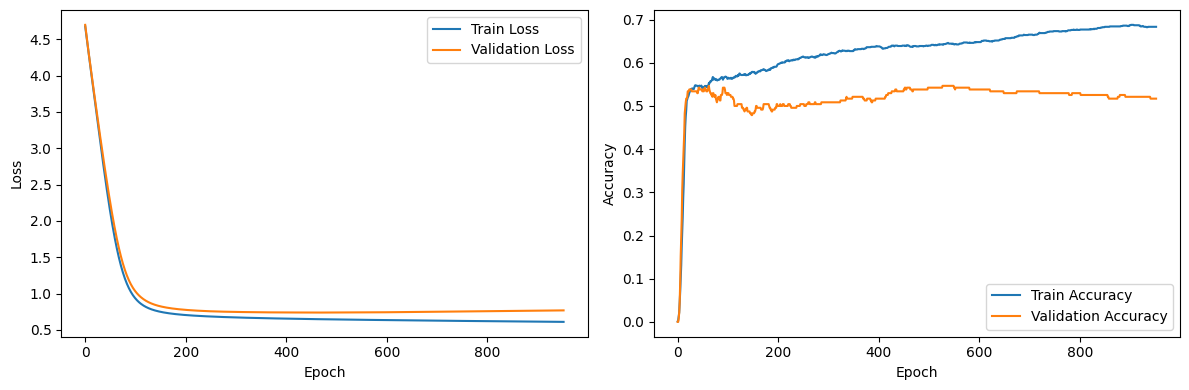


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0239, Val Loss: 3.9853, Train Acc: 0.2431, Val Acc: 0.2477
Epoch: 020, Train Loss: 3.4230, Val Loss: 3.3957, Train Acc: 0.5069, Val Acc: 0.4541
Epoch: 030, Train Loss: 2.8752, Val Loss: 2.8605, Train Acc: 0.5276, Val Acc: 0.4679
Epoch: 040, Train Loss: 2.3926, Val Loss: 2.3871, Train Acc: 0.5384, Val Acc: 0.4771
Epoch: 050, Train Loss: 1.9783, Val Loss: 1.9776, Train Acc: 0.5413, Val Acc: 0.4771
Epoch: 060, Train Loss: 1.6386, Val Loss: 1.6393, Train Acc: 0.5541, Val Acc: 0.4862
Epoch: 070, Train Loss: 1.3742, Val Loss: 1.3756, Train Acc: 0.5561, Val Acc: 0.5138
Epoch: 080, Train Loss: 1.1775, Val Loss: 1.1808, Train Acc: 0.5620, Val Acc: 0.5229
Epoch: 090, Train Loss: 1.0365, Val Loss: 1.0428, Train Acc: 0.5679, Val Acc: 0.5275
Epoch: 100, Train Loss: 0.9379, Val Loss: 0.9473, Train Acc: 0.5738, Val Acc: 0.5321
Epoch: 110, Train Loss: 0.8697, Val Loss: 0.8818, Tr

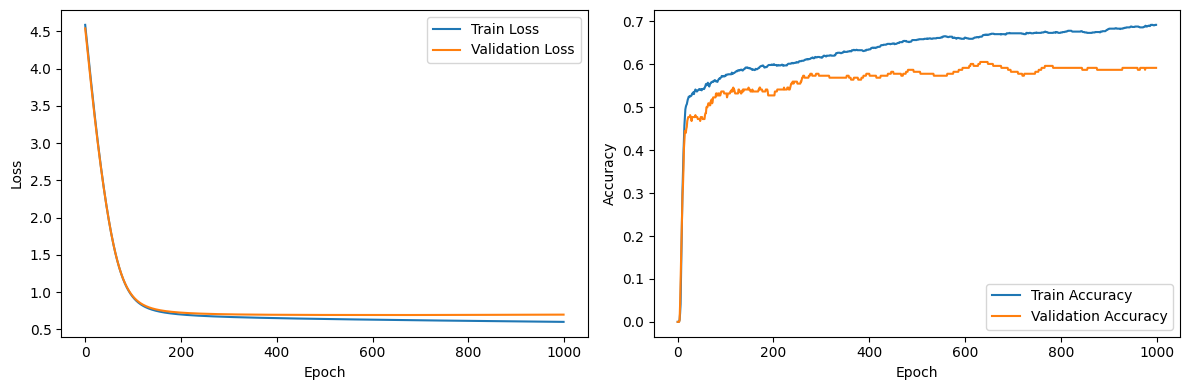


========== Run 12 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1349, Val Loss: 4.0791, Train Acc: 0.2151, Val Acc: 0.2368
Epoch: 020, Train Loss: 3.5635, Val Loss: 3.4862, Train Acc: 0.5052, Val Acc: 0.5000
Epoch: 030, Train Loss: 3.0273, Val Loss: 2.9566, Train Acc: 0.5431, Val Acc: 0.5376
Epoch: 040, Train Loss: 2.5362, Val Loss: 2.4809, Train Acc: 0.5520, Val Acc: 0.5414
Epoch: 050, Train Loss: 2.1019, Val Loss: 2.0627, Train Acc: 0.5536, Val Acc: 0.5639
Epoch: 060, Train Loss: 1.7377, Val Loss: 1.7140, Train Acc: 0.5608, Val Acc: 0.5714
Epoch: 070, Train Loss: 1.4494, Val Loss: 1.4398, Train Acc: 0.5697, Val Acc: 0.5752
Epoch: 080, Train Loss: 1.2322, Val Loss: 1.2345, Train Acc: 0.5721, Val Acc: 0.5865
Epoch: 090, Train Loss: 1.0752, Val Loss: 1.0871, Train Acc: 0.5753, Val Acc: 0.5827
Epoch: 100, Train Loss: 0.9649, Val Loss: 0.9843, Train Acc: 0.5770, Val Acc: 0.5752
Epoch: 110, Train Los

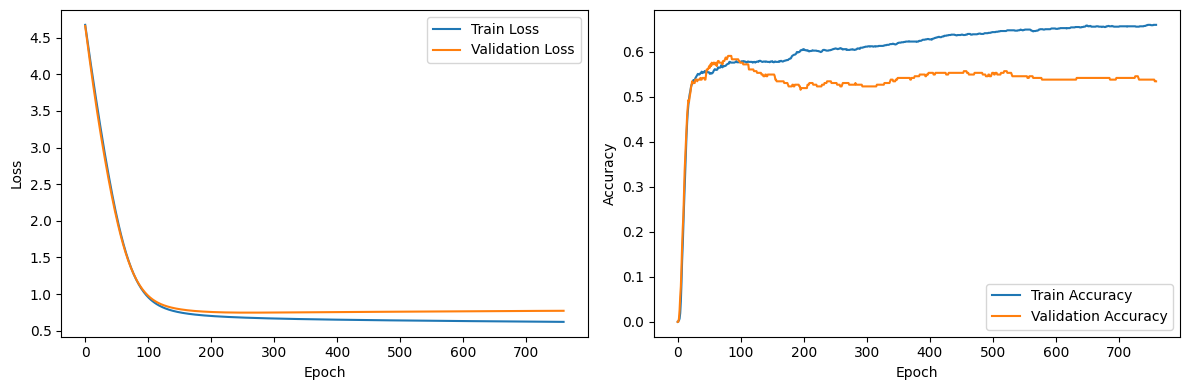


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0340, Val Loss: 3.9747, Train Acc: 0.3993, Val Acc: 0.3922
Epoch: 020, Train Loss: 3.4682, Val Loss: 3.4244, Train Acc: 0.4849, Val Acc: 0.4980
Epoch: 030, Train Loss: 2.9325, Val Loss: 2.8924, Train Acc: 0.5117, Val Acc: 0.5412
Epoch: 040, Train Loss: 2.4392, Val Loss: 2.3967, Train Acc: 0.5185, Val Acc: 0.5333
Epoch: 050, Train Loss: 2.0039, Val Loss: 1.9577, Train Acc: 0.5294, Val Acc: 0.5333
Epoch: 060, Train Loss: 1.6420, Val Loss: 1.5947, Train Acc: 0.5403, Val Acc: 0.5412
Epoch: 070, Train Loss: 1.3611, Val Loss: 1.3174, Train Acc: 0.5453, Val Acc: 0.5608
Epoch: 080, Train Loss: 1.1570, Val Loss: 1.1204, Train Acc: 0.5654, Val Acc: 0.5412
Epoch: 090, Train Loss: 1.0154, Val Loss: 0.9870, Train Acc: 0.5772, Val Acc: 0.5490
Epoch: 100, Train Loss: 0.9194, Val Loss: 0.8987, Train Acc: 0.5814, Val Acc: 0.5333
Epoch: 110, Train Loss: 0.8544, Val Loss: 0.8404, Tr

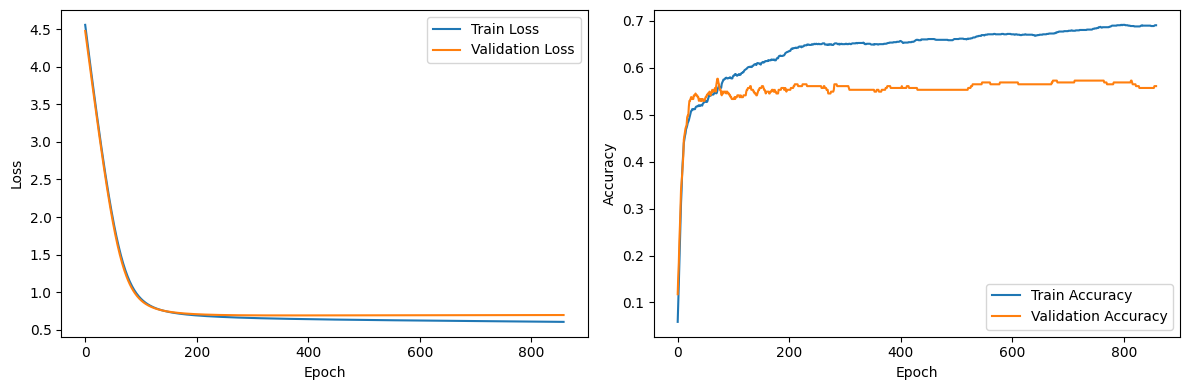


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.3595, Val Loss: 4.3712, Train Acc: 0.0717, Val Acc: 0.1102
Epoch: 020, Train Loss: 3.8279, Val Loss: 3.8418, Train Acc: 0.4964, Val Acc: 0.4576
Epoch: 030, Train Loss: 3.3198, Val Loss: 3.3652, Train Acc: 0.5436, Val Acc: 0.4873
Epoch: 040, Train Loss: 2.8332, Val Loss: 2.9160, Train Acc: 0.5508, Val Acc: 0.4958
Epoch: 050, Train Loss: 2.3795, Val Loss: 2.4936, Train Acc: 0.5608, Val Acc: 0.4831
Epoch: 060, Train Loss: 1.9765, Val Loss: 2.1065, Train Acc: 0.5681, Val Acc: 0.4619
Epoch: 070, Train Loss: 1.6390, Val Loss: 1.7701, Train Acc: 0.5717, Val Acc: 0.4619
Epoch: 080, Train Loss: 1.3729, Val Loss: 1.4968, Train Acc: 0.5726, Val Acc: 0.4364
Epoch: 090, Train Loss: 1.1745, Val Loss: 1.2889, Train Acc: 0.5799, Val Acc: 0.4746
Epoch: 100, Train Loss: 1.0327, Val Loss: 1.1388, Train Acc: 0.5808, Val Acc: 0.4788
Epoch: 110, Train Loss: 0.9338, Val Loss: 1.0337, Tr

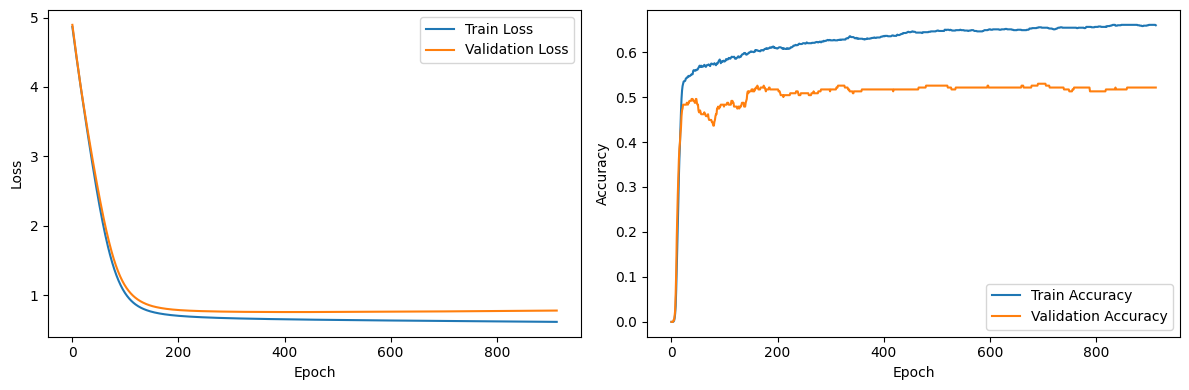


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1943, Val Loss: 4.1147, Train Acc: 0.1614, Val Acc: 0.2202
Epoch: 020, Train Loss: 3.5709, Val Loss: 3.5105, Train Acc: 0.5079, Val Acc: 0.5183
Epoch: 030, Train Loss: 3.0063, Val Loss: 2.9621, Train Acc: 0.5187, Val Acc: 0.5550
Epoch: 040, Train Loss: 2.5163, Val Loss: 2.4833, Train Acc: 0.5305, Val Acc: 0.5413
Epoch: 050, Train Loss: 2.0972, Val Loss: 2.0710, Train Acc: 0.5335, Val Acc: 0.5642
Epoch: 060, Train Loss: 1.7513, Val Loss: 1.7283, Train Acc: 0.5413, Val Acc: 0.5138
Epoch: 070, Train Loss: 1.4774, Val Loss: 1.4567, Train Acc: 0.5443, Val Acc: 0.5275
Epoch: 080, Train Loss: 1.2682, Val Loss: 1.2513, Train Acc: 0.5472, Val Acc: 0.5275
Epoch: 090, Train Loss: 1.1130, Val Loss: 1.1012, Train Acc: 0.5719, Val Acc: 0.5275
Epoch: 100, Train Loss: 1.0000, Val Loss: 0.9935, Train Acc: 0.5748, Val Acc: 0.5550
Epoch: 110, Train Loss: 0.9187, Val Loss: 0.9169, Tr

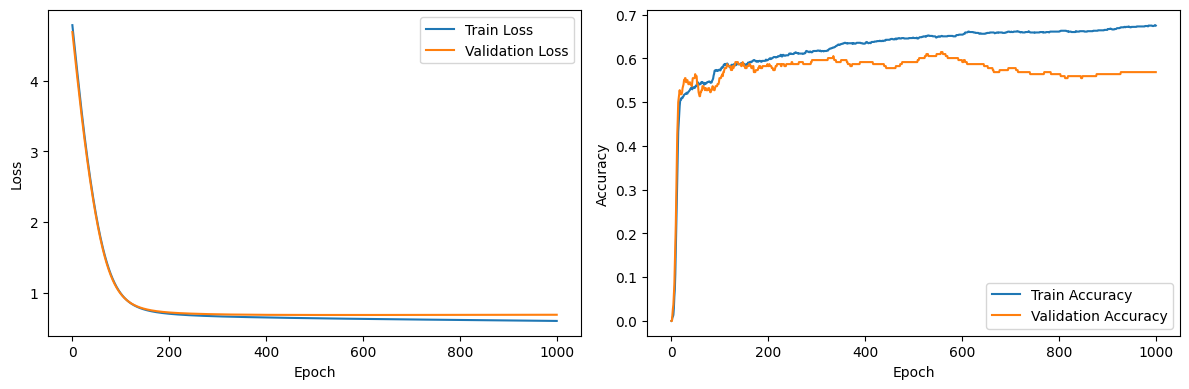


========== Run 13 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0208, Val Loss: 3.9323, Train Acc: 0.3006, Val Acc: 0.3684
Epoch: 020, Train Loss: 3.4813, Val Loss: 3.3732, Train Acc: 0.5407, Val Acc: 0.4812
Epoch: 030, Train Loss: 2.9600, Val Loss: 2.8600, Train Acc: 0.5649, Val Acc: 0.5188
Epoch: 040, Train Loss: 2.4708, Val Loss: 2.3900, Train Acc: 0.5681, Val Acc: 0.5338
Epoch: 050, Train Loss: 2.0347, Val Loss: 1.9752, Train Acc: 0.5705, Val Acc: 0.5376
Epoch: 060, Train Loss: 1.6720, Val Loss: 1.6327, Train Acc: 0.5802, Val Acc: 0.5789
Epoch: 070, Train Loss: 1.3897, Val Loss: 1.3683, Train Acc: 0.5850, Val Acc: 0.5865
Epoch: 080, Train Loss: 1.1814, Val Loss: 1.1752, Train Acc: 0.5898, Val Acc: 0.5752
Epoch: 090, Train Loss: 1.0337, Val Loss: 1.0398, Train Acc: 0.5882, Val Acc: 0.5752
Epoch: 100, Train Loss: 0.9317, Val Loss: 0.9475, Train Acc: 0.5858, Val Acc: 0.5865
Epoch: 110, Train Los

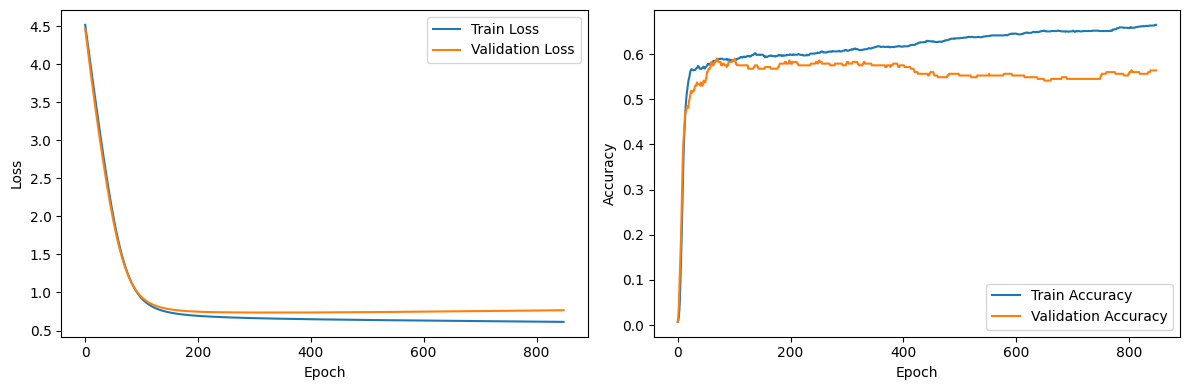


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1078, Val Loss: 4.0611, Train Acc: 0.3372, Val Acc: 0.3294
Epoch: 020, Train Loss: 3.5616, Val Loss: 3.5333, Train Acc: 0.4966, Val Acc: 0.5137
Epoch: 030, Train Loss: 3.0317, Val Loss: 3.0102, Train Acc: 0.5151, Val Acc: 0.5451
Epoch: 040, Train Loss: 2.5339, Val Loss: 2.5114, Train Acc: 0.5310, Val Acc: 0.5333
Epoch: 050, Train Loss: 2.0864, Val Loss: 2.0612, Train Acc: 0.5411, Val Acc: 0.5529
Epoch: 060, Train Loss: 1.7085, Val Loss: 1.6817, Train Acc: 0.5755, Val Acc: 0.5765
Epoch: 070, Train Loss: 1.4110, Val Loss: 1.3850, Train Acc: 0.5889, Val Acc: 0.5804
Epoch: 080, Train Loss: 1.1920, Val Loss: 1.1686, Train Acc: 0.6015, Val Acc: 0.5922
Epoch: 090, Train Loss: 1.0385, Val Loss: 1.0188, Train Acc: 0.6007, Val Acc: 0.5922
Epoch: 100, Train Loss: 0.9339, Val Loss: 0.9187, Train Acc: 0.5982, Val Acc: 0.5843
Epoch: 110, Train Loss: 0.8634, Val Loss: 0.8526, Tr

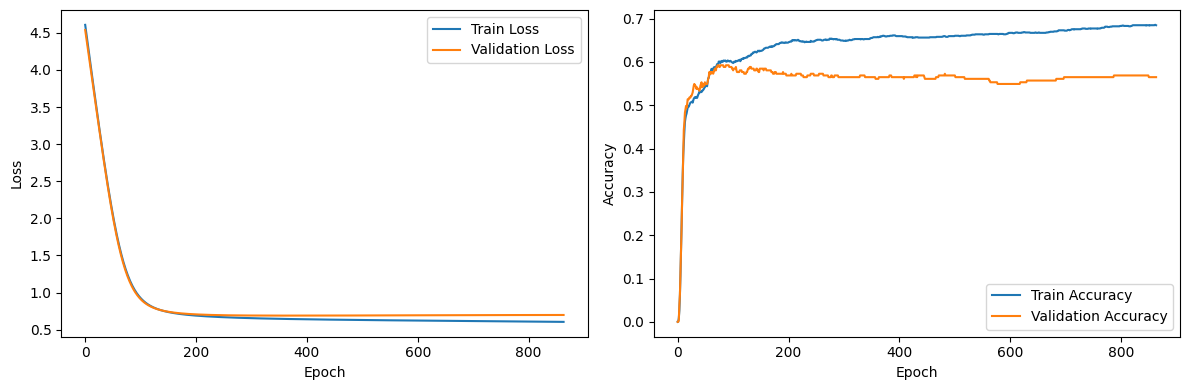


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1091, Val Loss: 4.0694, Train Acc: 0.2877, Val Acc: 0.3263
Epoch: 020, Train Loss: 3.5890, Val Loss: 3.5686, Train Acc: 0.5064, Val Acc: 0.4788
Epoch: 030, Train Loss: 3.0757, Val Loss: 3.0877, Train Acc: 0.5445, Val Acc: 0.5042
Epoch: 040, Train Loss: 2.5807, Val Loss: 2.6328, Train Acc: 0.5599, Val Acc: 0.5000
Epoch: 050, Train Loss: 2.1278, Val Loss: 2.2137, Train Acc: 0.5617, Val Acc: 0.5085
Epoch: 060, Train Loss: 1.7420, Val Loss: 1.8471, Train Acc: 0.5653, Val Acc: 0.5085
Epoch: 070, Train Loss: 1.4372, Val Loss: 1.5489, Train Acc: 0.5835, Val Acc: 0.5042
Epoch: 080, Train Loss: 1.2118, Val Loss: 1.3239, Train Acc: 0.5835, Val Acc: 0.4873
Epoch: 090, Train Loss: 1.0538, Val Loss: 1.1632, Train Acc: 0.5780, Val Acc: 0.4534
Epoch: 100, Train Loss: 0.9464, Val Loss: 1.0512, Train Acc: 0.5771, Val Acc: 0.4449
Epoch: 110, Train Loss: 0.8738, Val Loss: 0.9727, Tr

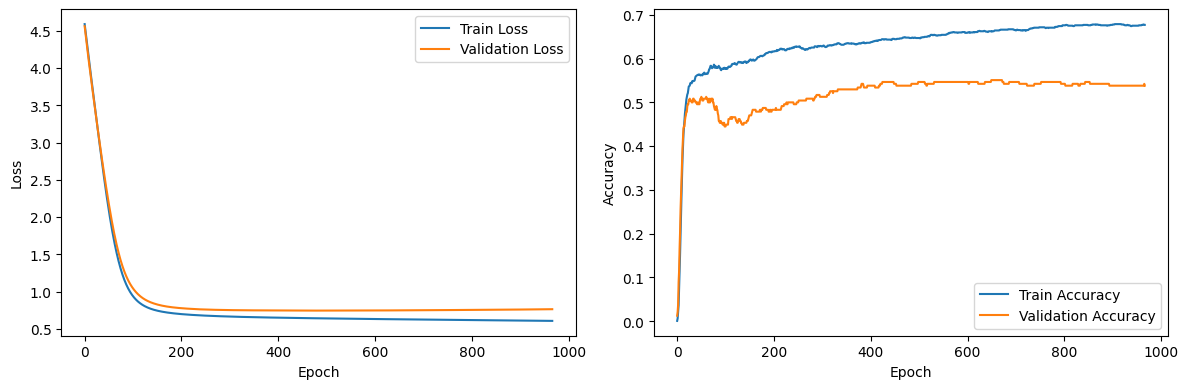


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0924, Val Loss: 3.9881, Train Acc: 0.2244, Val Acc: 0.2706
Epoch: 020, Train Loss: 3.4949, Val Loss: 3.4060, Train Acc: 0.4931, Val Acc: 0.4771
Epoch: 030, Train Loss: 2.9417, Val Loss: 2.8766, Train Acc: 0.5325, Val Acc: 0.5183
Epoch: 040, Train Loss: 2.4557, Val Loss: 2.4119, Train Acc: 0.5404, Val Acc: 0.5275
Epoch: 050, Train Loss: 2.0433, Val Loss: 2.0120, Train Acc: 0.5423, Val Acc: 0.5367
Epoch: 060, Train Loss: 1.7044, Val Loss: 1.6794, Train Acc: 0.5433, Val Acc: 0.5367
Epoch: 070, Train Loss: 1.4364, Val Loss: 1.4158, Train Acc: 0.5443, Val Acc: 0.5367
Epoch: 080, Train Loss: 1.2327, Val Loss: 1.2169, Train Acc: 0.5492, Val Acc: 0.5367
Epoch: 090, Train Loss: 1.0825, Val Loss: 1.0726, Train Acc: 0.5610, Val Acc: 0.5413
Epoch: 100, Train Loss: 0.9747, Val Loss: 0.9710, Train Acc: 0.5640, Val Acc: 0.5413
Epoch: 110, Train Loss: 0.8983, Val Loss: 0.9008, Tr

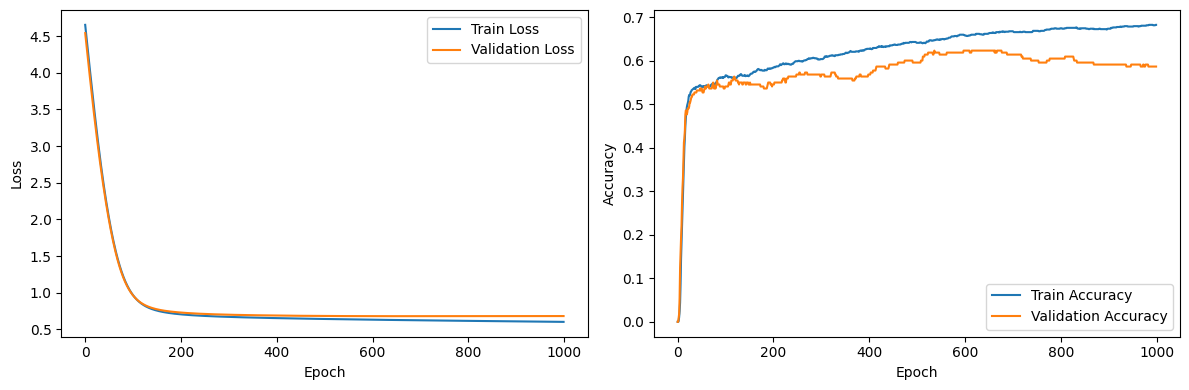


========== Run 14 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0805, Val Loss: 3.9819, Train Acc: 0.2748, Val Acc: 0.3308
Epoch: 020, Train Loss: 3.5192, Val Loss: 3.4027, Train Acc: 0.5052, Val Acc: 0.5564
Epoch: 030, Train Loss: 2.9872, Val Loss: 2.8765, Train Acc: 0.5318, Val Acc: 0.5789
Epoch: 040, Train Loss: 2.4941, Val Loss: 2.4008, Train Acc: 0.5407, Val Acc: 0.5639
Epoch: 050, Train Loss: 2.0540, Val Loss: 1.9808, Train Acc: 0.5447, Val Acc: 0.5639
Epoch: 060, Train Loss: 1.6849, Val Loss: 1.6306, Train Acc: 0.5512, Val Acc: 0.5489
Epoch: 070, Train Loss: 1.3954, Val Loss: 1.3576, Train Acc: 0.5649, Val Acc: 0.5451
Epoch: 080, Train Loss: 1.1817, Val Loss: 1.1576, Train Acc: 0.5721, Val Acc: 0.5639
Epoch: 090, Train Loss: 1.0314, Val Loss: 1.0189, Train Acc: 0.5721, Val Acc: 0.5564
Epoch: 100, Train Loss: 0.9292, Val Loss: 0.9262, Train Acc: 0.5753, Val Acc: 0.5564
Epoch: 110, Train Los

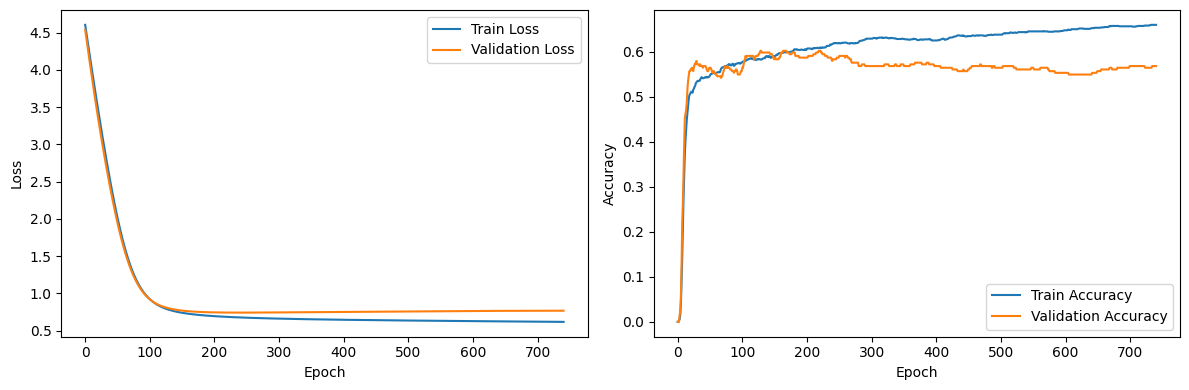


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0171, Val Loss: 3.9895, Train Acc: 0.2911, Val Acc: 0.2941
Epoch: 020, Train Loss: 3.4665, Val Loss: 3.4545, Train Acc: 0.5042, Val Acc: 0.5020
Epoch: 030, Train Loss: 2.9441, Val Loss: 2.9363, Train Acc: 0.5227, Val Acc: 0.5059
Epoch: 040, Train Loss: 2.4636, Val Loss: 2.4536, Train Acc: 0.5252, Val Acc: 0.5294
Epoch: 050, Train Loss: 2.0385, Val Loss: 2.0234, Train Acc: 0.5386, Val Acc: 0.5333
Epoch: 060, Train Loss: 1.6823, Val Loss: 1.6613, Train Acc: 0.5604, Val Acc: 0.5529
Epoch: 070, Train Loss: 1.4011, Val Loss: 1.3764, Train Acc: 0.5730, Val Acc: 0.5647
Epoch: 080, Train Loss: 1.1908, Val Loss: 1.1666, Train Acc: 0.5847, Val Acc: 0.5608
Epoch: 090, Train Loss: 1.0400, Val Loss: 1.0203, Train Acc: 0.5931, Val Acc: 0.5686
Epoch: 100, Train Loss: 0.9346, Val Loss: 0.9215, Train Acc: 0.6099, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.8621, Val Loss: 0.8559, Tr

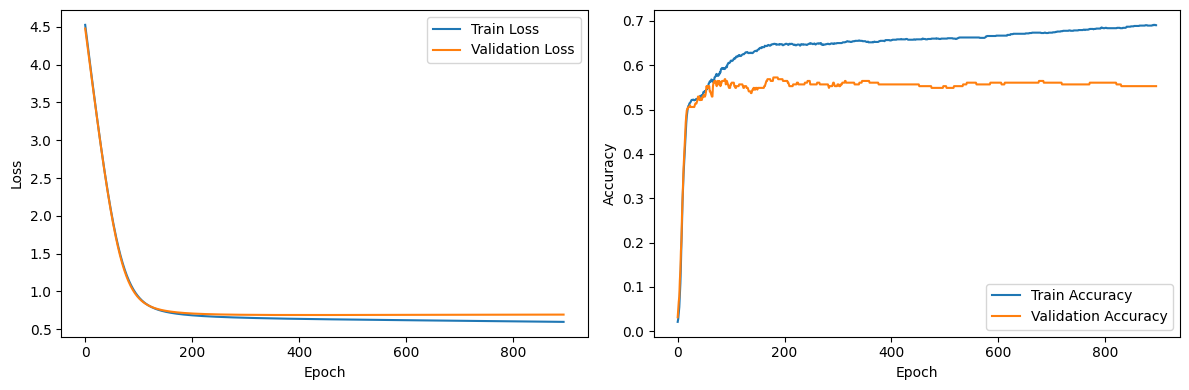


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2533, Val Loss: 4.1804, Train Acc: 0.1044, Val Acc: 0.1695
Epoch: 020, Train Loss: 3.7438, Val Loss: 3.6729, Train Acc: 0.4791, Val Acc: 0.4915
Epoch: 030, Train Loss: 3.2346, Val Loss: 3.1905, Train Acc: 0.5045, Val Acc: 0.4831
Epoch: 040, Train Loss: 2.7329, Val Loss: 2.7351, Train Acc: 0.5181, Val Acc: 0.4958
Epoch: 050, Train Loss: 2.2608, Val Loss: 2.3036, Train Acc: 0.5236, Val Acc: 0.5042
Epoch: 060, Train Loss: 1.8468, Val Loss: 1.9161, Train Acc: 0.5254, Val Acc: 0.4958
Epoch: 070, Train Loss: 1.5115, Val Loss: 1.5936, Train Acc: 0.5272, Val Acc: 0.4873
Epoch: 080, Train Loss: 1.2599, Val Loss: 1.3462, Train Acc: 0.5345, Val Acc: 0.4661
Epoch: 090, Train Loss: 1.0828, Val Loss: 1.1693, Train Acc: 0.5481, Val Acc: 0.4703
Epoch: 100, Train Loss: 0.9636, Val Loss: 1.0484, Train Acc: 0.5544, Val Acc: 0.4703
Epoch: 110, Train Loss: 0.8848, Val Loss: 0.9670, Tr

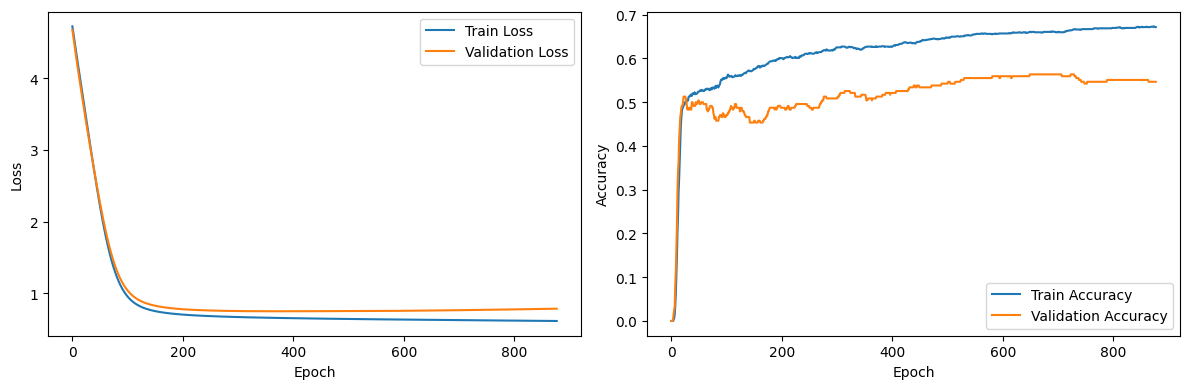


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0778, Val Loss: 4.0260, Train Acc: 0.2087, Val Acc: 0.2385
Epoch: 020, Train Loss: 3.4741, Val Loss: 3.4370, Train Acc: 0.4754, Val Acc: 0.4495
Epoch: 030, Train Loss: 2.9275, Val Loss: 2.9029, Train Acc: 0.5108, Val Acc: 0.4679
Epoch: 040, Train Loss: 2.4425, Val Loss: 2.4275, Train Acc: 0.5148, Val Acc: 0.4817
Epoch: 050, Train Loss: 2.0219, Val Loss: 2.0131, Train Acc: 0.5217, Val Acc: 0.4908
Epoch: 060, Train Loss: 1.6750, Val Loss: 1.6686, Train Acc: 0.5246, Val Acc: 0.5000
Epoch: 070, Train Loss: 1.4044, Val Loss: 1.3990, Train Acc: 0.5266, Val Acc: 0.5046
Epoch: 080, Train Loss: 1.2030, Val Loss: 1.1994, Train Acc: 0.5266, Val Acc: 0.5183
Epoch: 090, Train Loss: 1.0581, Val Loss: 1.0577, Train Acc: 0.5433, Val Acc: 0.5183
Epoch: 100, Train Loss: 0.9561, Val Loss: 0.9597, Train Acc: 0.5463, Val Acc: 0.5550
Epoch: 110, Train Loss: 0.8852, Val Loss: 0.8925, Tr

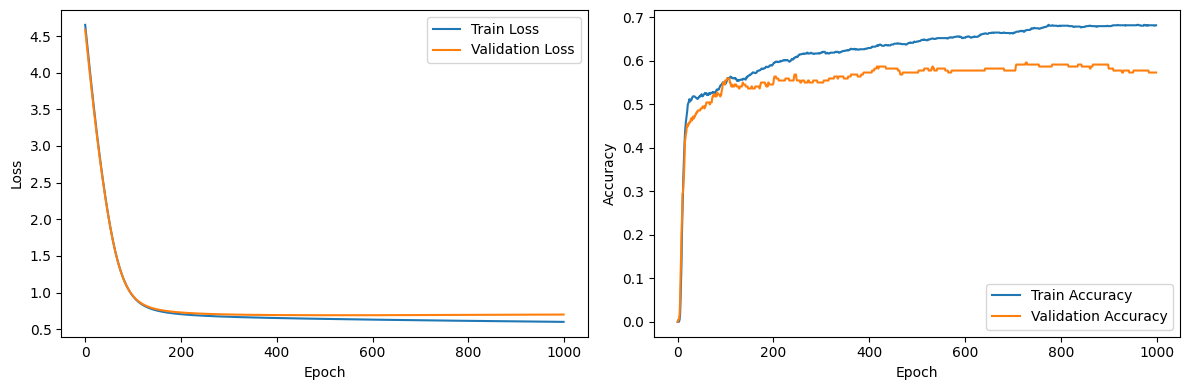


========== Run 15 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9777, Val Loss: 3.8926, Train Acc: 0.3537, Val Acc: 0.3684
Epoch: 020, Train Loss: 3.4355, Val Loss: 3.3428, Train Acc: 0.4819, Val Acc: 0.4887
Epoch: 030, Train Loss: 2.9160, Val Loss: 2.8382, Train Acc: 0.5109, Val Acc: 0.5038
Epoch: 040, Train Loss: 2.4287, Val Loss: 2.3666, Train Acc: 0.5189, Val Acc: 0.4925
Epoch: 050, Train Loss: 1.9929, Val Loss: 1.9408, Train Acc: 0.5455, Val Acc: 0.5188
Epoch: 060, Train Loss: 1.6283, Val Loss: 1.5838, Train Acc: 0.5657, Val Acc: 0.5301
Epoch: 070, Train Loss: 1.3453, Val Loss: 1.3092, Train Acc: 0.5657, Val Acc: 0.5451
Epoch: 080, Train Loss: 1.1409, Val Loss: 1.1147, Train Acc: 0.5786, Val Acc: 0.5714
Epoch: 090, Train Loss: 1.0013, Val Loss: 0.9854, Train Acc: 0.5810, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.9085, Val Loss: 0.9027, Train Acc: 0.5818, Val Acc: 0.5902
Epoch: 110, Train Los

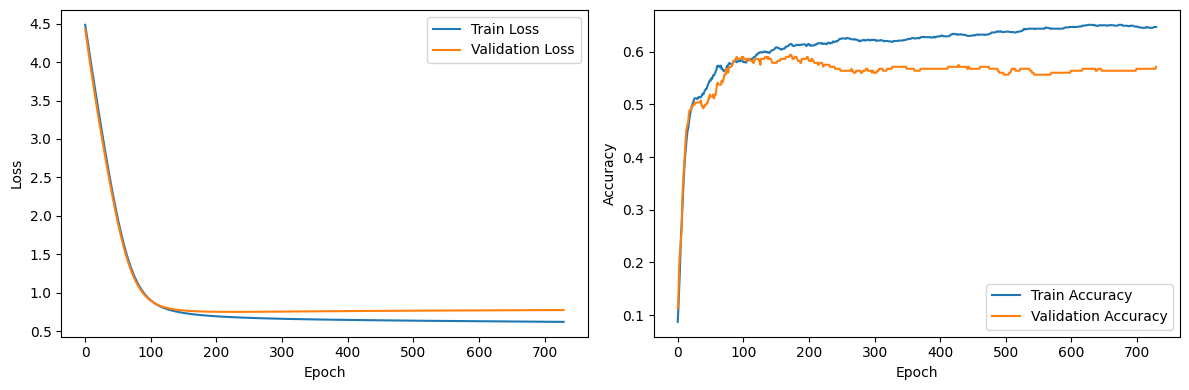


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.8406, Val Loss: 3.8152, Train Acc: 0.4304, Val Acc: 0.4745
Epoch: 020, Train Loss: 3.2999, Val Loss: 3.2871, Train Acc: 0.5805, Val Acc: 0.5686
Epoch: 030, Train Loss: 2.7933, Val Loss: 2.7810, Train Acc: 0.5914, Val Acc: 0.5647
Epoch: 040, Train Loss: 2.3312, Val Loss: 2.3138, Train Acc: 0.5898, Val Acc: 0.5647
Epoch: 050, Train Loss: 1.9272, Val Loss: 1.9035, Train Acc: 0.5931, Val Acc: 0.5647
Epoch: 060, Train Loss: 1.5937, Val Loss: 1.5647, Train Acc: 0.6032, Val Acc: 0.5490
Epoch: 070, Train Loss: 1.3338, Val Loss: 1.3033, Train Acc: 0.6133, Val Acc: 0.5686
Epoch: 080, Train Loss: 1.1414, Val Loss: 1.1138, Train Acc: 0.6250, Val Acc: 0.5686
Epoch: 090, Train Loss: 1.0045, Val Loss: 0.9829, Train Acc: 0.6191, Val Acc: 0.5647
Epoch: 100, Train Loss: 0.9097, Val Loss: 0.8950, Train Acc: 0.6225, Val Acc: 0.5608
Epoch: 110, Train Loss: 0.8448, Val Loss: 0.8365, Tr

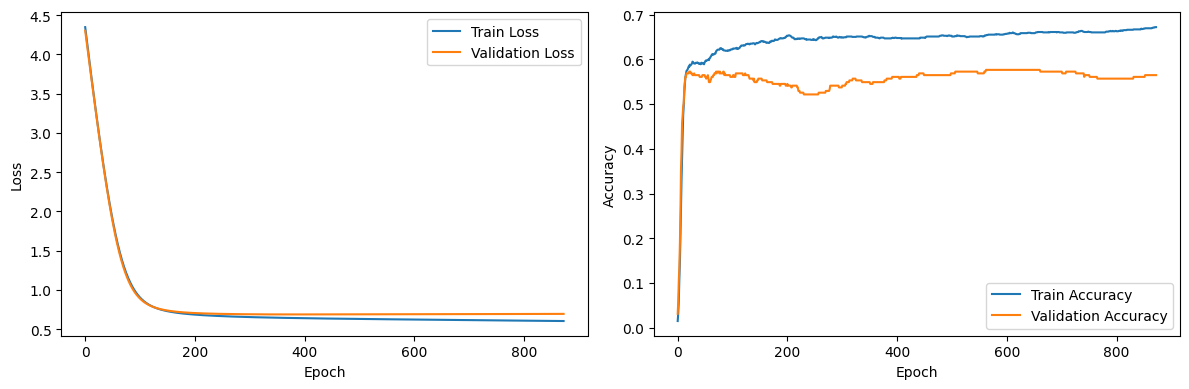


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0381, Val Loss: 3.9866, Train Acc: 0.3421, Val Acc: 0.4195
Epoch: 020, Train Loss: 3.5082, Val Loss: 3.4803, Train Acc: 0.5118, Val Acc: 0.5297
Epoch: 030, Train Loss: 2.9860, Val Loss: 2.9957, Train Acc: 0.5218, Val Acc: 0.5212
Epoch: 040, Train Loss: 2.4900, Val Loss: 2.5378, Train Acc: 0.5318, Val Acc: 0.5169
Epoch: 050, Train Loss: 2.0437, Val Loss: 2.1177, Train Acc: 0.5363, Val Acc: 0.5339
Epoch: 060, Train Loss: 1.6685, Val Loss: 1.7532, Train Acc: 0.5336, Val Acc: 0.5424
Epoch: 070, Train Loss: 1.3748, Val Loss: 1.4620, Train Acc: 0.5327, Val Acc: 0.5169
Epoch: 080, Train Loss: 1.1609, Val Loss: 1.2471, Train Acc: 0.5445, Val Acc: 0.4873
Epoch: 090, Train Loss: 1.0140, Val Loss: 1.0967, Train Acc: 0.5563, Val Acc: 0.4915
Epoch: 100, Train Loss: 0.9162, Val Loss: 0.9946, Train Acc: 0.5626, Val Acc: 0.5042
Epoch: 110, Train Loss: 0.8515, Val Loss: 0.9271, Tr

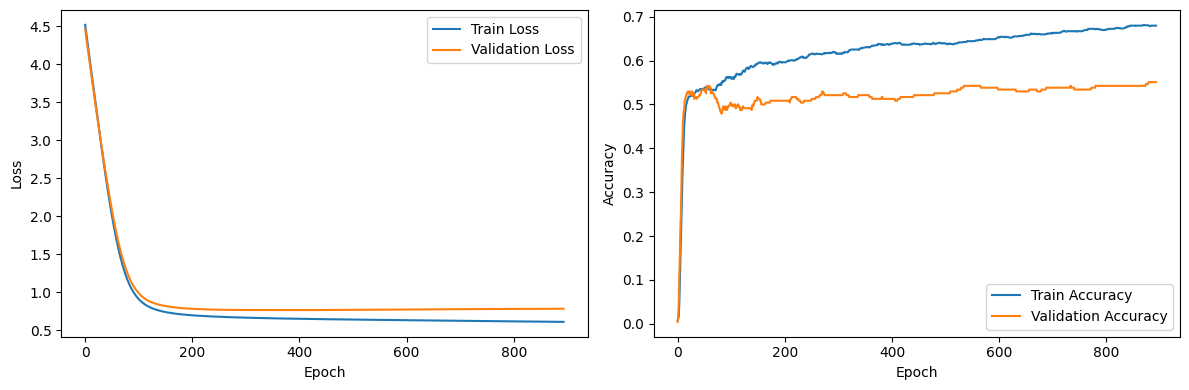


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0662, Val Loss: 4.0514, Train Acc: 0.2510, Val Acc: 0.3028
Epoch: 020, Train Loss: 3.4702, Val Loss: 3.4619, Train Acc: 0.5010, Val Acc: 0.4725
Epoch: 030, Train Loss: 2.9326, Val Loss: 2.9276, Train Acc: 0.5069, Val Acc: 0.4725
Epoch: 040, Train Loss: 2.4532, Val Loss: 2.4559, Train Acc: 0.5128, Val Acc: 0.4862
Epoch: 050, Train Loss: 2.0372, Val Loss: 2.0463, Train Acc: 0.5394, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.6933, Val Loss: 1.7047, Train Acc: 0.5463, Val Acc: 0.4908
Epoch: 070, Train Loss: 1.4234, Val Loss: 1.4354, Train Acc: 0.5492, Val Acc: 0.5000
Epoch: 080, Train Loss: 1.2209, Val Loss: 1.2341, Train Acc: 0.5650, Val Acc: 0.5000
Epoch: 090, Train Loss: 1.0741, Val Loss: 1.0894, Train Acc: 0.5679, Val Acc: 0.5092
Epoch: 100, Train Loss: 0.9696, Val Loss: 0.9873, Train Acc: 0.5719, Val Acc: 0.5046
Epoch: 110, Train Loss: 0.8959, Val Loss: 0.9157, Tr

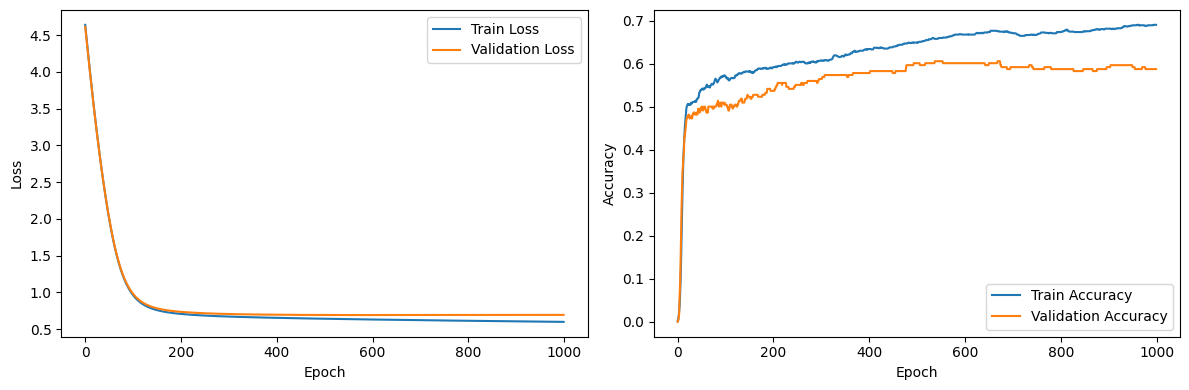


========== Run 16 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1293, Val Loss: 4.0956, Train Acc: 0.0661, Val Acc: 0.0714
Epoch: 020, Train Loss: 3.5834, Val Loss: 3.5144, Train Acc: 0.5149, Val Acc: 0.4812
Epoch: 030, Train Loss: 3.0688, Val Loss: 3.0004, Train Acc: 0.5544, Val Acc: 0.5263
Epoch: 040, Train Loss: 2.5913, Val Loss: 2.5383, Train Acc: 0.5657, Val Acc: 0.5677
Epoch: 050, Train Loss: 2.1600, Val Loss: 2.1205, Train Acc: 0.5786, Val Acc: 0.5714
Epoch: 060, Train Loss: 1.7892, Val Loss: 1.7600, Train Acc: 0.5826, Val Acc: 0.5639
Epoch: 070, Train Loss: 1.4885, Val Loss: 1.4675, Train Acc: 0.5810, Val Acc: 0.5564
Epoch: 080, Train Loss: 1.2582, Val Loss: 1.2448, Train Acc: 0.5842, Val Acc: 0.5376
Epoch: 090, Train Loss: 1.0905, Val Loss: 1.0845, Train Acc: 0.5882, Val Acc: 0.5489
Epoch: 100, Train Loss: 0.9729, Val Loss: 0.9739, Train Acc: 0.5947, Val Acc: 0.5526
Epoch: 110, Train Los

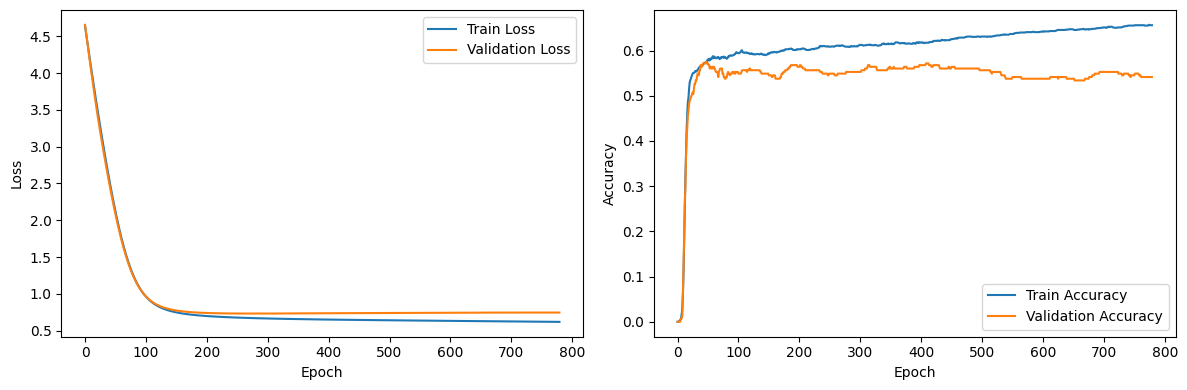


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0045, Val Loss: 3.9721, Train Acc: 0.3196, Val Acc: 0.3255
Epoch: 020, Train Loss: 3.4348, Val Loss: 3.4197, Train Acc: 0.5017, Val Acc: 0.4588
Epoch: 030, Train Loss: 2.9053, Val Loss: 2.8949, Train Acc: 0.5218, Val Acc: 0.4980
Epoch: 040, Train Loss: 2.4280, Val Loss: 2.4155, Train Acc: 0.5411, Val Acc: 0.5216
Epoch: 050, Train Loss: 2.0127, Val Loss: 1.9966, Train Acc: 0.5537, Val Acc: 0.5137
Epoch: 060, Train Loss: 1.6682, Val Loss: 1.6489, Train Acc: 0.5789, Val Acc: 0.5137
Epoch: 070, Train Loss: 1.3968, Val Loss: 1.3771, Train Acc: 0.5973, Val Acc: 0.5529
Epoch: 080, Train Loss: 1.1936, Val Loss: 1.1763, Train Acc: 0.5990, Val Acc: 0.5686
Epoch: 090, Train Loss: 1.0468, Val Loss: 1.0338, Train Acc: 0.6057, Val Acc: 0.5569
Epoch: 100, Train Loss: 0.9436, Val Loss: 0.9356, Train Acc: 0.6107, Val Acc: 0.5608
Epoch: 110, Train Loss: 0.8719, Val Loss: 0.8689, Tr

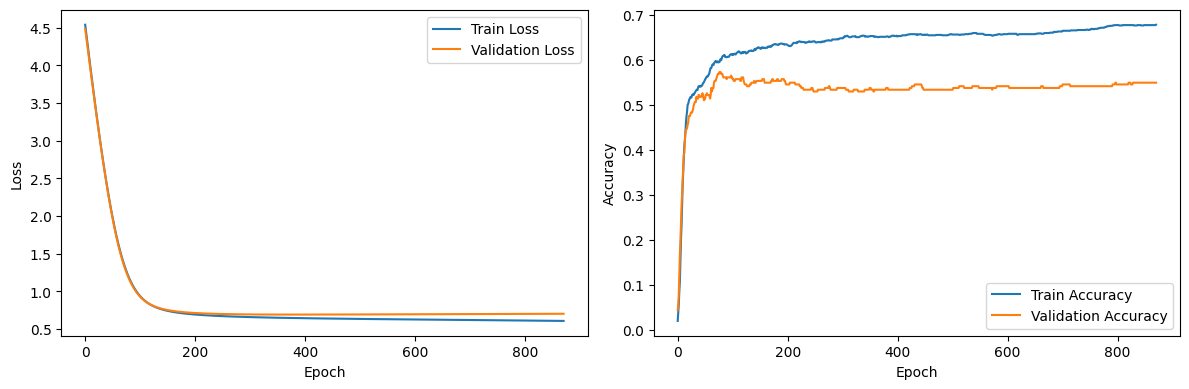


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.3392, Val Loss: 4.2762, Train Acc: 0.0889, Val Acc: 0.1525
Epoch: 020, Train Loss: 3.8087, Val Loss: 3.7525, Train Acc: 0.4664, Val Acc: 0.4746
Epoch: 030, Train Loss: 3.2745, Val Loss: 3.2511, Train Acc: 0.5318, Val Acc: 0.4958
Epoch: 040, Train Loss: 2.7435, Val Loss: 2.7649, Train Acc: 0.5372, Val Acc: 0.5085
Epoch: 050, Train Loss: 2.2461, Val Loss: 2.3113, Train Acc: 0.5490, Val Acc: 0.5085
Epoch: 060, Train Loss: 1.8174, Val Loss: 1.9122, Train Acc: 0.5590, Val Acc: 0.5297
Epoch: 070, Train Loss: 1.4803, Val Loss: 1.5878, Train Acc: 0.5653, Val Acc: 0.5000
Epoch: 080, Train Loss: 1.2353, Val Loss: 1.3452, Train Acc: 0.5599, Val Acc: 0.5000
Epoch: 090, Train Loss: 1.0670, Val Loss: 1.1734, Train Acc: 0.5572, Val Acc: 0.4831
Epoch: 100, Train Loss: 0.9547, Val Loss: 1.0553, Train Acc: 0.5699, Val Acc: 0.4661
Epoch: 110, Train Loss: 0.8803, Val Loss: 0.9744, Tr

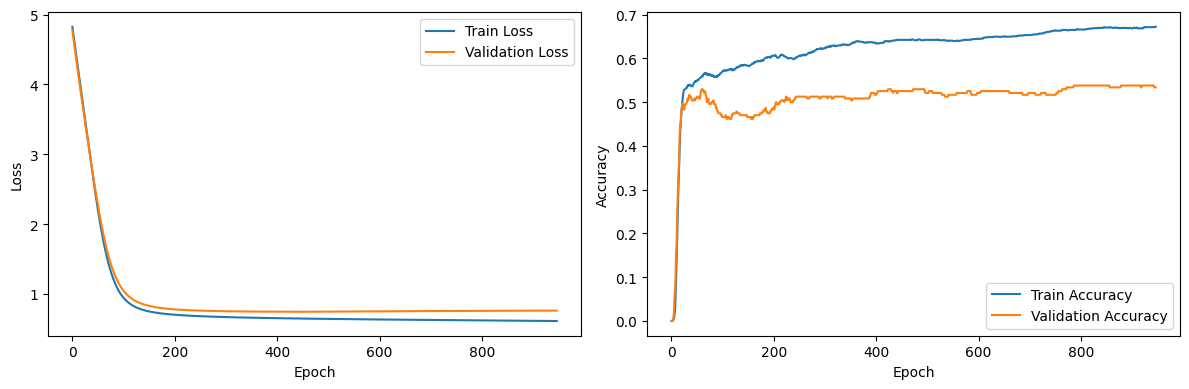


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6791, Val Loss: 3.6524, Train Acc: 0.4596, Val Acc: 0.4541
Epoch: 020, Train Loss: 3.1106, Val Loss: 3.1030, Train Acc: 0.5207, Val Acc: 0.5183
Epoch: 030, Train Loss: 2.6134, Val Loss: 2.6205, Train Acc: 0.5246, Val Acc: 0.5183
Epoch: 040, Train Loss: 2.1813, Val Loss: 2.1974, Train Acc: 0.5364, Val Acc: 0.5275
Epoch: 050, Train Loss: 1.8152, Val Loss: 1.8337, Train Acc: 0.5453, Val Acc: 0.5413
Epoch: 060, Train Loss: 1.5177, Val Loss: 1.5349, Train Acc: 0.5522, Val Acc: 0.5459
Epoch: 070, Train Loss: 1.2868, Val Loss: 1.3023, Train Acc: 0.5669, Val Acc: 0.5275
Epoch: 080, Train Loss: 1.1150, Val Loss: 1.1301, Train Acc: 0.5630, Val Acc: 0.5367
Epoch: 090, Train Loss: 0.9915, Val Loss: 1.0073, Train Acc: 0.5768, Val Acc: 0.5367
Epoch: 100, Train Loss: 0.9047, Val Loss: 0.9215, Train Acc: 0.5837, Val Acc: 0.5321
Epoch: 110, Train Loss: 0.8444, Val Loss: 0.8622, Tr

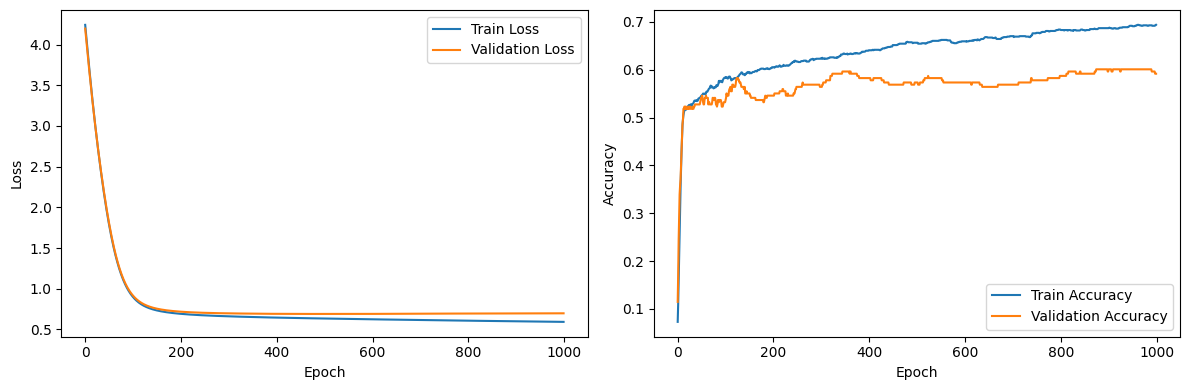


========== Run 17 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0857, Val Loss: 4.0038, Train Acc: 0.2466, Val Acc: 0.3045
Epoch: 020, Train Loss: 3.5364, Val Loss: 3.4275, Train Acc: 0.4448, Val Acc: 0.4436
Epoch: 030, Train Loss: 3.0107, Val Loss: 2.9045, Train Acc: 0.4690, Val Acc: 0.4774
Epoch: 040, Train Loss: 2.5192, Val Loss: 2.4313, Train Acc: 0.4883, Val Acc: 0.5075
Epoch: 050, Train Loss: 2.0779, Val Loss: 2.0124, Train Acc: 0.5109, Val Acc: 0.5263
Epoch: 060, Train Loss: 1.7051, Val Loss: 1.6615, Train Acc: 0.5278, Val Acc: 0.5376
Epoch: 070, Train Loss: 1.4106, Val Loss: 1.3866, Train Acc: 0.5447, Val Acc: 0.5376
Epoch: 080, Train Loss: 1.1923, Val Loss: 1.1836, Train Acc: 0.5584, Val Acc: 0.5338
Epoch: 090, Train Loss: 1.0385, Val Loss: 1.0409, Train Acc: 0.5721, Val Acc: 0.5489
Epoch: 100, Train Loss: 0.9338, Val Loss: 0.9445, Train Acc: 0.5713, Val Acc: 0.5526
Epoch: 110, Train Los

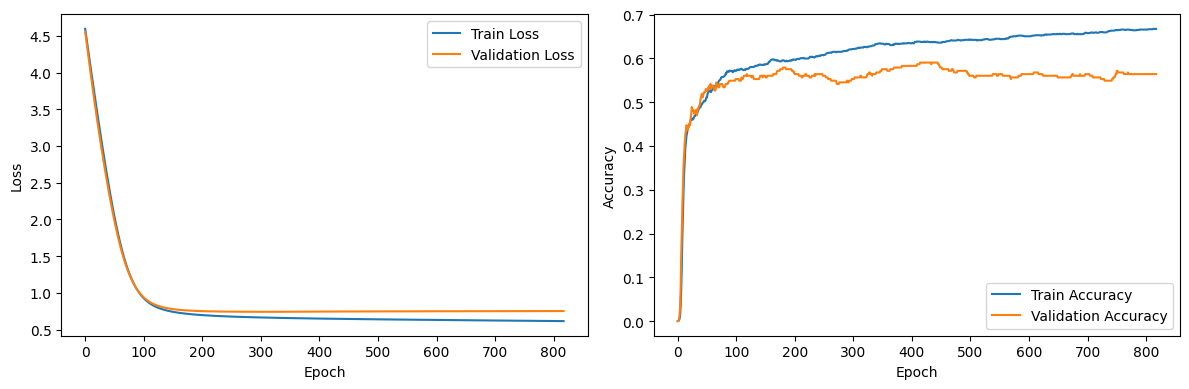


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1216, Val Loss: 4.0925, Train Acc: 0.2273, Val Acc: 0.2471
Epoch: 020, Train Loss: 3.5576, Val Loss: 3.5473, Train Acc: 0.5386, Val Acc: 0.4902
Epoch: 030, Train Loss: 3.0286, Val Loss: 3.0258, Train Acc: 0.5654, Val Acc: 0.5137
Epoch: 040, Train Loss: 2.5467, Val Loss: 2.5431, Train Acc: 0.5755, Val Acc: 0.5176
Epoch: 050, Train Loss: 2.1214, Val Loss: 2.1143, Train Acc: 0.5847, Val Acc: 0.5333
Epoch: 060, Train Loss: 1.7623, Val Loss: 1.7514, Train Acc: 0.5931, Val Acc: 0.5412
Epoch: 070, Train Loss: 1.4742, Val Loss: 1.4607, Train Acc: 0.6007, Val Acc: 0.5451
Epoch: 080, Train Loss: 1.2533, Val Loss: 1.2404, Train Acc: 0.6032, Val Acc: 0.5412
Epoch: 090, Train Loss: 1.0907, Val Loss: 1.0813, Train Acc: 0.6074, Val Acc: 0.5451
Epoch: 100, Train Loss: 0.9745, Val Loss: 0.9703, Train Acc: 0.6141, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.8929, Val Loss: 0.8940, Tr

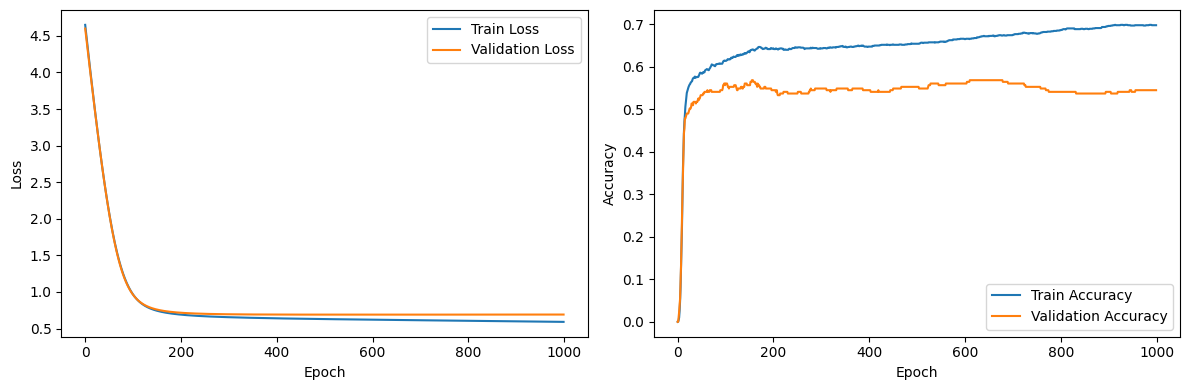


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2393, Val Loss: 4.2119, Train Acc: 0.1561, Val Acc: 0.2712
Epoch: 020, Train Loss: 3.7227, Val Loss: 3.6822, Train Acc: 0.4673, Val Acc: 0.5424
Epoch: 030, Train Loss: 3.2096, Val Loss: 3.1964, Train Acc: 0.5263, Val Acc: 0.5551
Epoch: 040, Train Loss: 2.7092, Val Loss: 2.7381, Train Acc: 0.5327, Val Acc: 0.5551
Epoch: 050, Train Loss: 2.2409, Val Loss: 2.3057, Train Acc: 0.5372, Val Acc: 0.5297
Epoch: 060, Train Loss: 1.8301, Val Loss: 1.9189, Train Acc: 0.5499, Val Acc: 0.5127
Epoch: 070, Train Loss: 1.4966, Val Loss: 1.5977, Train Acc: 0.5535, Val Acc: 0.5000
Epoch: 080, Train Loss: 1.2464, Val Loss: 1.3516, Train Acc: 0.5581, Val Acc: 0.5000
Epoch: 090, Train Loss: 1.0713, Val Loss: 1.1754, Train Acc: 0.5681, Val Acc: 0.5042
Epoch: 100, Train Loss: 0.9541, Val Loss: 1.0540, Train Acc: 0.5726, Val Acc: 0.4915
Epoch: 110, Train Loss: 0.8768, Val Loss: 0.9715, Tr

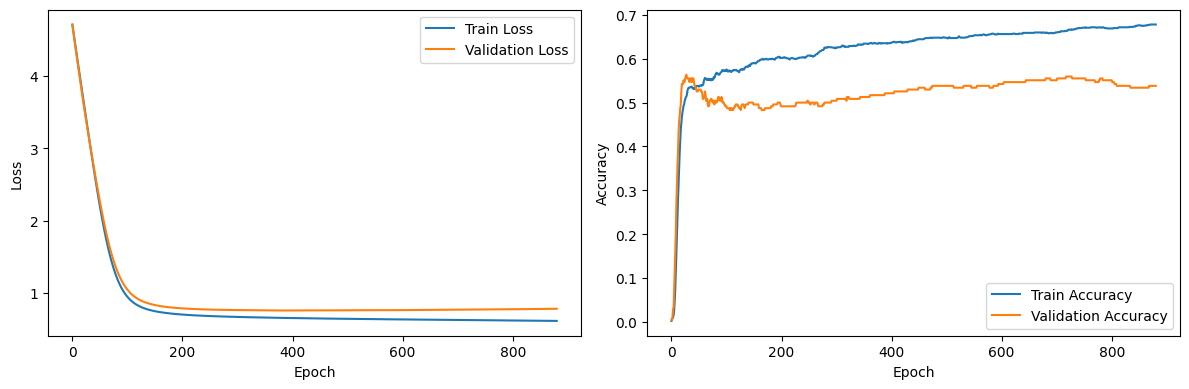


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.8773, Val Loss: 3.8152, Train Acc: 0.3632, Val Acc: 0.3716
Epoch: 020, Train Loss: 3.2880, Val Loss: 3.2411, Train Acc: 0.5492, Val Acc: 0.4908
Epoch: 030, Train Loss: 2.7565, Val Loss: 2.7260, Train Acc: 0.5610, Val Acc: 0.5046
Epoch: 040, Train Loss: 2.2887, Val Loss: 2.2722, Train Acc: 0.5669, Val Acc: 0.5046
Epoch: 050, Train Loss: 1.8868, Val Loss: 1.8809, Train Acc: 0.5738, Val Acc: 0.5183
Epoch: 060, Train Loss: 1.5591, Val Loss: 1.5593, Train Acc: 0.5738, Val Acc: 0.5138
Epoch: 070, Train Loss: 1.3076, Val Loss: 1.3117, Train Acc: 0.5719, Val Acc: 0.5138
Epoch: 080, Train Loss: 1.1246, Val Loss: 1.1324, Train Acc: 0.5738, Val Acc: 0.5229
Epoch: 090, Train Loss: 0.9968, Val Loss: 1.0081, Train Acc: 0.5689, Val Acc: 0.5275
Epoch: 100, Train Loss: 0.9095, Val Loss: 0.9237, Train Acc: 0.5719, Val Acc: 0.5183
Epoch: 110, Train Loss: 0.8501, Val Loss: 0.8665, Tr

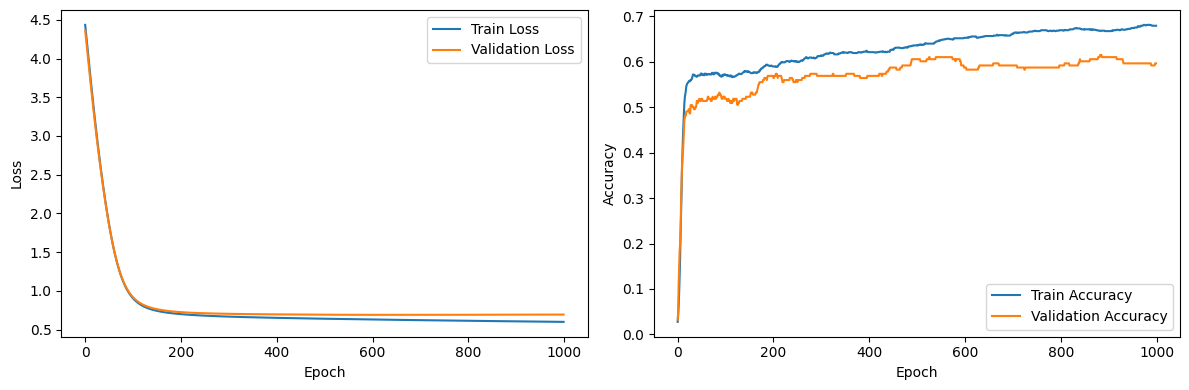


========== Run 18 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0508, Val Loss: 3.9765, Train Acc: 0.3352, Val Acc: 0.3534
Epoch: 020, Train Loss: 3.5138, Val Loss: 3.4241, Train Acc: 0.5254, Val Acc: 0.5113
Epoch: 030, Train Loss: 2.9965, Val Loss: 2.9161, Train Acc: 0.5399, Val Acc: 0.5075
Epoch: 040, Train Loss: 2.5086, Val Loss: 2.4460, Train Acc: 0.5552, Val Acc: 0.5150
Epoch: 050, Train Loss: 2.0681, Val Loss: 2.0249, Train Acc: 0.5641, Val Acc: 0.5338
Epoch: 060, Train Loss: 1.6958, Val Loss: 1.6715, Train Acc: 0.5673, Val Acc: 0.5376
Epoch: 070, Train Loss: 1.4020, Val Loss: 1.3947, Train Acc: 0.5592, Val Acc: 0.5602
Epoch: 080, Train Loss: 1.1847, Val Loss: 1.1916, Train Acc: 0.5737, Val Acc: 0.5526
Epoch: 090, Train Loss: 1.0324, Val Loss: 1.0499, Train Acc: 0.5689, Val Acc: 0.5489
Epoch: 100, Train Loss: 0.9290, Val Loss: 0.9539, Train Acc: 0.5665, Val Acc: 0.5526
Epoch: 110, Train Los

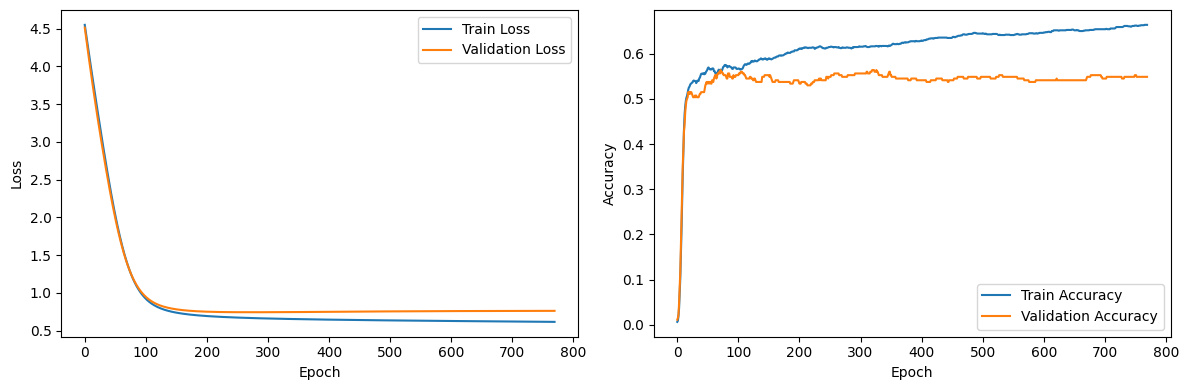


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.7841, Val Loss: 3.7651, Train Acc: 0.4564, Val Acc: 0.4314
Epoch: 020, Train Loss: 3.2259, Val Loss: 3.2161, Train Acc: 0.5864, Val Acc: 0.5098
Epoch: 030, Train Loss: 2.7068, Val Loss: 2.6954, Train Acc: 0.5973, Val Acc: 0.5216
Epoch: 040, Train Loss: 2.2418, Val Loss: 2.2246, Train Acc: 0.6082, Val Acc: 0.5294
Epoch: 050, Train Loss: 1.8462, Val Loss: 1.8233, Train Acc: 0.6174, Val Acc: 0.5216
Epoch: 060, Train Loss: 1.5287, Val Loss: 1.5025, Train Acc: 0.6250, Val Acc: 0.5216
Epoch: 070, Train Loss: 1.2870, Val Loss: 1.2617, Train Acc: 0.6275, Val Acc: 0.5176
Epoch: 080, Train Loss: 1.1104, Val Loss: 1.0898, Train Acc: 0.6258, Val Acc: 0.5373
Epoch: 090, Train Loss: 0.9853, Val Loss: 0.9714, Train Acc: 0.6258, Val Acc: 0.5255
Epoch: 100, Train Loss: 0.8983, Val Loss: 0.8917, Train Acc: 0.6275, Val Acc: 0.5333
Epoch: 110, Train Loss: 0.8380, Val Loss: 0.8380, Tr

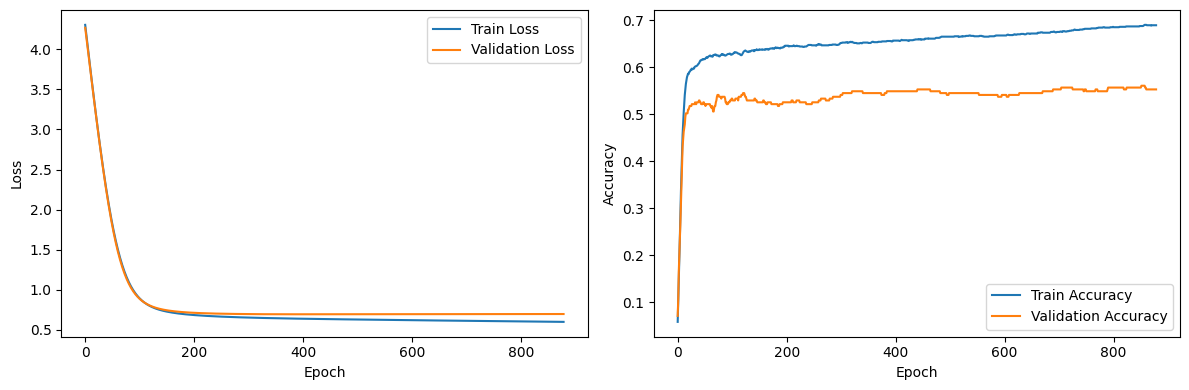


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2389, Val Loss: 4.1477, Train Acc: 0.2042, Val Acc: 0.3263
Epoch: 020, Train Loss: 3.7346, Val Loss: 3.6568, Train Acc: 0.5000, Val Acc: 0.5212
Epoch: 030, Train Loss: 3.2358, Val Loss: 3.1911, Train Acc: 0.5209, Val Acc: 0.5339
Epoch: 040, Train Loss: 2.7468, Val Loss: 2.7453, Train Acc: 0.5245, Val Acc: 0.5339
Epoch: 050, Train Loss: 2.2857, Val Loss: 2.3248, Train Acc: 0.5299, Val Acc: 0.5508
Epoch: 060, Train Loss: 1.8766, Val Loss: 1.9436, Train Acc: 0.5472, Val Acc: 0.5339
Epoch: 070, Train Loss: 1.5403, Val Loss: 1.6212, Train Acc: 0.5644, Val Acc: 0.5085
Epoch: 080, Train Loss: 1.2837, Val Loss: 1.3694, Train Acc: 0.5835, Val Acc: 0.4873
Epoch: 090, Train Loss: 1.1004, Val Loss: 1.1853, Train Acc: 0.5853, Val Acc: 0.4831
Epoch: 100, Train Loss: 0.9753, Val Loss: 1.0558, Train Acc: 0.5799, Val Acc: 0.4788
Epoch: 110, Train Loss: 0.8915, Val Loss: 0.9666, Tr

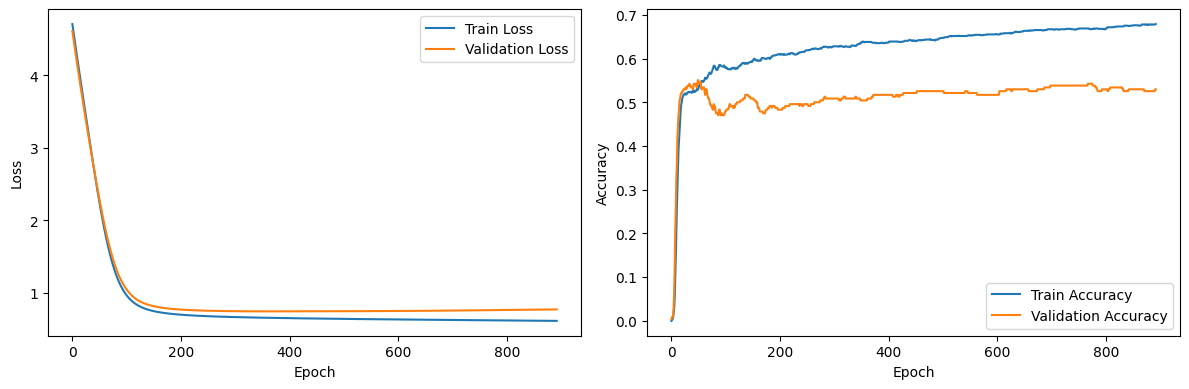


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.8856, Val Loss: 3.8513, Train Acc: 0.3484, Val Acc: 0.3394
Epoch: 020, Train Loss: 3.3068, Val Loss: 3.2858, Train Acc: 0.4734, Val Acc: 0.4404
Epoch: 030, Train Loss: 2.7893, Val Loss: 2.7808, Train Acc: 0.4892, Val Acc: 0.4633
Epoch: 040, Train Loss: 2.3288, Val Loss: 2.3311, Train Acc: 0.5079, Val Acc: 0.4908
Epoch: 050, Train Loss: 1.9290, Val Loss: 1.9379, Train Acc: 0.5246, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.6003, Val Loss: 1.6115, Train Acc: 0.5335, Val Acc: 0.5092
Epoch: 070, Train Loss: 1.3461, Val Loss: 1.3576, Train Acc: 0.5433, Val Acc: 0.5275
Epoch: 080, Train Loss: 1.1595, Val Loss: 1.1717, Train Acc: 0.5531, Val Acc: 0.5229
Epoch: 090, Train Loss: 1.0271, Val Loss: 1.0405, Train Acc: 0.5541, Val Acc: 0.5413
Epoch: 100, Train Loss: 0.9349, Val Loss: 0.9493, Train Acc: 0.5502, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.8708, Val Loss: 0.8859, Tr

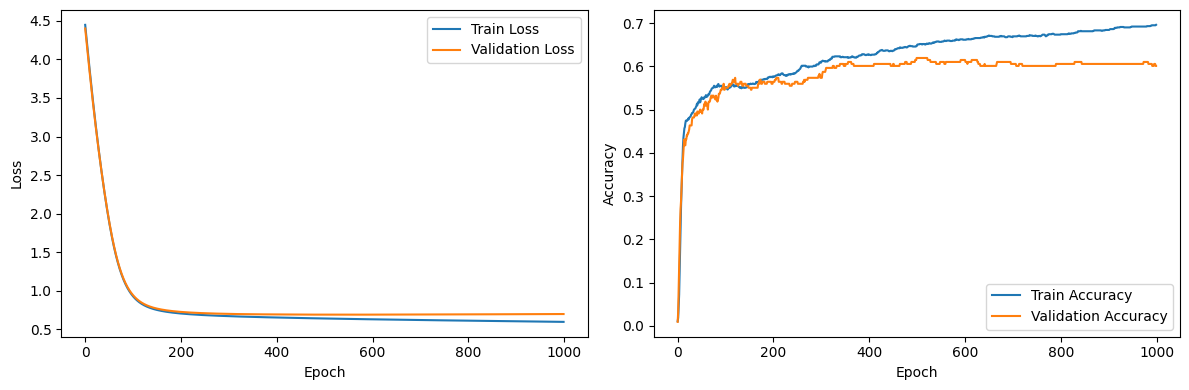


========== Run 19 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9109, Val Loss: 3.8275, Train Acc: 0.3118, Val Acc: 0.3571
Epoch: 020, Train Loss: 3.3587, Val Loss: 3.2571, Train Acc: 0.5504, Val Acc: 0.5338
Epoch: 030, Train Loss: 2.8408, Val Loss: 2.7518, Train Acc: 0.5745, Val Acc: 0.5564
Epoch: 040, Train Loss: 2.3652, Val Loss: 2.3002, Train Acc: 0.5761, Val Acc: 0.5602
Epoch: 050, Train Loss: 1.9478, Val Loss: 1.9079, Train Acc: 0.5882, Val Acc: 0.5714
Epoch: 060, Train Loss: 1.6038, Val Loss: 1.5854, Train Acc: 0.5818, Val Acc: 0.5827
Epoch: 070, Train Loss: 1.3372, Val Loss: 1.3353, Train Acc: 0.5818, Val Acc: 0.5714
Epoch: 080, Train Loss: 1.1415, Val Loss: 1.1511, Train Acc: 0.5850, Val Acc: 0.5639
Epoch: 090, Train Loss: 1.0040, Val Loss: 1.0214, Train Acc: 0.5818, Val Acc: 0.5677
Epoch: 100, Train Loss: 0.9099, Val Loss: 0.9331, Train Acc: 0.5810, Val Acc: 0.5677
Epoch: 110, Train Los

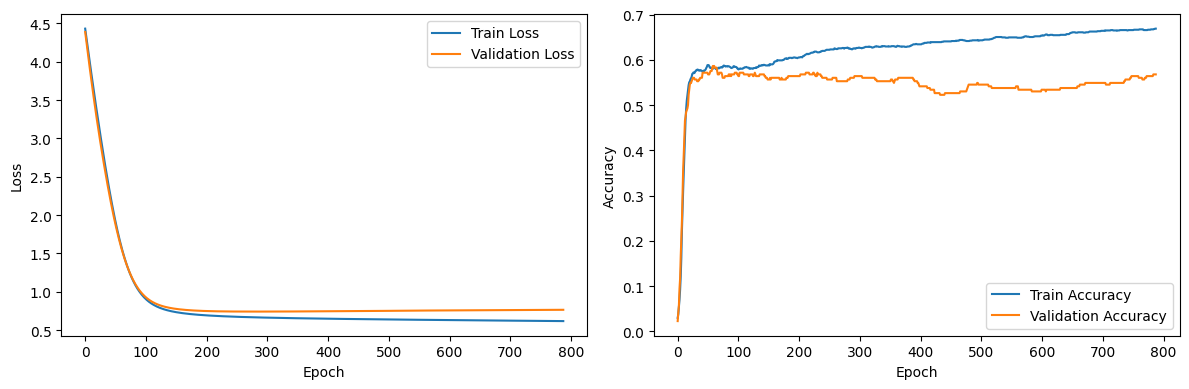


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0838, Val Loss: 4.0472, Train Acc: 0.2727, Val Acc: 0.2824
Epoch: 020, Train Loss: 3.5298, Val Loss: 3.5159, Train Acc: 0.5252, Val Acc: 0.5137
Epoch: 030, Train Loss: 3.0029, Val Loss: 2.9981, Train Acc: 0.5453, Val Acc: 0.5412
Epoch: 040, Train Loss: 2.5162, Val Loss: 2.5098, Train Acc: 0.5579, Val Acc: 0.5490
Epoch: 050, Train Loss: 2.0834, Val Loss: 2.0713, Train Acc: 0.5671, Val Acc: 0.5451
Epoch: 060, Train Loss: 1.7189, Val Loss: 1.7006, Train Acc: 0.5721, Val Acc: 0.5451
Epoch: 070, Train Loss: 1.4294, Val Loss: 1.4077, Train Acc: 0.5864, Val Acc: 0.5451
Epoch: 080, Train Loss: 1.2119, Val Loss: 1.1908, Train Acc: 0.5990, Val Acc: 0.5490
Epoch: 090, Train Loss: 1.0557, Val Loss: 1.0389, Train Acc: 0.6074, Val Acc: 0.5294
Epoch: 100, Train Loss: 0.9465, Val Loss: 0.9359, Train Acc: 0.6082, Val Acc: 0.5294
Epoch: 110, Train Loss: 0.8712, Val Loss: 0.8668, Tr

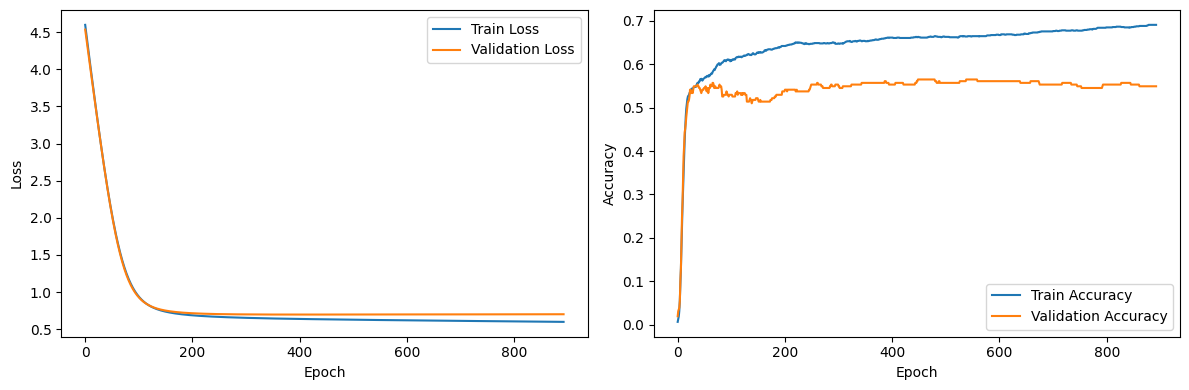


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.8693, Val Loss: 3.7839, Train Acc: 0.3757, Val Acc: 0.4110
Epoch: 020, Train Loss: 3.3366, Val Loss: 3.2917, Train Acc: 0.5172, Val Acc: 0.5042
Epoch: 030, Train Loss: 2.8185, Val Loss: 2.8272, Train Acc: 0.5318, Val Acc: 0.5000
Epoch: 040, Train Loss: 2.3320, Val Loss: 2.3891, Train Acc: 0.5363, Val Acc: 0.5085
Epoch: 050, Train Loss: 1.9016, Val Loss: 1.9891, Train Acc: 0.5381, Val Acc: 0.5000
Epoch: 060, Train Loss: 1.5485, Val Loss: 1.6470, Train Acc: 0.5454, Val Acc: 0.4831
Epoch: 070, Train Loss: 1.2807, Val Loss: 1.3786, Train Acc: 0.5472, Val Acc: 0.4873
Epoch: 080, Train Loss: 1.0913, Val Loss: 1.1842, Train Acc: 0.5472, Val Acc: 0.4788
Epoch: 090, Train Loss: 0.9642, Val Loss: 1.0509, Train Acc: 0.5472, Val Acc: 0.4661
Epoch: 100, Train Loss: 0.8807, Val Loss: 0.9617, Train Acc: 0.5554, Val Acc: 0.4746
Epoch: 110, Train Loss: 0.8257, Val Loss: 0.9026, Tr

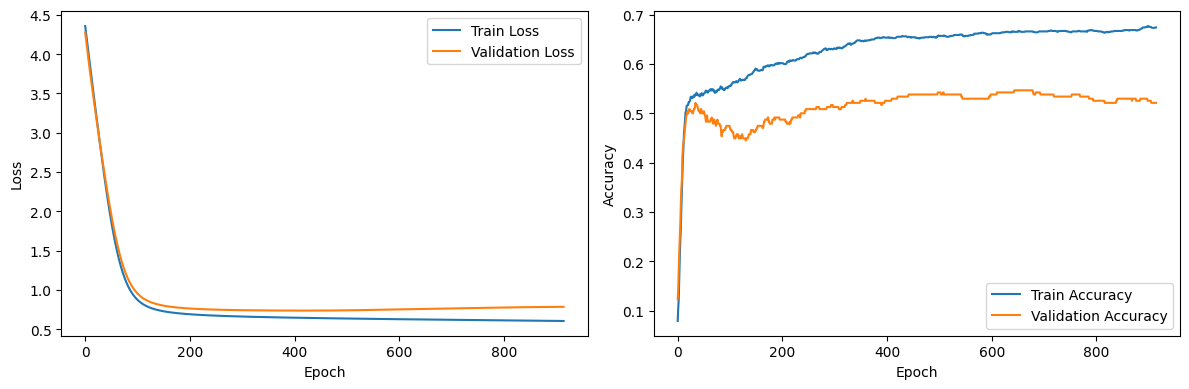


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9415, Val Loss: 3.8683, Train Acc: 0.3730, Val Acc: 0.4541
Epoch: 020, Train Loss: 3.3575, Val Loss: 3.2992, Train Acc: 0.5246, Val Acc: 0.5780
Epoch: 030, Train Loss: 2.8267, Val Loss: 2.7826, Train Acc: 0.5344, Val Acc: 0.5963
Epoch: 040, Train Loss: 2.3563, Val Loss: 2.3246, Train Acc: 0.5354, Val Acc: 0.6055
Epoch: 050, Train Loss: 1.9510, Val Loss: 1.9277, Train Acc: 0.5453, Val Acc: 0.6147
Epoch: 060, Train Loss: 1.6179, Val Loss: 1.5993, Train Acc: 0.5551, Val Acc: 0.5963
Epoch: 070, Train Loss: 1.3585, Val Loss: 1.3439, Train Acc: 0.5689, Val Acc: 0.5826
Epoch: 080, Train Loss: 1.1662, Val Loss: 1.1564, Train Acc: 0.5679, Val Acc: 0.5826
Epoch: 090, Train Loss: 1.0285, Val Loss: 1.0241, Train Acc: 0.5797, Val Acc: 0.5780
Epoch: 100, Train Loss: 0.9321, Val Loss: 0.9329, Train Acc: 0.5846, Val Acc: 0.5826
Epoch: 110, Train Loss: 0.8649, Val Loss: 0.8706, Tr

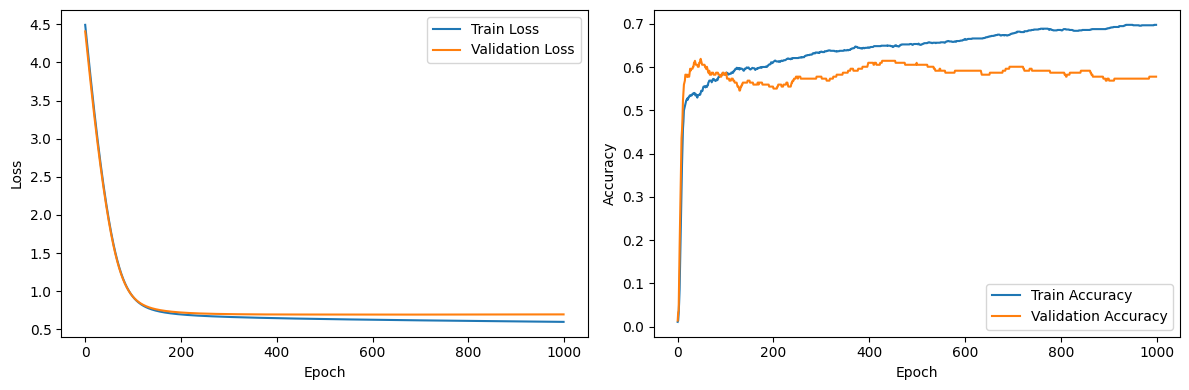


========== Run 20 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0585, Val Loss: 3.9883, Train Acc: 0.2780, Val Acc: 0.3722
Epoch: 020, Train Loss: 3.4933, Val Loss: 3.4009, Train Acc: 0.4972, Val Acc: 0.5639
Epoch: 030, Train Loss: 2.9598, Val Loss: 2.8766, Train Acc: 0.5351, Val Acc: 0.5414
Epoch: 040, Train Loss: 2.4663, Val Loss: 2.4058, Train Acc: 0.5383, Val Acc: 0.5414
Epoch: 050, Train Loss: 2.0294, Val Loss: 1.9933, Train Acc: 0.5423, Val Acc: 0.5489
Epoch: 060, Train Loss: 1.6671, Val Loss: 1.6538, Train Acc: 0.5560, Val Acc: 0.5564
Epoch: 070, Train Loss: 1.3856, Val Loss: 1.3918, Train Acc: 0.5584, Val Acc: 0.5677
Epoch: 080, Train Loss: 1.1787, Val Loss: 1.2001, Train Acc: 0.5649, Val Acc: 0.5902
Epoch: 090, Train Loss: 1.0331, Val Loss: 1.0659, Train Acc: 0.5721, Val Acc: 0.5977
Epoch: 100, Train Loss: 0.9335, Val Loss: 0.9740, Train Acc: 0.5713, Val Acc: 0.5827
Epoch: 110, Train Los

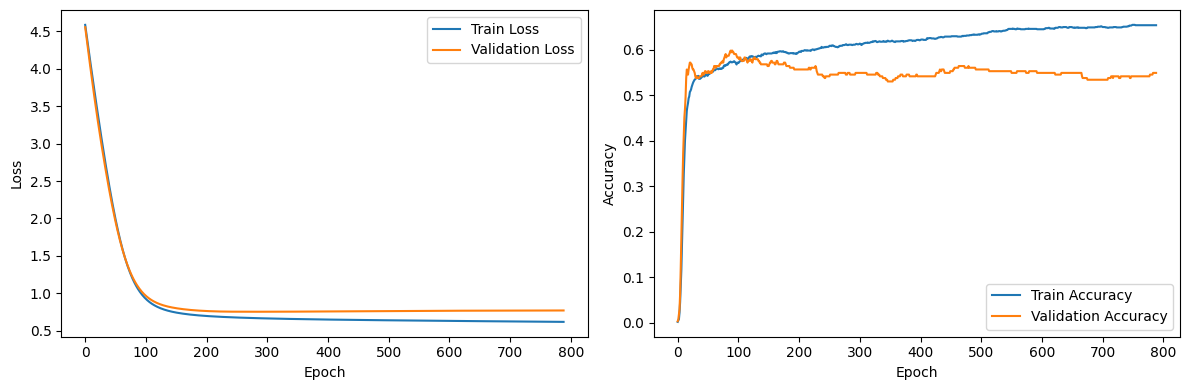


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9759, Val Loss: 3.9486, Train Acc: 0.3020, Val Acc: 0.3294
Epoch: 020, Train Loss: 3.4186, Val Loss: 3.4096, Train Acc: 0.5042, Val Acc: 0.5451
Epoch: 030, Train Loss: 2.8951, Val Loss: 2.8900, Train Acc: 0.5327, Val Acc: 0.5490
Epoch: 040, Train Loss: 2.4196, Val Loss: 2.4079, Train Acc: 0.5419, Val Acc: 0.5569
Epoch: 050, Train Loss: 2.0040, Val Loss: 1.9820, Train Acc: 0.5495, Val Acc: 0.5765
Epoch: 060, Train Loss: 1.6597, Val Loss: 1.6278, Train Acc: 0.5629, Val Acc: 0.5843
Epoch: 070, Train Loss: 1.3899, Val Loss: 1.3527, Train Acc: 0.6007, Val Acc: 0.5804
Epoch: 080, Train Loss: 1.1886, Val Loss: 1.1520, Train Acc: 0.6065, Val Acc: 0.5922
Epoch: 090, Train Loss: 1.0437, Val Loss: 1.0121, Train Acc: 0.6133, Val Acc: 0.5882
Epoch: 100, Train Loss: 0.9417, Val Loss: 0.9172, Train Acc: 0.6233, Val Acc: 0.5843
Epoch: 110, Train Loss: 0.8705, Val Loss: 0.8533, Tr

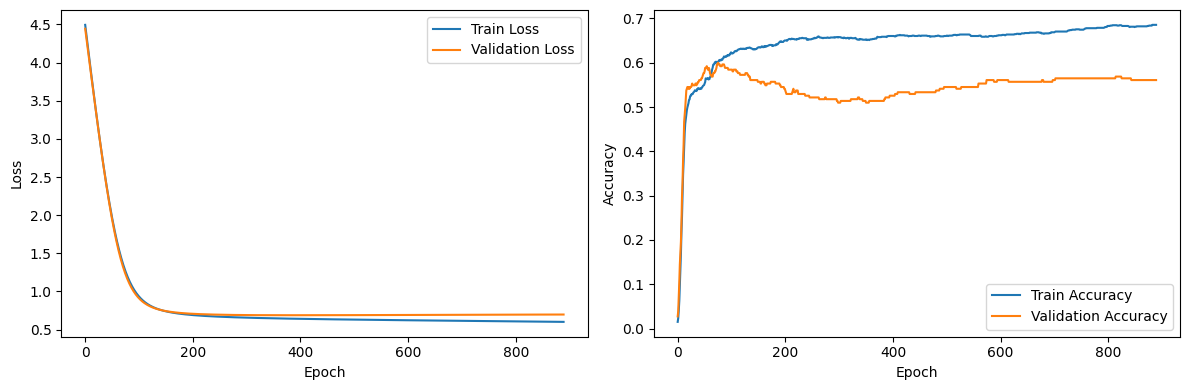


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0406, Val Loss: 4.0637, Train Acc: 0.4020, Val Acc: 0.4237
Epoch: 020, Train Loss: 3.5357, Val Loss: 3.5770, Train Acc: 0.5535, Val Acc: 0.4661
Epoch: 030, Train Loss: 3.0381, Val Loss: 3.1136, Train Acc: 0.5572, Val Acc: 0.4661
Epoch: 040, Train Loss: 2.5581, Val Loss: 2.6706, Train Acc: 0.5590, Val Acc: 0.4661
Epoch: 050, Train Loss: 2.1164, Val Loss: 2.2564, Train Acc: 0.5590, Val Acc: 0.4661
Epoch: 060, Train Loss: 1.7369, Val Loss: 1.8890, Train Acc: 0.5626, Val Acc: 0.4788
Epoch: 070, Train Loss: 1.4338, Val Loss: 1.5858, Train Acc: 0.5690, Val Acc: 0.4746
Epoch: 080, Train Loss: 1.2076, Val Loss: 1.3536, Train Acc: 0.5699, Val Acc: 0.4703
Epoch: 090, Train Loss: 1.0481, Val Loss: 1.1859, Train Acc: 0.5762, Val Acc: 0.4661
Epoch: 100, Train Loss: 0.9398, Val Loss: 1.0684, Train Acc: 0.5717, Val Acc: 0.4831
Epoch: 110, Train Loss: 0.8673, Val Loss: 0.9873, Tr

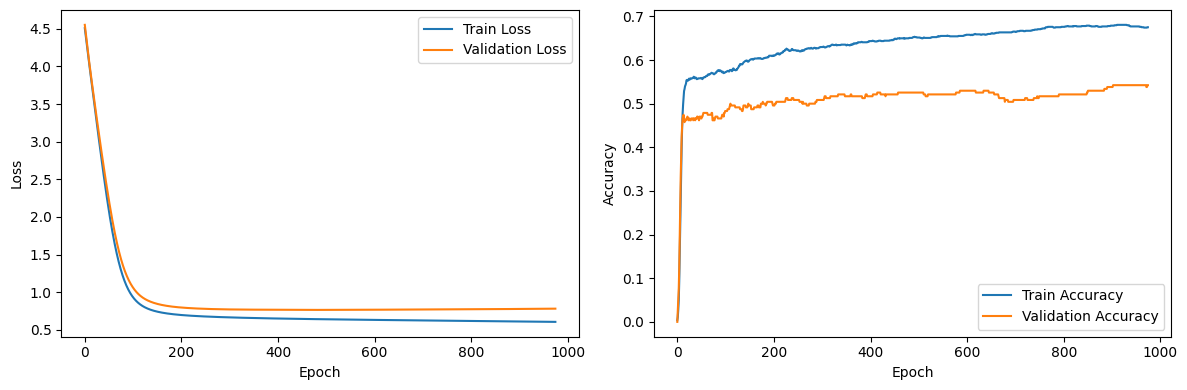


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2380, Val Loss: 4.1794, Train Acc: 0.1821, Val Acc: 0.2064
Epoch: 020, Train Loss: 3.6396, Val Loss: 3.5907, Train Acc: 0.4892, Val Acc: 0.4633
Epoch: 030, Train Loss: 3.0826, Val Loss: 3.0456, Train Acc: 0.5217, Val Acc: 0.4908
Epoch: 040, Train Loss: 2.5848, Val Loss: 2.5619, Train Acc: 0.5256, Val Acc: 0.4862
Epoch: 050, Train Loss: 2.1492, Val Loss: 2.1387, Train Acc: 0.5276, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.7821, Val Loss: 1.7785, Train Acc: 0.5325, Val Acc: 0.5000
Epoch: 070, Train Loss: 1.4890, Val Loss: 1.4874, Train Acc: 0.5502, Val Acc: 0.5092
Epoch: 080, Train Loss: 1.2670, Val Loss: 1.2655, Train Acc: 0.5591, Val Acc: 0.5321
Epoch: 090, Train Loss: 1.1056, Val Loss: 1.1047, Train Acc: 0.5728, Val Acc: 0.5505
Epoch: 100, Train Loss: 0.9910, Val Loss: 0.9915, Train Acc: 0.5719, Val Acc: 0.5734
Epoch: 110, Train Loss: 0.9105, Val Loss: 0.9126, Tr

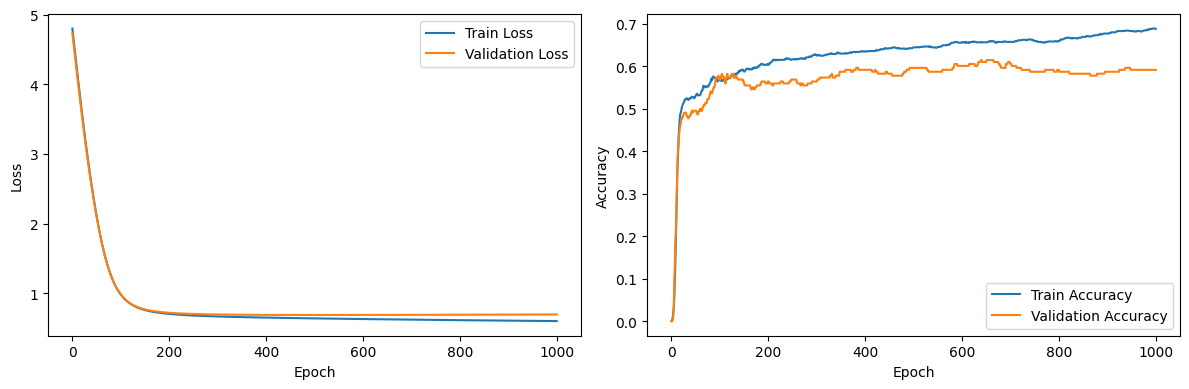


========== Run 21 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1321, Val Loss: 4.0740, Train Acc: 0.2224, Val Acc: 0.2406
Epoch: 020, Train Loss: 3.5888, Val Loss: 3.5103, Train Acc: 0.4891, Val Acc: 0.5038
Epoch: 030, Train Loss: 3.0728, Val Loss: 2.9993, Train Acc: 0.5351, Val Acc: 0.5263
Epoch: 040, Train Loss: 2.5886, Val Loss: 2.5284, Train Acc: 0.5528, Val Acc: 0.5338
Epoch: 050, Train Loss: 2.1490, Val Loss: 2.1008, Train Acc: 0.5584, Val Acc: 0.5338
Epoch: 060, Train Loss: 1.7714, Val Loss: 1.7343, Train Acc: 0.5560, Val Acc: 0.5602
Epoch: 070, Train Loss: 1.4670, Val Loss: 1.4415, Train Acc: 0.5536, Val Acc: 0.5677
Epoch: 080, Train Loss: 1.2362, Val Loss: 1.2220, Train Acc: 0.5576, Val Acc: 0.5752
Epoch: 090, Train Loss: 1.0703, Val Loss: 1.0663, Train Acc: 0.5745, Val Acc: 0.5639
Epoch: 100, Train Loss: 0.9554, Val Loss: 0.9601, Train Acc: 0.5858, Val Acc: 0.5526
Epoch: 110, Train Los

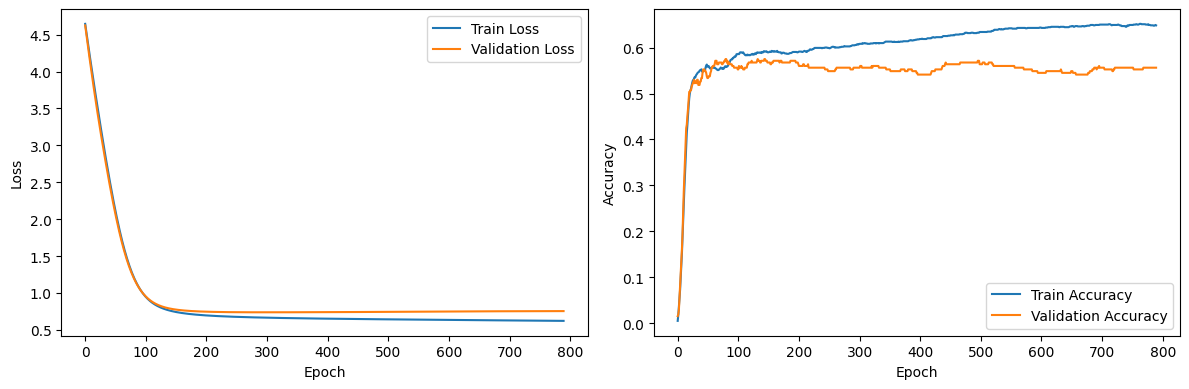


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.8716, Val Loss: 3.8633, Train Acc: 0.4497, Val Acc: 0.4588
Epoch: 020, Train Loss: 3.3336, Val Loss: 3.3398, Train Acc: 0.5336, Val Acc: 0.5176
Epoch: 030, Train Loss: 2.8228, Val Loss: 2.8300, Train Acc: 0.5403, Val Acc: 0.5333
Epoch: 040, Train Loss: 2.3508, Val Loss: 2.3517, Train Acc: 0.5537, Val Acc: 0.5490
Epoch: 050, Train Loss: 1.9341, Val Loss: 1.9272, Train Acc: 0.5570, Val Acc: 0.5608
Epoch: 060, Train Loss: 1.5887, Val Loss: 1.5756, Train Acc: 0.5671, Val Acc: 0.5686
Epoch: 070, Train Loss: 1.3215, Val Loss: 1.3055, Train Acc: 0.5772, Val Acc: 0.5725
Epoch: 080, Train Loss: 1.1273, Val Loss: 1.1122, Train Acc: 0.5923, Val Acc: 0.5765
Epoch: 090, Train Loss: 0.9923, Val Loss: 0.9807, Train Acc: 0.6032, Val Acc: 0.5882
Epoch: 100, Train Loss: 0.9000, Val Loss: 0.8934, Train Acc: 0.6183, Val Acc: 0.5922
Epoch: 110, Train Loss: 0.8373, Val Loss: 0.8358, Tr

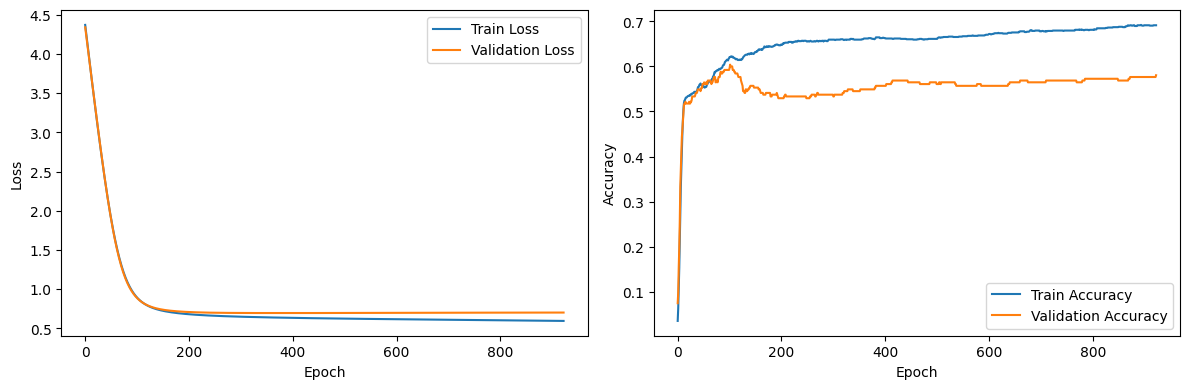


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0166, Val Loss: 3.9375, Train Acc: 0.3249, Val Acc: 0.3602
Epoch: 020, Train Loss: 3.4616, Val Loss: 3.4133, Train Acc: 0.4982, Val Acc: 0.4492
Epoch: 030, Train Loss: 2.9307, Val Loss: 2.9258, Train Acc: 0.5109, Val Acc: 0.4407
Epoch: 040, Train Loss: 2.4391, Val Loss: 2.4769, Train Acc: 0.5200, Val Acc: 0.4364
Epoch: 050, Train Loss: 2.0071, Val Loss: 2.0737, Train Acc: 0.5200, Val Acc: 0.4364
Epoch: 060, Train Loss: 1.6501, Val Loss: 1.7290, Train Acc: 0.5272, Val Acc: 0.4322
Epoch: 070, Train Loss: 1.3729, Val Loss: 1.4535, Train Acc: 0.5399, Val Acc: 0.4322
Epoch: 080, Train Loss: 1.1693, Val Loss: 1.2471, Train Acc: 0.5390, Val Acc: 0.4534
Epoch: 090, Train Loss: 1.0262, Val Loss: 1.1005, Train Acc: 0.5554, Val Acc: 0.4619
Epoch: 100, Train Loss: 0.9283, Val Loss: 0.9995, Train Acc: 0.5699, Val Acc: 0.4619
Epoch: 110, Train Loss: 0.8617, Val Loss: 0.9309, Tr

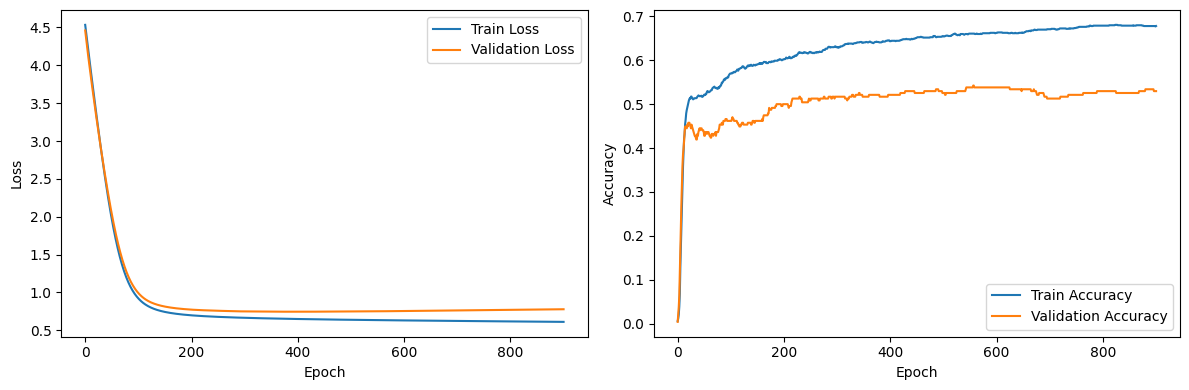


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2026, Val Loss: 4.1444, Train Acc: 0.1791, Val Acc: 0.2248
Epoch: 020, Train Loss: 3.6014, Val Loss: 3.5588, Train Acc: 0.4744, Val Acc: 0.5046
Epoch: 030, Train Loss: 3.0539, Val Loss: 3.0277, Train Acc: 0.5157, Val Acc: 0.5183
Epoch: 040, Train Loss: 2.5727, Val Loss: 2.5602, Train Acc: 0.5315, Val Acc: 0.5413
Epoch: 050, Train Loss: 2.1573, Val Loss: 2.1530, Train Acc: 0.5433, Val Acc: 0.5642
Epoch: 060, Train Loss: 1.8085, Val Loss: 1.8058, Train Acc: 0.5492, Val Acc: 0.5872
Epoch: 070, Train Loss: 1.5255, Val Loss: 1.5210, Train Acc: 0.5630, Val Acc: 0.5917
Epoch: 080, Train Loss: 1.3034, Val Loss: 1.2976, Train Acc: 0.5709, Val Acc: 0.6101
Epoch: 090, Train Loss: 1.1346, Val Loss: 1.1298, Train Acc: 0.5719, Val Acc: 0.6009
Epoch: 100, Train Loss: 1.0099, Val Loss: 1.0081, Train Acc: 0.5679, Val Acc: 0.5826
Epoch: 110, Train Loss: 0.9201, Val Loss: 0.9218, Tr

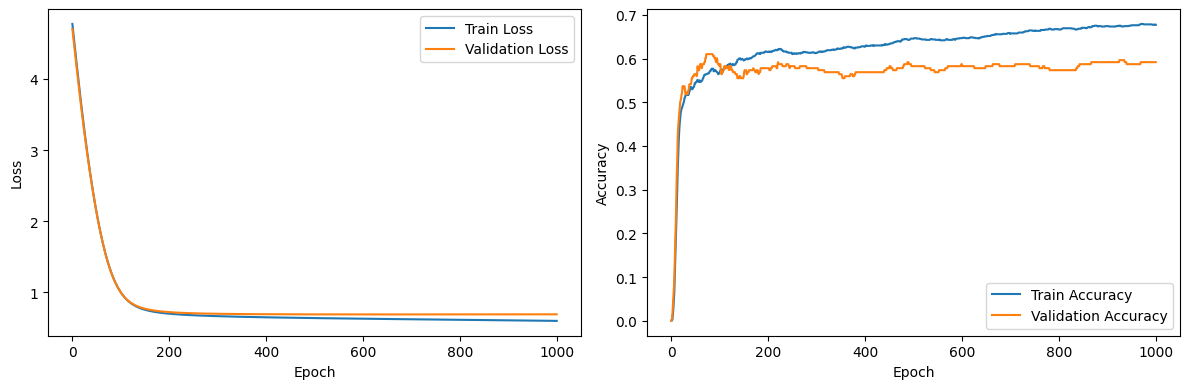


========== Run 22 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9438, Val Loss: 3.8213, Train Acc: 0.3715, Val Acc: 0.3835
Epoch: 020, Train Loss: 3.4033, Val Loss: 3.2770, Train Acc: 0.4932, Val Acc: 0.4624
Epoch: 030, Train Loss: 2.8874, Val Loss: 2.7732, Train Acc: 0.4980, Val Acc: 0.4850
Epoch: 040, Train Loss: 2.4041, Val Loss: 2.3060, Train Acc: 0.5085, Val Acc: 0.5113
Epoch: 050, Train Loss: 1.9704, Val Loss: 1.8893, Train Acc: 0.5165, Val Acc: 0.5075
Epoch: 060, Train Loss: 1.6059, Val Loss: 1.5437, Train Acc: 0.5334, Val Acc: 0.5150
Epoch: 070, Train Loss: 1.3225, Val Loss: 1.2801, Train Acc: 0.5552, Val Acc: 0.5564
Epoch: 080, Train Loss: 1.1188, Val Loss: 1.0940, Train Acc: 0.5713, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.9811, Val Loss: 0.9694, Train Acc: 0.5810, Val Acc: 0.5677
Epoch: 100, Train Loss: 0.8910, Val Loss: 0.8883, Train Acc: 0.5923, Val Acc: 0.5564
Epoch: 110, Train Los

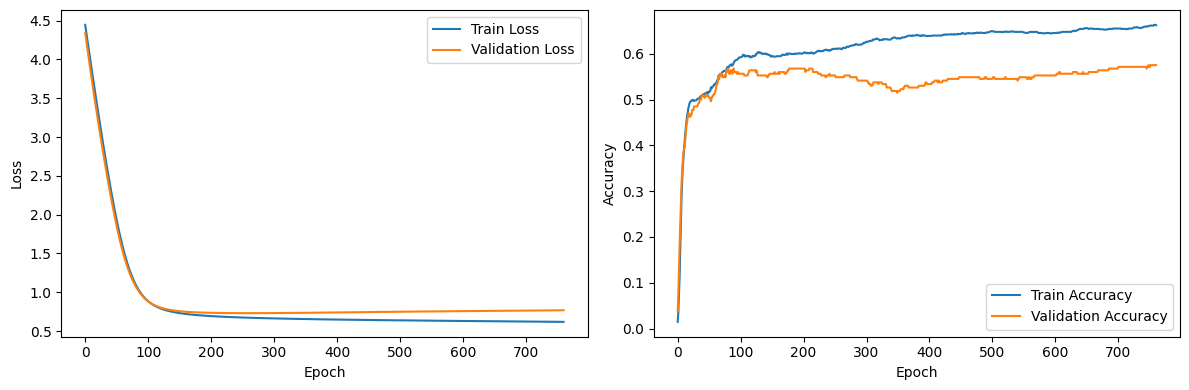


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0913, Val Loss: 4.0697, Train Acc: 0.2424, Val Acc: 0.2392
Epoch: 020, Train Loss: 3.5189, Val Loss: 3.5121, Train Acc: 0.4857, Val Acc: 0.4431
Epoch: 030, Train Loss: 2.9676, Val Loss: 2.9616, Train Acc: 0.5302, Val Acc: 0.5020
Epoch: 040, Train Loss: 2.4599, Val Loss: 2.4451, Train Acc: 0.5394, Val Acc: 0.5176
Epoch: 050, Train Loss: 2.0162, Val Loss: 1.9904, Train Acc: 0.5621, Val Acc: 0.5333
Epoch: 060, Train Loss: 1.6540, Val Loss: 1.6194, Train Acc: 0.5814, Val Acc: 0.5451
Epoch: 070, Train Loss: 1.3772, Val Loss: 1.3394, Train Acc: 0.5864, Val Acc: 0.5529
Epoch: 080, Train Loss: 1.1756, Val Loss: 1.1406, Train Acc: 0.5898, Val Acc: 0.5490
Epoch: 090, Train Loss: 1.0330, Val Loss: 1.0048, Train Acc: 0.5931, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.9337, Val Loss: 0.9137, Train Acc: 0.5998, Val Acc: 0.5490
Epoch: 110, Train Loss: 0.8649, Val Loss: 0.8527, Tr

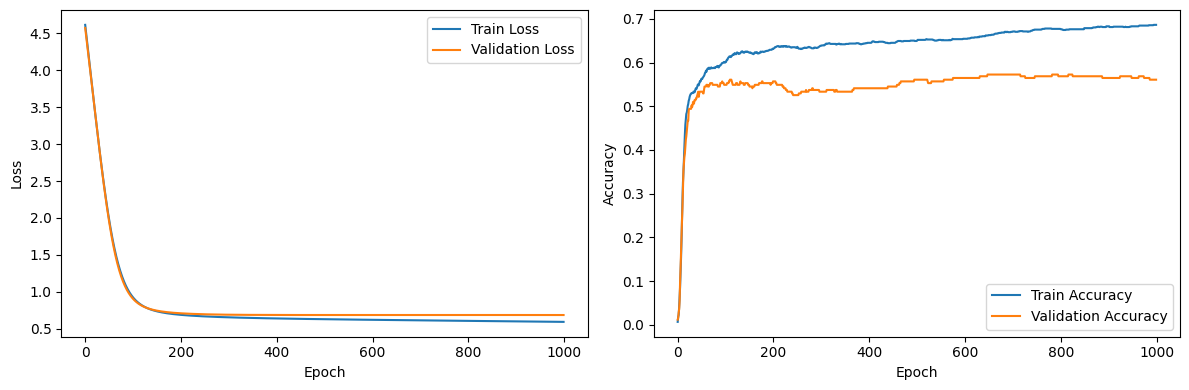


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0289, Val Loss: 3.9503, Train Acc: 0.2731, Val Acc: 0.3602
Epoch: 020, Train Loss: 3.5004, Val Loss: 3.4438, Train Acc: 0.5218, Val Acc: 0.4788
Epoch: 030, Train Loss: 2.9891, Val Loss: 2.9752, Train Acc: 0.5390, Val Acc: 0.5042
Epoch: 040, Train Loss: 2.5051, Val Loss: 2.5338, Train Acc: 0.5417, Val Acc: 0.5042
Epoch: 050, Train Loss: 2.0692, Val Loss: 2.1284, Train Acc: 0.5508, Val Acc: 0.5042
Epoch: 060, Train Loss: 1.7015, Val Loss: 1.7755, Train Acc: 0.5535, Val Acc: 0.5254
Epoch: 070, Train Loss: 1.4117, Val Loss: 1.4900, Train Acc: 0.5644, Val Acc: 0.5169
Epoch: 080, Train Loss: 1.1963, Val Loss: 1.2731, Train Acc: 0.5744, Val Acc: 0.5169
Epoch: 090, Train Loss: 1.0437, Val Loss: 1.1169, Train Acc: 0.5744, Val Acc: 0.5254
Epoch: 100, Train Loss: 0.9389, Val Loss: 1.0083, Train Acc: 0.5717, Val Acc: 0.5085
Epoch: 110, Train Loss: 0.8678, Val Loss: 0.9340, Tr

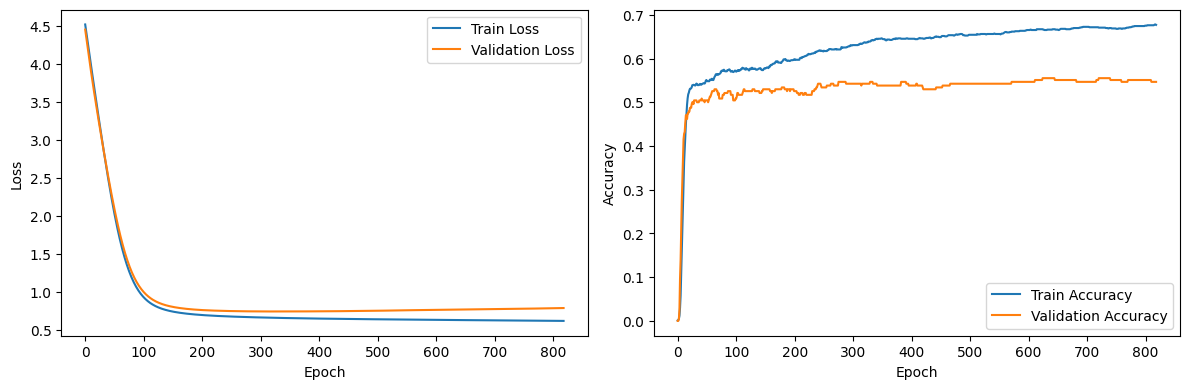


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0675, Val Loss: 4.0139, Train Acc: 0.2165, Val Acc: 0.2844
Epoch: 020, Train Loss: 3.4618, Val Loss: 3.4222, Train Acc: 0.5305, Val Acc: 0.5780
Epoch: 030, Train Loss: 2.9106, Val Loss: 2.8846, Train Acc: 0.5433, Val Acc: 0.6055
Epoch: 040, Train Loss: 2.4312, Val Loss: 2.4151, Train Acc: 0.5650, Val Acc: 0.6101
Epoch: 050, Train Loss: 2.0239, Val Loss: 2.0123, Train Acc: 0.5738, Val Acc: 0.6193
Epoch: 060, Train Loss: 1.6886, Val Loss: 1.6780, Train Acc: 0.5787, Val Acc: 0.6055
Epoch: 070, Train Loss: 1.4231, Val Loss: 1.4127, Train Acc: 0.5738, Val Acc: 0.6009
Epoch: 080, Train Loss: 1.2205, Val Loss: 1.2116, Train Acc: 0.5758, Val Acc: 0.5917
Epoch: 090, Train Loss: 1.0708, Val Loss: 1.0647, Train Acc: 0.5817, Val Acc: 0.5963
Epoch: 100, Train Loss: 0.9632, Val Loss: 0.9604, Train Acc: 0.5797, Val Acc: 0.6009
Epoch: 110, Train Loss: 0.8871, Val Loss: 0.8875, Tr

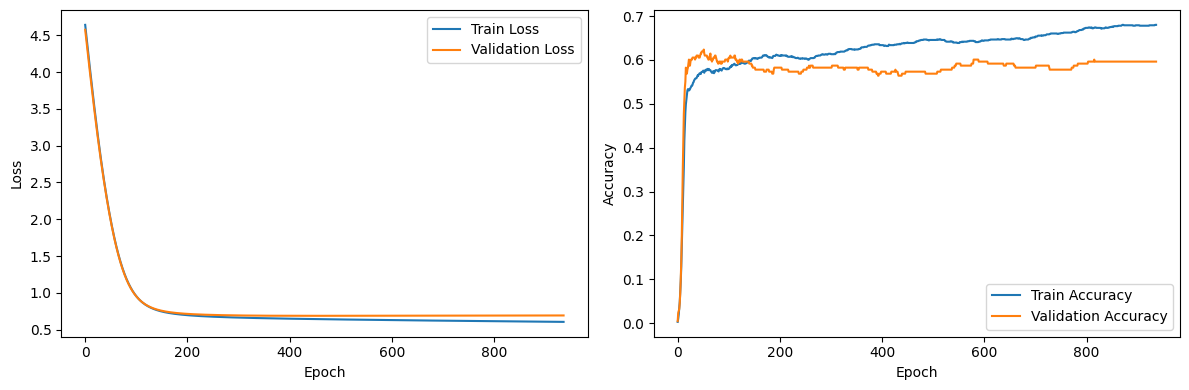


========== Run 23 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2439, Val Loss: 4.1656, Train Acc: 0.1152, Val Acc: 0.1692
Epoch: 020, Train Loss: 3.7091, Val Loss: 3.6018, Train Acc: 0.4956, Val Acc: 0.5263
Epoch: 030, Train Loss: 3.1862, Val Loss: 3.0757, Train Acc: 0.5399, Val Acc: 0.5526
Epoch: 040, Train Loss: 2.6843, Val Loss: 2.5880, Train Acc: 0.5552, Val Acc: 0.6053
Epoch: 050, Train Loss: 2.2193, Val Loss: 2.1423, Train Acc: 0.5608, Val Acc: 0.6165
Epoch: 060, Train Loss: 1.8141, Val Loss: 1.7570, Train Acc: 0.5818, Val Acc: 0.6165
Epoch: 070, Train Loss: 1.4870, Val Loss: 1.4481, Train Acc: 0.5858, Val Acc: 0.6316
Epoch: 080, Train Loss: 1.2420, Val Loss: 1.2183, Train Acc: 0.5745, Val Acc: 0.6316
Epoch: 090, Train Loss: 1.0696, Val Loss: 1.0580, Train Acc: 0.5794, Val Acc: 0.6429
Epoch: 100, Train Loss: 0.9531, Val Loss: 0.9512, Train Acc: 0.5818, Val Acc: 0.6353
Epoch: 110, Train Los

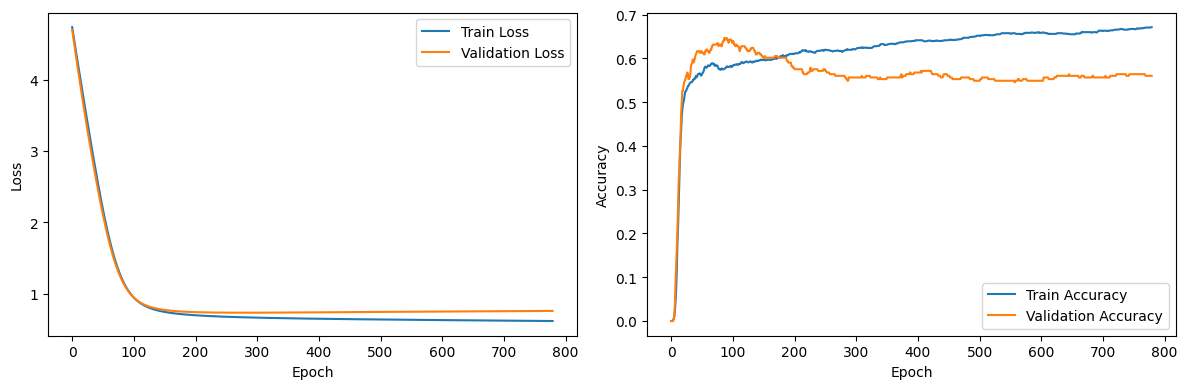


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2153, Val Loss: 4.1619, Train Acc: 0.1560, Val Acc: 0.2431
Epoch: 020, Train Loss: 3.6682, Val Loss: 3.6340, Train Acc: 0.5092, Val Acc: 0.5412
Epoch: 030, Train Loss: 3.1351, Val Loss: 3.1097, Train Acc: 0.5394, Val Acc: 0.5647
Epoch: 040, Train Loss: 2.6317, Val Loss: 2.6048, Train Acc: 0.5688, Val Acc: 0.5647
Epoch: 050, Train Loss: 2.1762, Val Loss: 2.1433, Train Acc: 0.5864, Val Acc: 0.5765
Epoch: 060, Train Loss: 1.7870, Val Loss: 1.7477, Train Acc: 0.5889, Val Acc: 0.5882
Epoch: 070, Train Loss: 1.4759, Val Loss: 1.4339, Train Acc: 0.5965, Val Acc: 0.5725
Epoch: 080, Train Loss: 1.2420, Val Loss: 1.2026, Train Acc: 0.6040, Val Acc: 0.5686
Epoch: 090, Train Loss: 1.0745, Val Loss: 1.0417, Train Acc: 0.6057, Val Acc: 0.5647
Epoch: 100, Train Loss: 0.9588, Val Loss: 0.9340, Train Acc: 0.6116, Val Acc: 0.5765
Epoch: 110, Train Loss: 0.8800, Val Loss: 0.8630, Tr

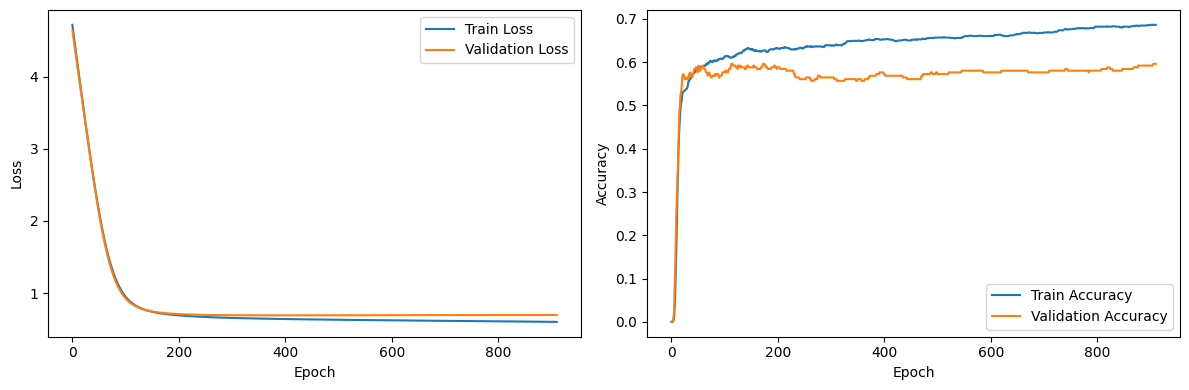


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9559, Val Loss: 3.9187, Train Acc: 0.4383, Val Acc: 0.4788
Epoch: 020, Train Loss: 3.4329, Val Loss: 3.4305, Train Acc: 0.5027, Val Acc: 0.5042
Epoch: 030, Train Loss: 2.9210, Val Loss: 2.9628, Train Acc: 0.5109, Val Acc: 0.5085
Epoch: 040, Train Loss: 2.4359, Val Loss: 2.5185, Train Acc: 0.5145, Val Acc: 0.5042
Epoch: 050, Train Loss: 1.9991, Val Loss: 2.1062, Train Acc: 0.5263, Val Acc: 0.4831
Epoch: 060, Train Loss: 1.6326, Val Loss: 1.7461, Train Acc: 0.5708, Val Acc: 0.4915
Epoch: 070, Train Loss: 1.3482, Val Loss: 1.4567, Train Acc: 0.5672, Val Acc: 0.4788
Epoch: 080, Train Loss: 1.1425, Val Loss: 1.2424, Train Acc: 0.5780, Val Acc: 0.4534
Epoch: 090, Train Loss: 1.0015, Val Loss: 1.0943, Train Acc: 0.5681, Val Acc: 0.4619
Epoch: 100, Train Loss: 0.9077, Val Loss: 0.9955, Train Acc: 0.5662, Val Acc: 0.4703
Epoch: 110, Train Loss: 0.8457, Val Loss: 0.9301, Tr

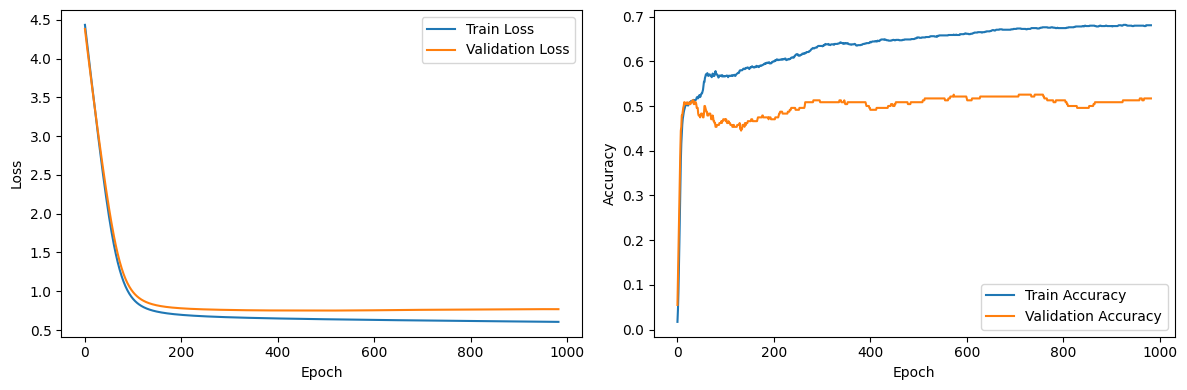


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.8596, Val Loss: 3.7952, Train Acc: 0.3642, Val Acc: 0.3991
Epoch: 020, Train Loss: 3.2789, Val Loss: 3.2297, Train Acc: 0.4902, Val Acc: 0.4954
Epoch: 030, Train Loss: 2.7602, Val Loss: 2.7228, Train Acc: 0.5020, Val Acc: 0.4954
Epoch: 040, Train Loss: 2.2991, Val Loss: 2.2694, Train Acc: 0.5069, Val Acc: 0.5046
Epoch: 050, Train Loss: 1.9007, Val Loss: 1.8746, Train Acc: 0.5138, Val Acc: 0.5275
Epoch: 060, Train Loss: 1.5745, Val Loss: 1.5495, Train Acc: 0.5177, Val Acc: 0.5321
Epoch: 070, Train Loss: 1.3224, Val Loss: 1.2997, Train Acc: 0.5246, Val Acc: 0.5275
Epoch: 080, Train Loss: 1.1368, Val Loss: 1.1189, Train Acc: 0.5482, Val Acc: 0.5550
Epoch: 090, Train Loss: 1.0054, Val Loss: 0.9930, Train Acc: 0.5758, Val Acc: 0.5688
Epoch: 100, Train Loss: 0.9146, Val Loss: 0.9071, Train Acc: 0.5787, Val Acc: 0.5596
Epoch: 110, Train Loss: 0.8524, Val Loss: 0.8490, Tr

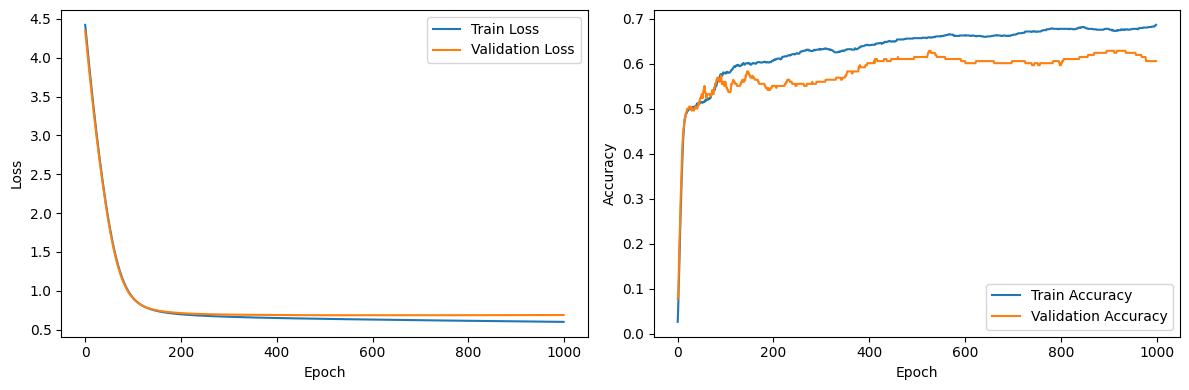


========== Run 24 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0108, Val Loss: 3.9520, Train Acc: 0.3175, Val Acc: 0.3534
Epoch: 020, Train Loss: 3.4672, Val Loss: 3.3812, Train Acc: 0.5351, Val Acc: 0.5113
Epoch: 030, Train Loss: 2.9430, Val Loss: 2.8578, Train Acc: 0.5584, Val Acc: 0.5451
Epoch: 040, Train Loss: 2.4521, Val Loss: 2.3834, Train Acc: 0.5633, Val Acc: 0.5602
Epoch: 050, Train Loss: 2.0155, Val Loss: 1.9662, Train Acc: 0.5681, Val Acc: 0.5639
Epoch: 060, Train Loss: 1.6536, Val Loss: 1.6219, Train Acc: 0.5697, Val Acc: 0.5714
Epoch: 070, Train Loss: 1.3730, Val Loss: 1.3560, Train Acc: 0.5802, Val Acc: 0.5677
Epoch: 080, Train Loss: 1.1670, Val Loss: 1.1624, Train Acc: 0.5770, Val Acc: 0.5789
Epoch: 090, Train Loss: 1.0220, Val Loss: 1.0282, Train Acc: 0.5786, Val Acc: 0.5602
Epoch: 100, Train Loss: 0.9226, Val Loss: 0.9379, Train Acc: 0.5826, Val Acc: 0.5677
Epoch: 110, Train Los

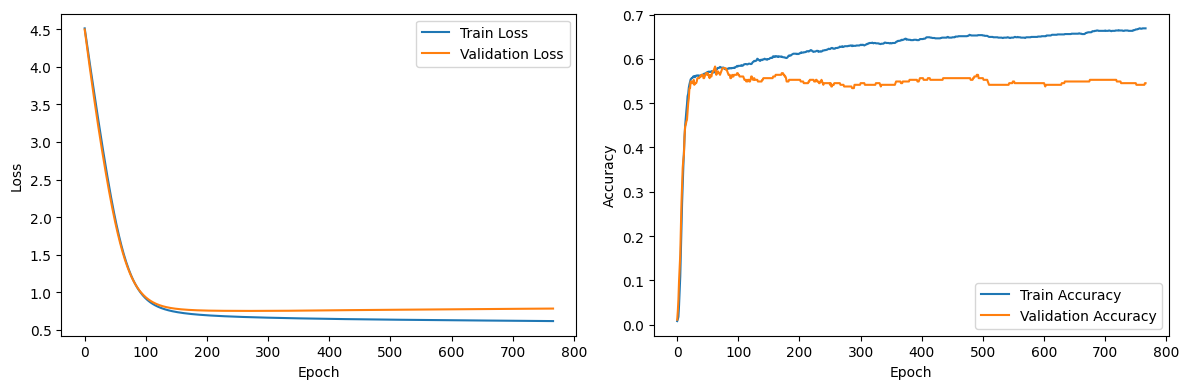


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2211, Val Loss: 4.2102, Train Acc: 0.2022, Val Acc: 0.2118
Epoch: 020, Train Loss: 3.6693, Val Loss: 3.6813, Train Acc: 0.4941, Val Acc: 0.5020
Epoch: 030, Train Loss: 3.1397, Val Loss: 3.1608, Train Acc: 0.5210, Val Acc: 0.5294
Epoch: 040, Train Loss: 2.6446, Val Loss: 2.6615, Train Acc: 0.5319, Val Acc: 0.5294
Epoch: 050, Train Loss: 2.1960, Val Loss: 2.2029, Train Acc: 0.5453, Val Acc: 0.5333
Epoch: 060, Train Loss: 1.8103, Val Loss: 1.8056, Train Acc: 0.5596, Val Acc: 0.5373
Epoch: 070, Train Loss: 1.4992, Val Loss: 1.4850, Train Acc: 0.5789, Val Acc: 0.5451
Epoch: 080, Train Loss: 1.2632, Val Loss: 1.2444, Train Acc: 0.5906, Val Acc: 0.5412
Epoch: 090, Train Loss: 1.0930, Val Loss: 1.0745, Train Acc: 0.5982, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.9740, Val Loss: 0.9590, Train Acc: 0.6023, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.8922, Val Loss: 0.8818, Tr

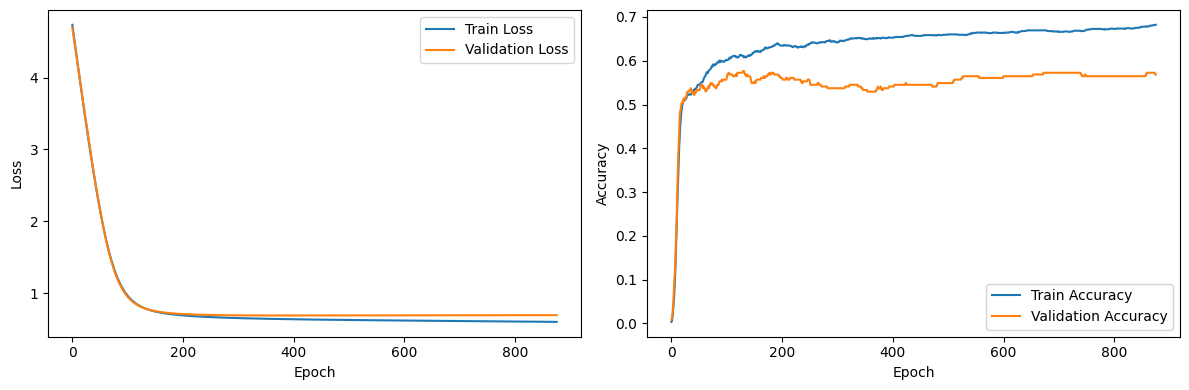


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1939, Val Loss: 4.1552, Train Acc: 0.2015, Val Acc: 0.2500
Epoch: 020, Train Loss: 3.6666, Val Loss: 3.6481, Train Acc: 0.4882, Val Acc: 0.4746
Epoch: 030, Train Loss: 3.1440, Val Loss: 3.1595, Train Acc: 0.5345, Val Acc: 0.4788
Epoch: 040, Train Loss: 2.6377, Val Loss: 2.6947, Train Acc: 0.5445, Val Acc: 0.4915
Epoch: 050, Train Loss: 2.1724, Val Loss: 2.2639, Train Acc: 0.5499, Val Acc: 0.4873
Epoch: 060, Train Loss: 1.7731, Val Loss: 1.8830, Train Acc: 0.5572, Val Acc: 0.4746
Epoch: 070, Train Loss: 1.4562, Val Loss: 1.5693, Train Acc: 0.5554, Val Acc: 0.4619
Epoch: 080, Train Loss: 1.2217, Val Loss: 1.3303, Train Acc: 0.5617, Val Acc: 0.4746
Epoch: 090, Train Loss: 1.0578, Val Loss: 1.1597, Train Acc: 0.5662, Val Acc: 0.4703
Epoch: 100, Train Loss: 0.9470, Val Loss: 1.0426, Train Acc: 0.5599, Val Acc: 0.4915
Epoch: 110, Train Loss: 0.8729, Val Loss: 0.9629, Tr

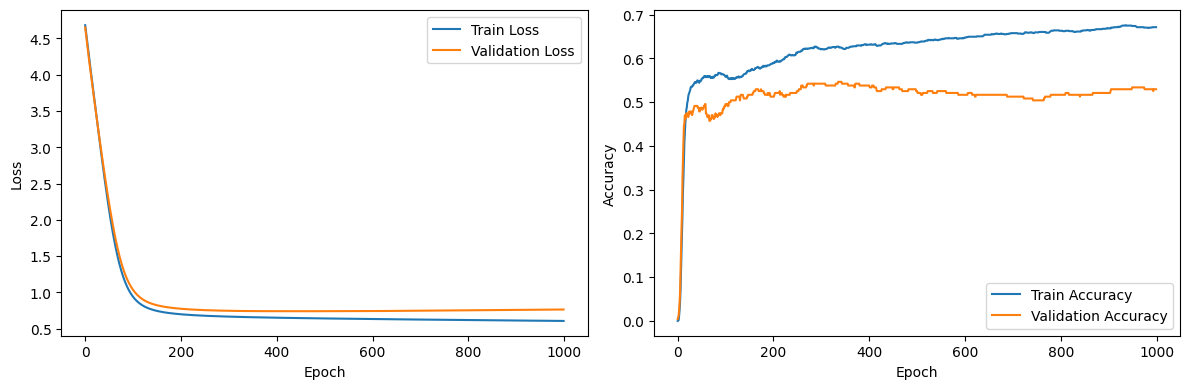


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2094, Val Loss: 4.1385, Train Acc: 0.1014, Val Acc: 0.1697
Epoch: 020, Train Loss: 3.6048, Val Loss: 3.5532, Train Acc: 0.4774, Val Acc: 0.5459
Epoch: 030, Train Loss: 3.0380, Val Loss: 3.0054, Train Acc: 0.5394, Val Acc: 0.5780
Epoch: 040, Train Loss: 2.5322, Val Loss: 2.5156, Train Acc: 0.5463, Val Acc: 0.5642
Epoch: 050, Train Loss: 2.0936, Val Loss: 2.0878, Train Acc: 0.5502, Val Acc: 0.5826
Epoch: 060, Train Loss: 1.7305, Val Loss: 1.7288, Train Acc: 0.5541, Val Acc: 0.5780
Epoch: 070, Train Loss: 1.4468, Val Loss: 1.4439, Train Acc: 0.5591, Val Acc: 0.5780
Epoch: 080, Train Loss: 1.2354, Val Loss: 1.2302, Train Acc: 0.5581, Val Acc: 0.5826
Epoch: 090, Train Loss: 1.0828, Val Loss: 1.0767, Train Acc: 0.5640, Val Acc: 0.5780
Epoch: 100, Train Loss: 0.9747, Val Loss: 0.9691, Train Acc: 0.5699, Val Acc: 0.5596
Epoch: 110, Train Loss: 0.8984, Val Loss: 0.8946, Tr

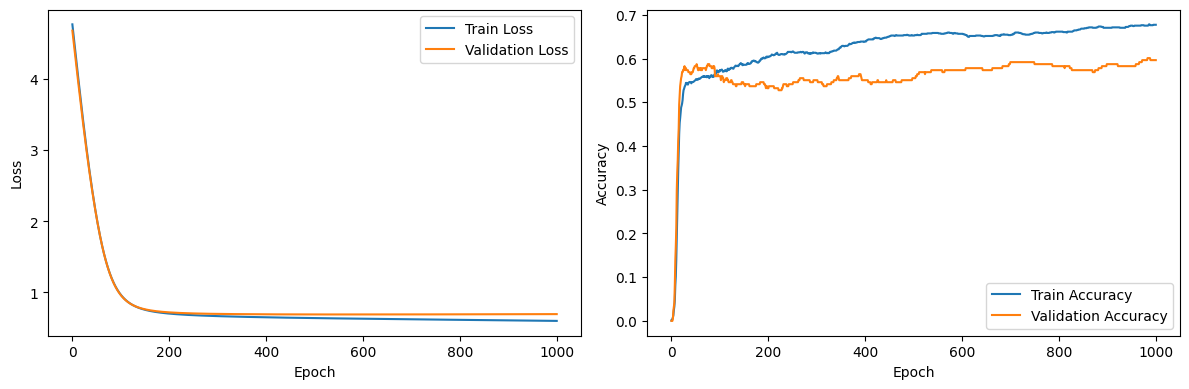


========== Run 25 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1671, Val Loss: 4.0902, Train Acc: 0.1563, Val Acc: 0.2068
Epoch: 020, Train Loss: 3.6104, Val Loss: 3.5004, Train Acc: 0.5020, Val Acc: 0.5000
Epoch: 030, Train Loss: 3.0733, Val Loss: 2.9574, Train Acc: 0.5326, Val Acc: 0.5451
Epoch: 040, Train Loss: 2.5721, Val Loss: 2.4710, Train Acc: 0.5415, Val Acc: 0.5489
Epoch: 050, Train Loss: 2.1235, Val Loss: 2.0467, Train Acc: 0.5471, Val Acc: 0.5602
Epoch: 060, Train Loss: 1.7441, Val Loss: 1.6940, Train Acc: 0.5753, Val Acc: 0.5564
Epoch: 070, Train Loss: 1.4428, Val Loss: 1.4181, Train Acc: 0.5753, Val Acc: 0.5639
Epoch: 080, Train Loss: 1.2178, Val Loss: 1.2145, Train Acc: 0.5826, Val Acc: 0.5902
Epoch: 090, Train Loss: 1.0578, Val Loss: 1.0703, Train Acc: 0.5842, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.9476, Val Loss: 0.9710, Train Acc: 0.5898, Val Acc: 0.5714
Epoch: 110, Train Los

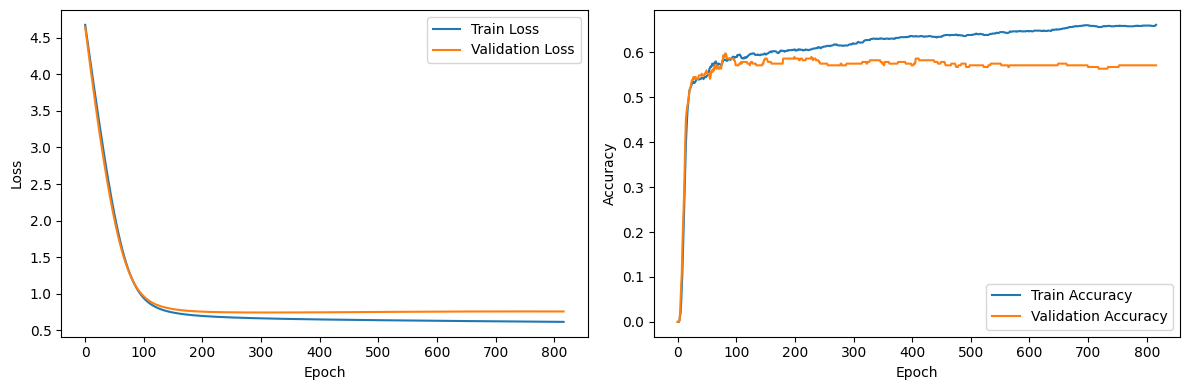


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.9101, Val Loss: 3.8720, Train Acc: 0.3104, Val Acc: 0.3412
Epoch: 020, Train Loss: 3.3552, Val Loss: 3.3293, Train Acc: 0.5386, Val Acc: 0.5373
Epoch: 030, Train Loss: 2.8300, Val Loss: 2.8055, Train Acc: 0.5680, Val Acc: 0.5451
Epoch: 040, Train Loss: 2.3542, Val Loss: 2.3264, Train Acc: 0.5763, Val Acc: 0.5569
Epoch: 050, Train Loss: 1.9444, Val Loss: 1.9128, Train Acc: 0.5973, Val Acc: 0.5451
Epoch: 060, Train Loss: 1.6091, Val Loss: 1.5761, Train Acc: 0.5990, Val Acc: 0.5569
Epoch: 070, Train Loss: 1.3476, Val Loss: 1.3166, Train Acc: 0.6057, Val Acc: 0.5608
Epoch: 080, Train Loss: 1.1521, Val Loss: 1.1263, Train Acc: 0.6124, Val Acc: 0.5647
Epoch: 090, Train Loss: 1.0114, Val Loss: 0.9925, Train Acc: 0.6216, Val Acc: 0.5647
Epoch: 100, Train Loss: 0.9129, Val Loss: 0.9012, Train Acc: 0.6216, Val Acc: 0.5647
Epoch: 110, Train Loss: 0.8451, Val Loss: 0.8402, Tr

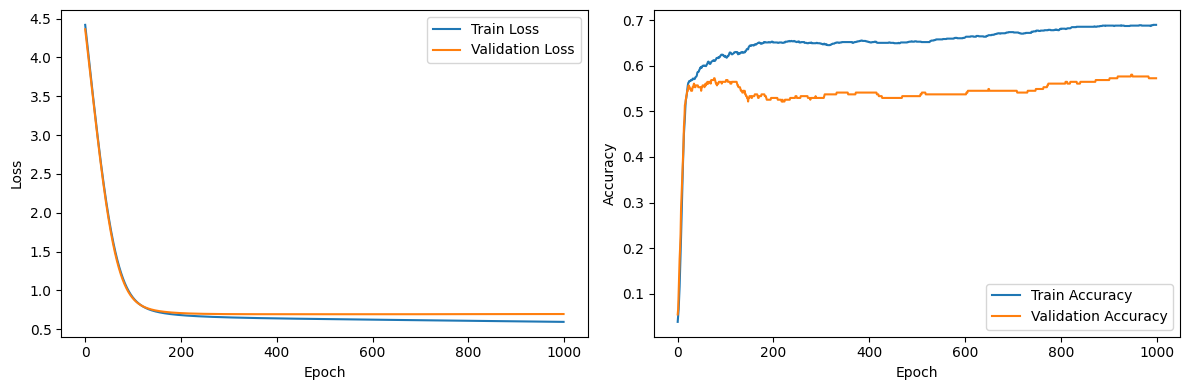


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0540, Val Loss: 3.9841, Train Acc: 0.3575, Val Acc: 0.3856
Epoch: 020, Train Loss: 3.5375, Val Loss: 3.4912, Train Acc: 0.5209, Val Acc: 0.5169
Epoch: 030, Train Loss: 3.0312, Val Loss: 3.0335, Train Acc: 0.5417, Val Acc: 0.4915
Epoch: 040, Train Loss: 2.5465, Val Loss: 2.6006, Train Acc: 0.5517, Val Acc: 0.4915
Epoch: 050, Train Loss: 2.1050, Val Loss: 2.1963, Train Acc: 0.5526, Val Acc: 0.4788
Epoch: 060, Train Loss: 1.7286, Val Loss: 1.8383, Train Acc: 0.5572, Val Acc: 0.4746
Epoch: 070, Train Loss: 1.4294, Val Loss: 1.5434, Train Acc: 0.5572, Val Acc: 0.4661
Epoch: 080, Train Loss: 1.2068, Val Loss: 1.3180, Train Acc: 0.5708, Val Acc: 0.4661
Epoch: 090, Train Loss: 1.0498, Val Loss: 1.1553, Train Acc: 0.5817, Val Acc: 0.4915
Epoch: 100, Train Loss: 0.9426, Val Loss: 1.0418, Train Acc: 0.5907, Val Acc: 0.4873
Epoch: 110, Train Loss: 0.8704, Val Loss: 0.9637, Tr

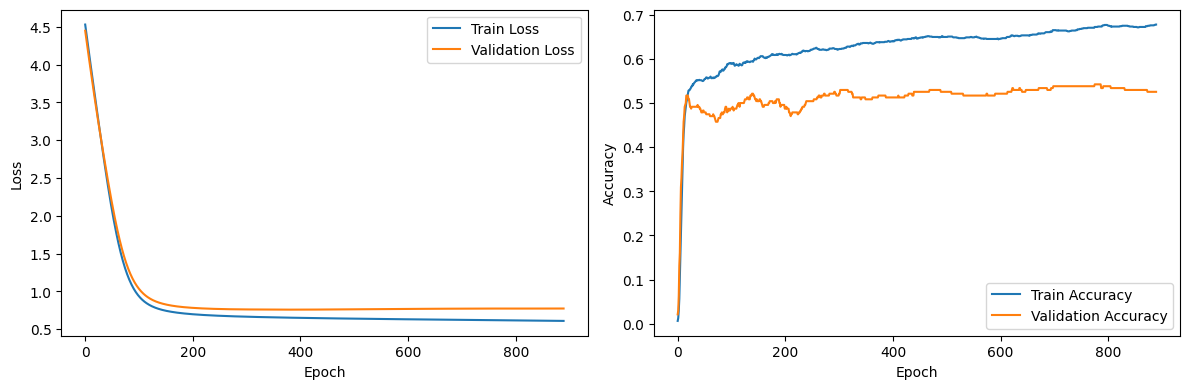


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6971, Val Loss: 3.6632, Train Acc: 0.4321, Val Acc: 0.4404
Epoch: 020, Train Loss: 3.1409, Val Loss: 3.1132, Train Acc: 0.5010, Val Acc: 0.5092
Epoch: 030, Train Loss: 2.6414, Val Loss: 2.6237, Train Acc: 0.5069, Val Acc: 0.5092
Epoch: 040, Train Loss: 2.1964, Val Loss: 2.1889, Train Acc: 0.5089, Val Acc: 0.5138
Epoch: 050, Train Loss: 1.8152, Val Loss: 1.8137, Train Acc: 0.5157, Val Acc: 0.5138
Epoch: 060, Train Loss: 1.5079, Val Loss: 1.5074, Train Acc: 0.5295, Val Acc: 0.5183
Epoch: 070, Train Loss: 1.2739, Val Loss: 1.2731, Train Acc: 0.5453, Val Acc: 0.5321
Epoch: 080, Train Loss: 1.1036, Val Loss: 1.1038, Train Acc: 0.5492, Val Acc: 0.5367
Epoch: 090, Train Loss: 0.9833, Val Loss: 0.9860, Train Acc: 0.5679, Val Acc: 0.5596
Epoch: 100, Train Loss: 0.8997, Val Loss: 0.9054, Train Acc: 0.5738, Val Acc: 0.5413
Epoch: 110, Train Loss: 0.8418, Val Loss: 0.8501, Tr

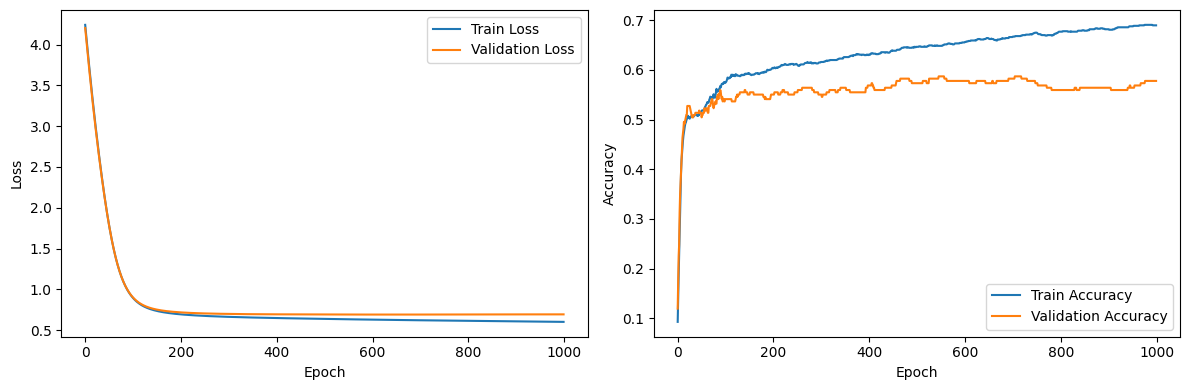


========== Run 26 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.3333, Val Loss: 4.2659, Train Acc: 0.0508, Val Acc: 0.0827
Epoch: 020, Train Loss: 3.7821, Val Loss: 3.6693, Train Acc: 0.4432, Val Acc: 0.4662
Epoch: 030, Train Loss: 3.2518, Val Loss: 3.1215, Train Acc: 0.5149, Val Acc: 0.5226
Epoch: 040, Train Loss: 2.7510, Val Loss: 2.6310, Train Acc: 0.5326, Val Acc: 0.5301
Epoch: 050, Train Loss: 2.2930, Val Loss: 2.1929, Train Acc: 0.5488, Val Acc: 0.5338
Epoch: 060, Train Loss: 1.8955, Val Loss: 1.8174, Train Acc: 0.5616, Val Acc: 0.5526
Epoch: 070, Train Loss: 1.5703, Val Loss: 1.5142, Train Acc: 0.5673, Val Acc: 0.5602
Epoch: 080, Train Loss: 1.3190, Val Loss: 1.2837, Train Acc: 0.5721, Val Acc: 0.5376
Epoch: 090, Train Loss: 1.1343, Val Loss: 1.1163, Train Acc: 0.5713, Val Acc: 0.5376
Epoch: 100, Train Loss: 1.0038, Val Loss: 0.9989, Train Acc: 0.5753, Val Acc: 0.5564
Epoch: 110, Train Los

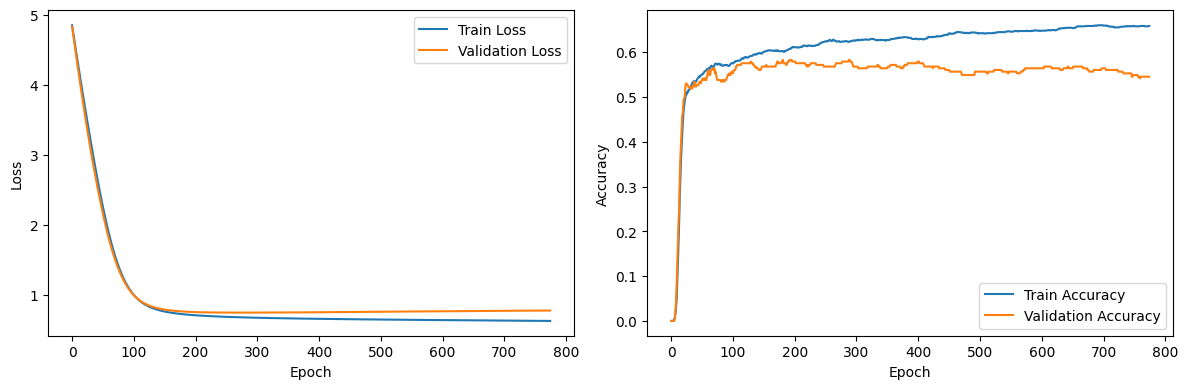


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0330, Val Loss: 3.9865, Train Acc: 0.3163, Val Acc: 0.3686
Epoch: 020, Train Loss: 3.4836, Val Loss: 3.4518, Train Acc: 0.5327, Val Acc: 0.5529
Epoch: 030, Train Loss: 2.9663, Val Loss: 2.9357, Train Acc: 0.5587, Val Acc: 0.5686
Epoch: 040, Train Loss: 2.4920, Val Loss: 2.4554, Train Acc: 0.5671, Val Acc: 0.5725
Epoch: 050, Train Loss: 2.0721, Val Loss: 2.0289, Train Acc: 0.5780, Val Acc: 0.5804
Epoch: 060, Train Loss: 1.7192, Val Loss: 1.6709, Train Acc: 0.5831, Val Acc: 0.5922
Epoch: 070, Train Loss: 1.4387, Val Loss: 1.3887, Train Acc: 0.5956, Val Acc: 0.5922
Epoch: 080, Train Loss: 1.2264, Val Loss: 1.1788, Train Acc: 0.6023, Val Acc: 0.6078
Epoch: 090, Train Loss: 1.0717, Val Loss: 1.0297, Train Acc: 0.5998, Val Acc: 0.6157
Epoch: 100, Train Loss: 0.9619, Val Loss: 0.9274, Train Acc: 0.6082, Val Acc: 0.6196
Epoch: 110, Train Loss: 0.8853, Val Loss: 0.8582, Tr

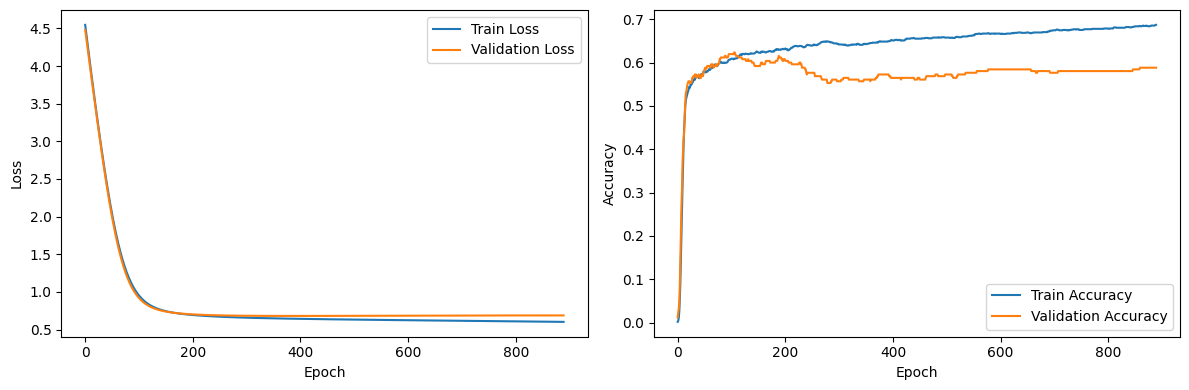


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1586, Val Loss: 4.2210, Train Acc: 0.3258, Val Acc: 0.3729
Epoch: 020, Train Loss: 3.6405, Val Loss: 3.7165, Train Acc: 0.4982, Val Acc: 0.5127
Epoch: 030, Train Loss: 3.1338, Val Loss: 3.2377, Train Acc: 0.5036, Val Acc: 0.5127
Epoch: 040, Train Loss: 2.6461, Val Loss: 2.7812, Train Acc: 0.5082, Val Acc: 0.5127
Epoch: 050, Train Loss: 2.1947, Val Loss: 2.3499, Train Acc: 0.5172, Val Acc: 0.4958
Epoch: 060, Train Loss: 1.8013, Val Loss: 1.9580, Train Acc: 0.5299, Val Acc: 0.5042
Epoch: 070, Train Loss: 1.4819, Val Loss: 1.6255, Train Acc: 0.5554, Val Acc: 0.5127
Epoch: 080, Train Loss: 1.2406, Val Loss: 1.3654, Train Acc: 0.5626, Val Acc: 0.5212
Epoch: 090, Train Loss: 1.0694, Val Loss: 1.1780, Train Acc: 0.5744, Val Acc: 0.5254
Epoch: 100, Train Loss: 0.9530, Val Loss: 1.0505, Train Acc: 0.5789, Val Acc: 0.5085
Epoch: 110, Train Loss: 0.8751, Val Loss: 0.9659, Tr

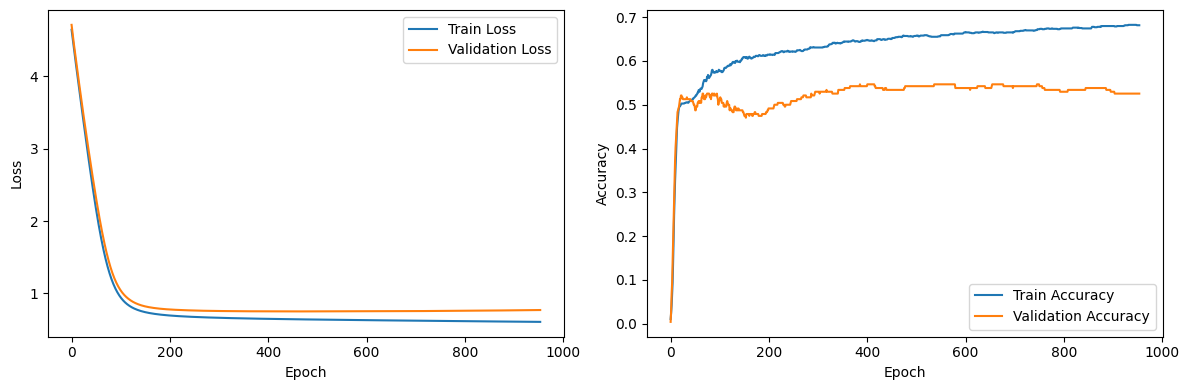


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2990, Val Loss: 4.2061, Train Acc: 0.1024, Val Acc: 0.1835
Epoch: 020, Train Loss: 3.6879, Val Loss: 3.6125, Train Acc: 0.4823, Val Acc: 0.4633
Epoch: 030, Train Loss: 3.1013, Val Loss: 3.0478, Train Acc: 0.5157, Val Acc: 0.4679
Epoch: 040, Train Loss: 2.5701, Val Loss: 2.5385, Train Acc: 0.5285, Val Acc: 0.4679
Epoch: 050, Train Loss: 2.1107, Val Loss: 2.0957, Train Acc: 0.5404, Val Acc: 0.5183
Epoch: 060, Train Loss: 1.7331, Val Loss: 1.7274, Train Acc: 0.5531, Val Acc: 0.5000
Epoch: 070, Train Loss: 1.4410, Val Loss: 1.4392, Train Acc: 0.5561, Val Acc: 0.5275
Epoch: 080, Train Loss: 1.2265, Val Loss: 1.2268, Train Acc: 0.5581, Val Acc: 0.5459
Epoch: 090, Train Loss: 1.0741, Val Loss: 1.0769, Train Acc: 0.5581, Val Acc: 0.5505
Epoch: 100, Train Loss: 0.9674, Val Loss: 0.9732, Train Acc: 0.5551, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.8930, Val Loss: 0.9019, Tr

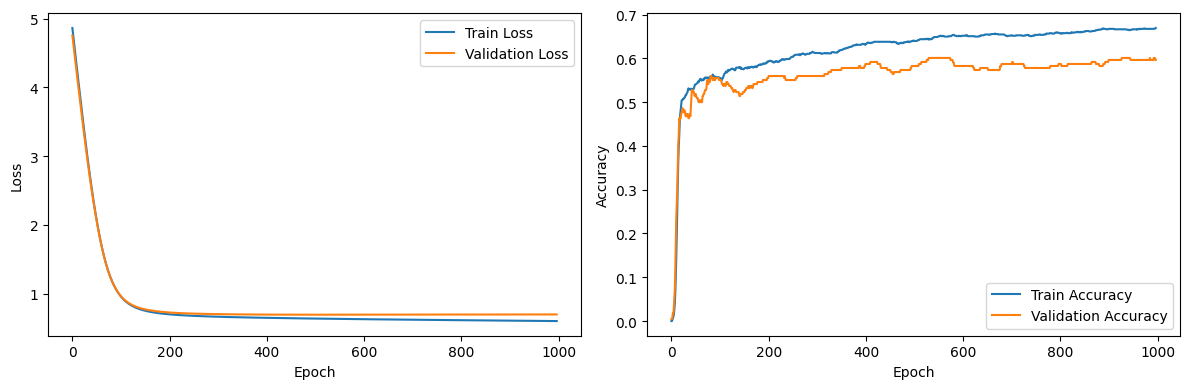


========== Run 27 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0544, Val Loss: 3.9408, Train Acc: 0.3231, Val Acc: 0.3571
Epoch: 020, Train Loss: 3.4863, Val Loss: 3.3564, Train Acc: 0.4915, Val Acc: 0.4699
Epoch: 030, Train Loss: 2.9496, Val Loss: 2.8328, Train Acc: 0.5230, Val Acc: 0.5075
Epoch: 040, Train Loss: 2.4549, Val Loss: 2.3643, Train Acc: 0.5423, Val Acc: 0.4887
Epoch: 050, Train Loss: 2.0171, Val Loss: 1.9560, Train Acc: 0.5512, Val Acc: 0.4925
Epoch: 060, Train Loss: 1.6516, Val Loss: 1.6179, Train Acc: 0.5536, Val Acc: 0.5075
Epoch: 070, Train Loss: 1.3659, Val Loss: 1.3552, Train Acc: 0.5681, Val Acc: 0.5526
Epoch: 080, Train Loss: 1.1567, Val Loss: 1.1635, Train Acc: 0.5802, Val Acc: 0.5489
Epoch: 090, Train Loss: 1.0113, Val Loss: 1.0298, Train Acc: 0.5842, Val Acc: 0.5414
Epoch: 100, Train Loss: 0.9133, Val Loss: 0.9396, Train Acc: 0.5963, Val Acc: 0.5526
Epoch: 110, Train Los

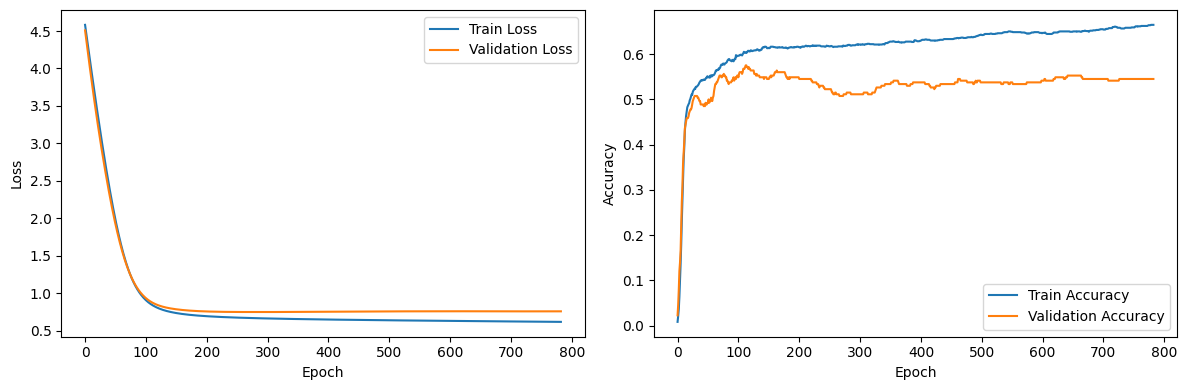


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1720, Val Loss: 4.1299, Train Acc: 0.2408, Val Acc: 0.2510
Epoch: 020, Train Loss: 3.6217, Val Loss: 3.5973, Train Acc: 0.4799, Val Acc: 0.4980
Epoch: 030, Train Loss: 3.1085, Val Loss: 3.0901, Train Acc: 0.5034, Val Acc: 0.5255
Epoch: 040, Train Loss: 2.6405, Val Loss: 2.6196, Train Acc: 0.4992, Val Acc: 0.5373
Epoch: 050, Train Loss: 2.2215, Val Loss: 2.1948, Train Acc: 0.5109, Val Acc: 0.5333
Epoch: 060, Train Loss: 1.8558, Val Loss: 1.8221, Train Acc: 0.5327, Val Acc: 0.5451
Epoch: 070, Train Loss: 1.5493, Val Loss: 1.5103, Train Acc: 0.5428, Val Acc: 0.5569
Epoch: 080, Train Loss: 1.3079, Val Loss: 1.2671, Train Acc: 0.5772, Val Acc: 0.5412
Epoch: 090, Train Loss: 1.1294, Val Loss: 1.0905, Train Acc: 0.5864, Val Acc: 0.5647
Epoch: 100, Train Loss: 1.0019, Val Loss: 0.9679, Train Acc: 0.5864, Val Acc: 0.5725
Epoch: 110, Train Loss: 0.9125, Val Loss: 0.8850, Tr

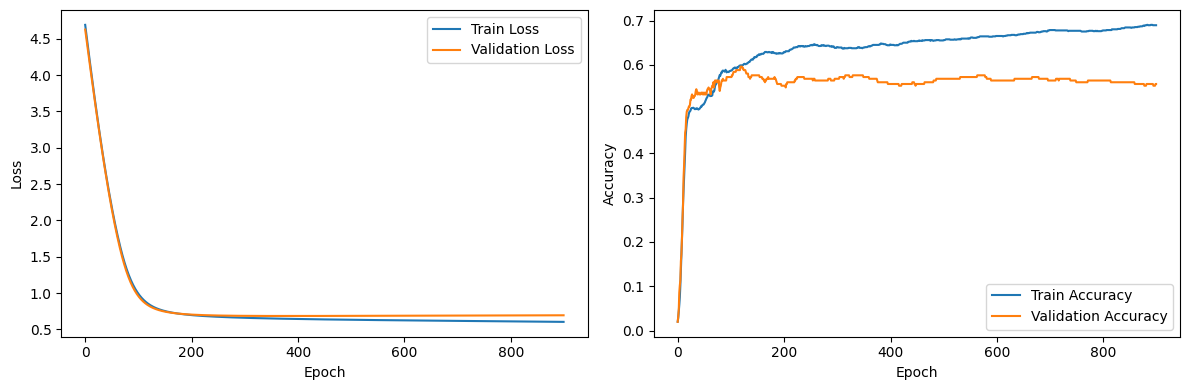


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2985, Val Loss: 4.2498, Train Acc: 0.1289, Val Acc: 0.2373
Epoch: 020, Train Loss: 3.7755, Val Loss: 3.7121, Train Acc: 0.5045, Val Acc: 0.5169
Epoch: 030, Train Loss: 3.2597, Val Loss: 3.2116, Train Acc: 0.5309, Val Acc: 0.5127
Epoch: 040, Train Loss: 2.7575, Val Loss: 2.7524, Train Acc: 0.5372, Val Acc: 0.5127
Epoch: 050, Train Loss: 2.2860, Val Loss: 2.3232, Train Acc: 0.5526, Val Acc: 0.5212
Epoch: 060, Train Loss: 1.8706, Val Loss: 1.9387, Train Acc: 0.5644, Val Acc: 0.4915
Epoch: 070, Train Loss: 1.5315, Val Loss: 1.6166, Train Acc: 0.5608, Val Acc: 0.4746
Epoch: 080, Train Loss: 1.2748, Val Loss: 1.3672, Train Acc: 0.5662, Val Acc: 0.4703
Epoch: 090, Train Loss: 1.0930, Val Loss: 1.1868, Train Acc: 0.5744, Val Acc: 0.4788
Epoch: 100, Train Loss: 0.9700, Val Loss: 1.0610, Train Acc: 0.5907, Val Acc: 0.4831
Epoch: 110, Train Loss: 0.8883, Val Loss: 0.9739, Tr

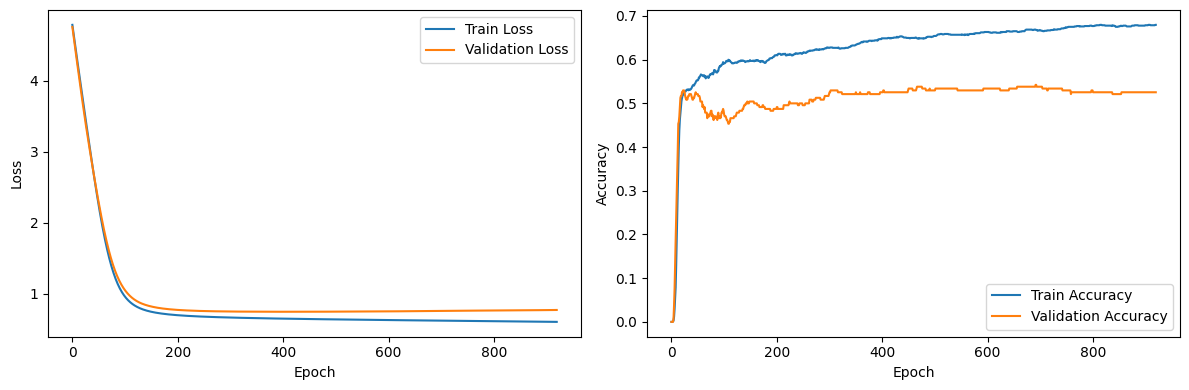


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0339, Val Loss: 3.9872, Train Acc: 0.2904, Val Acc: 0.3624
Epoch: 020, Train Loss: 3.4519, Val Loss: 3.4119, Train Acc: 0.5177, Val Acc: 0.5872
Epoch: 030, Train Loss: 2.9193, Val Loss: 2.8855, Train Acc: 0.5285, Val Acc: 0.5917
Epoch: 040, Train Loss: 2.4380, Val Loss: 2.4151, Train Acc: 0.5335, Val Acc: 0.5780
Epoch: 050, Train Loss: 2.0169, Val Loss: 2.0039, Train Acc: 0.5404, Val Acc: 0.5550
Epoch: 060, Train Loss: 1.6689, Val Loss: 1.6608, Train Acc: 0.5453, Val Acc: 0.5505
Epoch: 070, Train Loss: 1.3977, Val Loss: 1.3911, Train Acc: 0.5581, Val Acc: 0.5688
Epoch: 080, Train Loss: 1.1964, Val Loss: 1.1906, Train Acc: 0.5620, Val Acc: 0.5642
Epoch: 090, Train Loss: 1.0518, Val Loss: 1.0475, Train Acc: 0.5620, Val Acc: 0.5734
Epoch: 100, Train Loss: 0.9501, Val Loss: 0.9475, Train Acc: 0.5797, Val Acc: 0.5826
Epoch: 110, Train Loss: 0.8791, Val Loss: 0.8782, Tr

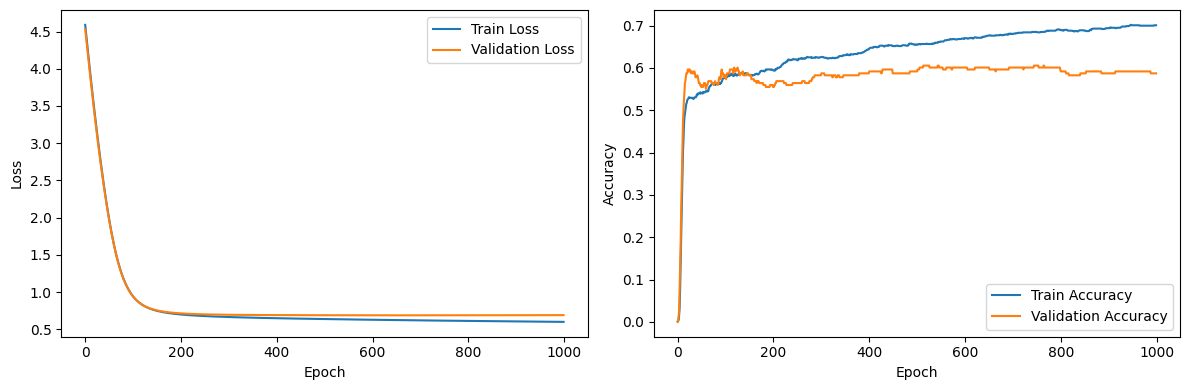


========== Run 28 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0061, Val Loss: 3.9404, Train Acc: 0.2748, Val Acc: 0.3271
Epoch: 020, Train Loss: 3.4600, Val Loss: 3.3655, Train Acc: 0.4448, Val Acc: 0.4361
Epoch: 030, Train Loss: 2.9334, Val Loss: 2.8418, Train Acc: 0.4698, Val Acc: 0.4662
Epoch: 040, Train Loss: 2.4387, Val Loss: 2.3623, Train Acc: 0.4875, Val Acc: 0.4586
Epoch: 050, Train Loss: 1.9949, Val Loss: 1.9355, Train Acc: 0.5012, Val Acc: 0.4887
Epoch: 060, Train Loss: 1.6245, Val Loss: 1.5823, Train Acc: 0.5254, Val Acc: 0.5150
Epoch: 070, Train Loss: 1.3388, Val Loss: 1.3126, Train Acc: 0.5383, Val Acc: 0.5226
Epoch: 080, Train Loss: 1.1333, Val Loss: 1.1207, Train Acc: 0.5592, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.9934, Val Loss: 0.9910, Train Acc: 0.5705, Val Acc: 0.5526
Epoch: 100, Train Loss: 0.9010, Val Loss: 0.9058, Train Acc: 0.5810, Val Acc: 0.5714
Epoch: 110, Train Los

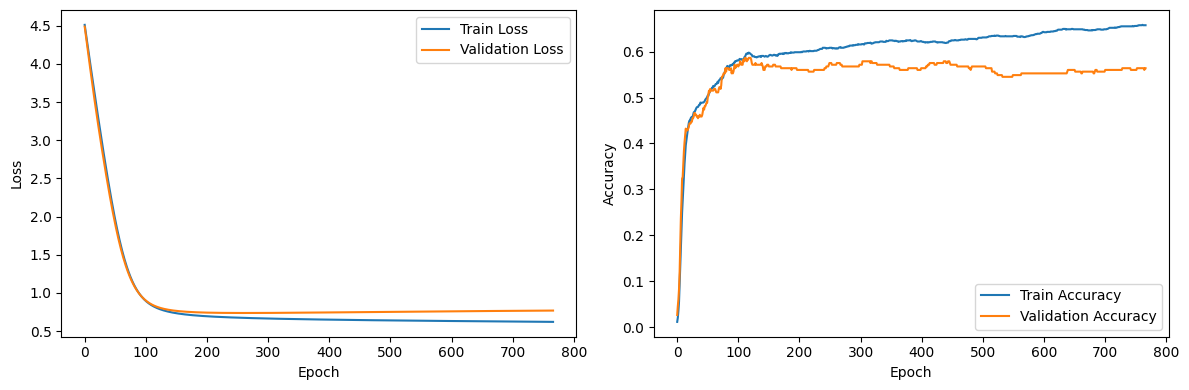


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0936, Val Loss: 4.0542, Train Acc: 0.2617, Val Acc: 0.2745
Epoch: 020, Train Loss: 3.5360, Val Loss: 3.5126, Train Acc: 0.5000, Val Acc: 0.5216
Epoch: 030, Train Loss: 3.0086, Val Loss: 2.9888, Train Acc: 0.5151, Val Acc: 0.5216
Epoch: 040, Train Loss: 2.5225, Val Loss: 2.4981, Train Acc: 0.5260, Val Acc: 0.5451
Epoch: 050, Train Loss: 2.0891, Val Loss: 2.0586, Train Acc: 0.5478, Val Acc: 0.5922
Epoch: 060, Train Loss: 1.7231, Val Loss: 1.6884, Train Acc: 0.5596, Val Acc: 0.5804
Epoch: 070, Train Loss: 1.4324, Val Loss: 1.3973, Train Acc: 0.5839, Val Acc: 0.5725
Epoch: 080, Train Loss: 1.2143, Val Loss: 1.1824, Train Acc: 0.5940, Val Acc: 0.5843
Epoch: 090, Train Loss: 1.0578, Val Loss: 1.0316, Train Acc: 0.6040, Val Acc: 0.5882
Epoch: 100, Train Loss: 0.9486, Val Loss: 0.9289, Train Acc: 0.6082, Val Acc: 0.5882
Epoch: 110, Train Loss: 0.8736, Val Loss: 0.8601, Tr

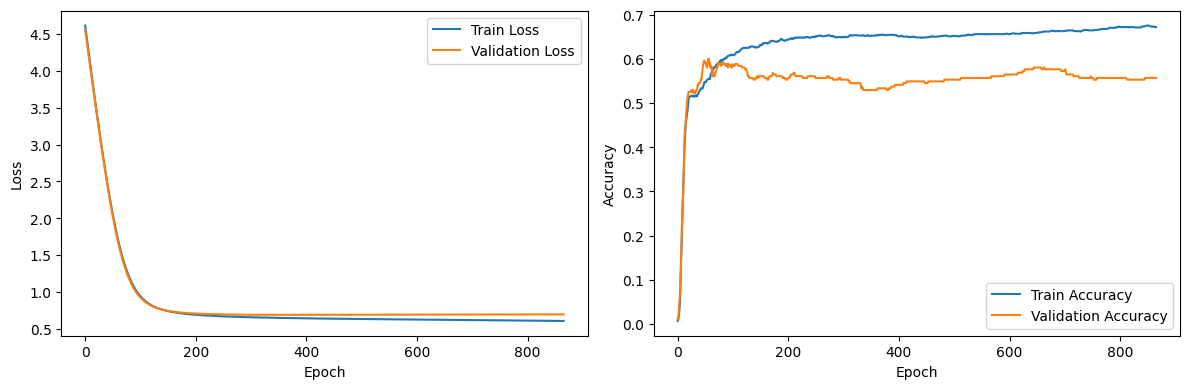


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0132, Val Loss: 3.9337, Train Acc: 0.2623, Val Acc: 0.3771
Epoch: 020, Train Loss: 3.5082, Val Loss: 3.4461, Train Acc: 0.4991, Val Acc: 0.5042
Epoch: 030, Train Loss: 3.0118, Val Loss: 2.9814, Train Acc: 0.5318, Val Acc: 0.5169
Epoch: 040, Train Loss: 2.5350, Val Loss: 2.5423, Train Acc: 0.5426, Val Acc: 0.5212
Epoch: 050, Train Loss: 2.0983, Val Loss: 2.1364, Train Acc: 0.5508, Val Acc: 0.5297
Epoch: 060, Train Loss: 1.7233, Val Loss: 1.7771, Train Acc: 0.5590, Val Acc: 0.5381
Epoch: 070, Train Loss: 1.4233, Val Loss: 1.4806, Train Acc: 0.5662, Val Acc: 0.5297
Epoch: 080, Train Loss: 1.1995, Val Loss: 1.2549, Train Acc: 0.5690, Val Acc: 0.5297
Epoch: 090, Train Loss: 1.0418, Val Loss: 1.0942, Train Acc: 0.5699, Val Acc: 0.5127
Epoch: 100, Train Loss: 0.9350, Val Loss: 0.9853, Train Acc: 0.5726, Val Acc: 0.5169
Epoch: 110, Train Loss: 0.8637, Val Loss: 0.9133, Tr

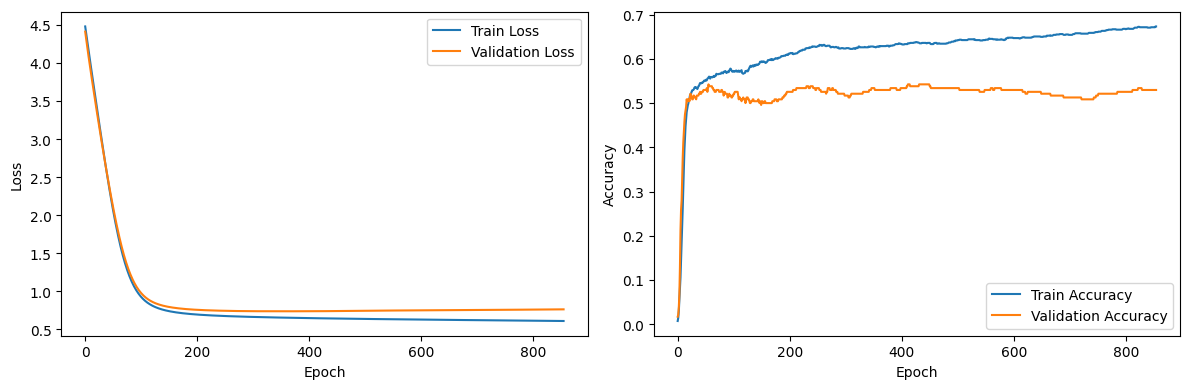


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1298, Val Loss: 4.0765, Train Acc: 0.1791, Val Acc: 0.2339
Epoch: 020, Train Loss: 3.5476, Val Loss: 3.5066, Train Acc: 0.4892, Val Acc: 0.5183
Epoch: 030, Train Loss: 3.0052, Val Loss: 2.9813, Train Acc: 0.5236, Val Acc: 0.5321
Epoch: 040, Train Loss: 2.5174, Val Loss: 2.5099, Train Acc: 0.5276, Val Acc: 0.5321
Epoch: 050, Train Loss: 2.0883, Val Loss: 2.0925, Train Acc: 0.5335, Val Acc: 0.5367
Epoch: 060, Train Loss: 1.7259, Val Loss: 1.7352, Train Acc: 0.5541, Val Acc: 0.5413
Epoch: 070, Train Loss: 1.4371, Val Loss: 1.4462, Train Acc: 0.5807, Val Acc: 0.5413
Epoch: 080, Train Loss: 1.2195, Val Loss: 1.2272, Train Acc: 0.5797, Val Acc: 0.5596
Epoch: 090, Train Loss: 1.0630, Val Loss: 1.0704, Train Acc: 0.5699, Val Acc: 0.5688
Epoch: 100, Train Loss: 0.9537, Val Loss: 0.9618, Train Acc: 0.5787, Val Acc: 0.5826
Epoch: 110, Train Loss: 0.8783, Val Loss: 0.8875, Tr

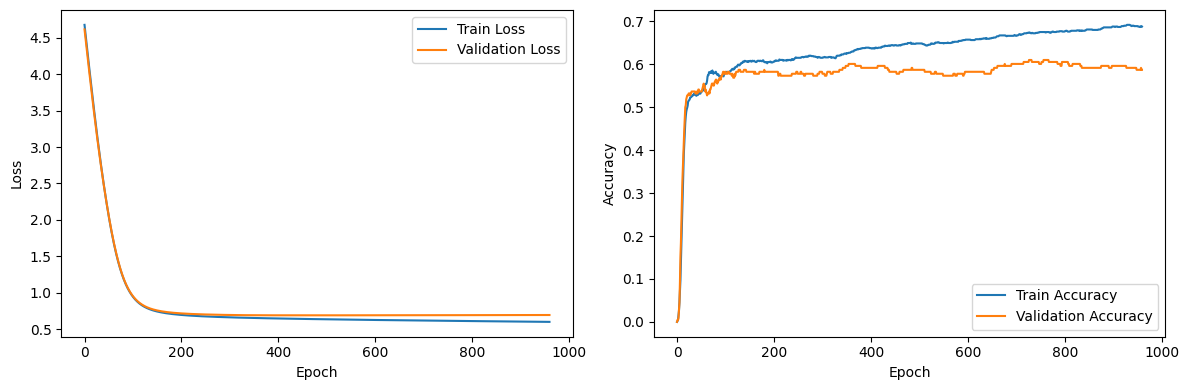


========== Run 29 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.2048, Val Loss: 4.1528, Train Acc: 0.1789, Val Acc: 0.2218
Epoch: 020, Train Loss: 3.6593, Val Loss: 3.5733, Train Acc: 0.5052, Val Acc: 0.5038
Epoch: 030, Train Loss: 3.1327, Val Loss: 3.0463, Train Acc: 0.5391, Val Acc: 0.5376
Epoch: 040, Train Loss: 2.6354, Val Loss: 2.5664, Train Acc: 0.5471, Val Acc: 0.5451
Epoch: 050, Train Loss: 2.1825, Val Loss: 2.1313, Train Acc: 0.5689, Val Acc: 0.5827
Epoch: 060, Train Loss: 1.7939, Val Loss: 1.7577, Train Acc: 0.5786, Val Acc: 0.5677
Epoch: 070, Train Loss: 1.4820, Val Loss: 1.4588, Train Acc: 0.5794, Val Acc: 0.5489
Epoch: 080, Train Loss: 1.2464, Val Loss: 1.2346, Train Acc: 0.5858, Val Acc: 0.5263
Epoch: 090, Train Loss: 1.0777, Val Loss: 1.0757, Train Acc: 0.5890, Val Acc: 0.5414
Epoch: 100, Train Loss: 0.9613, Val Loss: 0.9683, Train Acc: 0.5834, Val Acc: 0.5414
Epoch: 110, Train Los

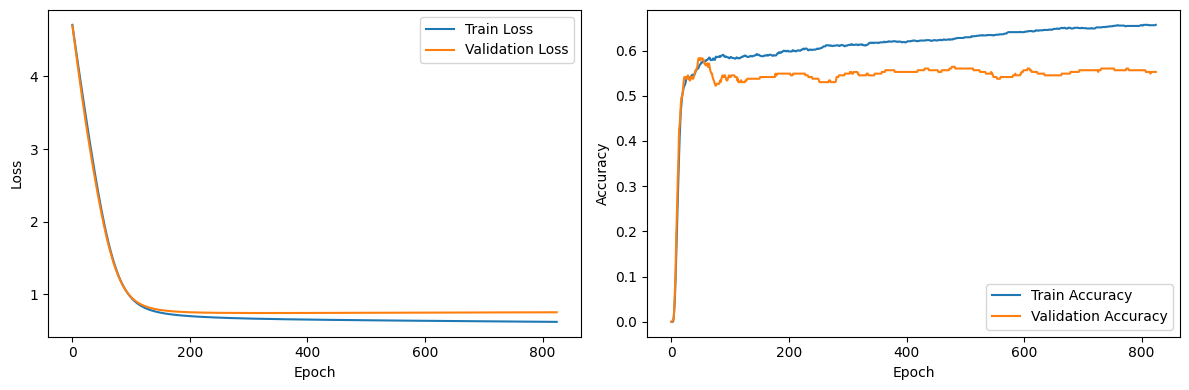


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.1657, Val Loss: 4.1266, Train Acc: 0.1955, Val Acc: 0.2392
Epoch: 020, Train Loss: 3.5982, Val Loss: 3.5793, Train Acc: 0.5394, Val Acc: 0.5333
Epoch: 030, Train Loss: 3.0544, Val Loss: 3.0425, Train Acc: 0.5604, Val Acc: 0.5490
Epoch: 040, Train Loss: 2.5541, Val Loss: 2.5388, Train Acc: 0.5621, Val Acc: 0.5529
Epoch: 050, Train Loss: 2.1137, Val Loss: 2.0915, Train Acc: 0.5747, Val Acc: 0.5490
Epoch: 060, Train Loss: 1.7460, Val Loss: 1.7171, Train Acc: 0.5856, Val Acc: 0.5451
Epoch: 070, Train Loss: 1.4558, Val Loss: 1.4230, Train Acc: 0.5889, Val Acc: 0.5451
Epoch: 080, Train Loss: 1.2376, Val Loss: 1.2053, Train Acc: 0.5889, Val Acc: 0.5333
Epoch: 090, Train Loss: 1.0795, Val Loss: 1.0518, Train Acc: 0.5956, Val Acc: 0.5333
Epoch: 100, Train Loss: 0.9677, Val Loss: 0.9464, Train Acc: 0.6007, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.8894, Val Loss: 0.8749, Tr

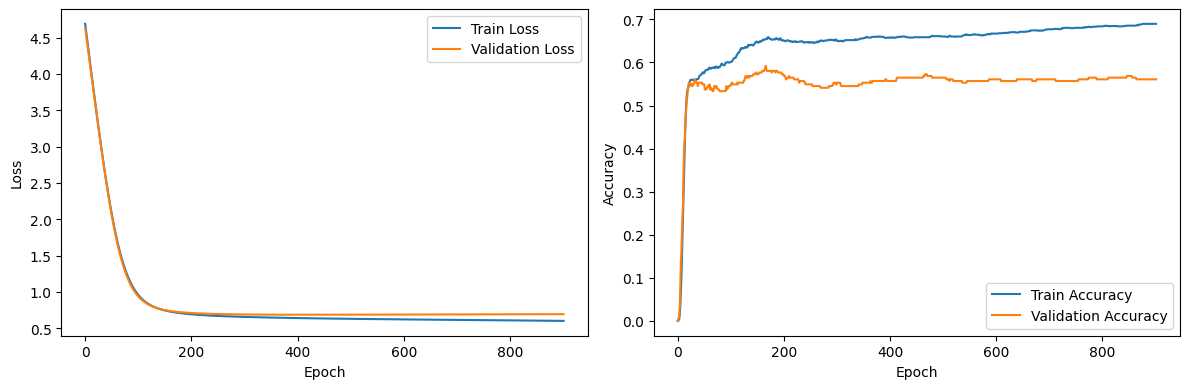


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0305, Val Loss: 3.9460, Train Acc: 0.2940, Val Acc: 0.3729
Epoch: 020, Train Loss: 3.4986, Val Loss: 3.4477, Train Acc: 0.5109, Val Acc: 0.5381
Epoch: 030, Train Loss: 2.9864, Val Loss: 2.9829, Train Acc: 0.5227, Val Acc: 0.5254
Epoch: 040, Train Loss: 2.5058, Val Loss: 2.5491, Train Acc: 0.5236, Val Acc: 0.5085
Epoch: 050, Train Loss: 2.0742, Val Loss: 2.1518, Train Acc: 0.5299, Val Acc: 0.5085
Epoch: 060, Train Loss: 1.7092, Val Loss: 1.8042, Train Acc: 0.5517, Val Acc: 0.5042
Epoch: 070, Train Loss: 1.4197, Val Loss: 1.5194, Train Acc: 0.5735, Val Acc: 0.5339
Epoch: 080, Train Loss: 1.2034, Val Loss: 1.3020, Train Acc: 0.5672, Val Acc: 0.5127
Epoch: 090, Train Loss: 1.0493, Val Loss: 1.1445, Train Acc: 0.5735, Val Acc: 0.5042
Epoch: 100, Train Loss: 0.9427, Val Loss: 1.0341, Train Acc: 0.5808, Val Acc: 0.4873
Epoch: 110, Train Loss: 0.8700, Val Loss: 0.9585, Tr

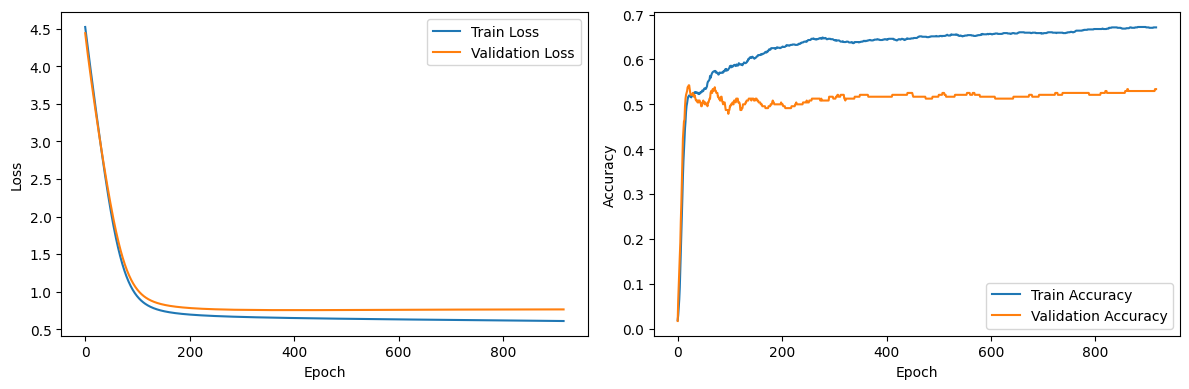


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 4.0322, Val Loss: 3.9925, Train Acc: 0.2520, Val Acc: 0.2752
Epoch: 020, Train Loss: 3.4388, Val Loss: 3.4083, Train Acc: 0.5069, Val Acc: 0.4954
Epoch: 030, Train Loss: 2.8952, Val Loss: 2.8737, Train Acc: 0.5226, Val Acc: 0.5046
Epoch: 040, Train Loss: 2.4101, Val Loss: 2.3989, Train Acc: 0.5335, Val Acc: 0.5275
Epoch: 050, Train Loss: 1.9913, Val Loss: 1.9872, Train Acc: 0.5335, Val Acc: 0.5229
Epoch: 060, Train Loss: 1.6488, Val Loss: 1.6481, Train Acc: 0.5512, Val Acc: 0.5321
Epoch: 070, Train Loss: 1.3841, Val Loss: 1.3859, Train Acc: 0.5581, Val Acc: 0.5367
Epoch: 080, Train Loss: 1.1882, Val Loss: 1.1934, Train Acc: 0.5630, Val Acc: 0.5413
Epoch: 090, Train Loss: 1.0475, Val Loss: 1.0567, Train Acc: 0.5768, Val Acc: 0.5413
Epoch: 100, Train Loss: 0.9481, Val Loss: 0.9611, Train Acc: 0.5866, Val Acc: 0.5780
Epoch: 110, Train Loss: 0.8782, Val Loss: 0.8943, Tr

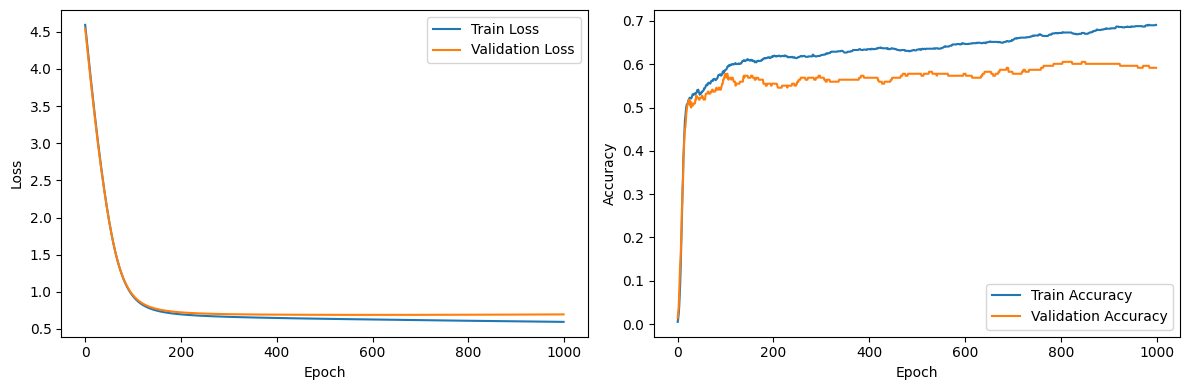


========== Final Summary ==========

Year: 2019
  Avg Test Accuracy: 0.6093 ± 0.0133
  Avg Test F1 Score: 0.6091 ± 0.0133
 Train Accuracy: 0.6153 ± 0.0065
Year: 2020
  Avg Test Accuracy: 0.6102 ± 0.0106
  Avg Test F1 Score: 0.6093 ± 0.0106
 Train Accuracy: 0.6559 ± 0.0078
Year: 2021
  Avg Test Accuracy: 0.6348 ± 0.0115
  Avg Test F1 Score: 0.6346 ± 0.0116
 Train Accuracy: 0.6388 ± 0.0079
Year: 2022
  Avg Test Accuracy: 0.6234 ± 0.0163
  Avg Test F1 Score: 0.6228 ± 0.0162
 Train Accuracy: 0.6559 ± 0.0117


In [11]:
if __name__ == "__main__":

    years = [2019, 2020, 2021, 2022]
    metric = 'revenue'

    # To store results for each year across 10 runs
    aggregate_results = {year: {'acc': [], 'f1': [], 'time': [], 'epochs': [], 'best_train_acc': []} for year in years}
    param = {
            "hidden_channels": 64,
            "out_channels": 32,
            "num_heads": 4,
            "lr": 0.0009,
            "weight_decay": 5e-4,
            "epochs": 1000,
            "patience": 500
        }

    #Add optuna code section here
    best_params_per_year = {}
    # for year in years:
    #     print(f"\nRunning Optuna optimization for year {year}...\n")
    
    #     study = optuna.create_study(direction="maximize")
    #     study.optimize(lambda trial: objective(trial, year, metric), n_trials=15)
    
    #     print(f"Best trial for year {year}: {study.best_trial.value}")
    #     print("Best hyperparameters:", study.best_params)

    #     best_params_per_year[year] = study.best_params
    
    for i in range(1, 30):
        print(f"\n========== Run {i} ==========\n")
        for year in years:
            # param = best_params_per_year[year]
            print(f"\nRunning experiment for year {year}...\n")
            results = run_experiment(year, metric, **param)
            # Store individual run metrics
            aggregate_results[year]['acc'].append(results['test_acc'])
            aggregate_results[year]['f1'].append(results['test_f1'])
            aggregate_results[year]['time'].append(results['training_time'])
            aggregate_results[year]['epochs'].append(results['epochs_run'])
            aggregate_results[year]['best_train_acc'].append(results['best_train_acc'])

    print("\n========== Final Summary ==========\n")
    for year in years:
        acc_mean = np.mean(aggregate_results[year]['acc'])
        acc_std = np.std(aggregate_results[year]['acc'])
        f1_mean = np.mean(aggregate_results[year]['f1'])
        f1_std = np.std(aggregate_results[year]['f1'])
        train_acc_mean = np.mean(aggregate_results[year]['best_train_acc'])
        train_acc_std = np.std(aggregate_results[year]['best_train_acc'])

        print(f"Year: {year}")
        print(f"  Avg Test Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
        print(f"  Avg Test F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        print(f" Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")